# Resume Analyzer Final v3
Clean final notebook for extraction, parsing, scoring, reranking, and evaluation.

# Resume Analyzer — V3 Research Notebook

This notebook documents the research and experimental development of
the Resume–Job Description Matching System.

The notebook includes earlier scoring experiments and the final V3
hybrid semantic + rule-based engine.

## Final production methodology

The final production engine is:

**V3 Hybrid Semantic + Rule-Based Ranking Engine**

The final V3 implementation uses:

- pretrained `all-MiniLM-L6-v2` SBERT
- skill coverage
- fuzzy title similarity
- experience matching
- fixed-weight V2 base score
- capped skill-match bonus
- role-domain bonus

The final production formula is:

final_score_v2 =
    0.40 × semantic_score +
    0.30 × skill_score +
    0.20 × title_score +
    0.10 × experience_score

final_score_v3 =
    final_score_v2 +
    skill_boost +
    domain_bonus

where:

skill_boost = min(matched_skill_count × 0.01, 0.08)

The final application implementation is maintained in the
`src/` and `app/` directories of this repository.

Cell 1 — Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


cell 2

In [ ]:
import os

print("Drive mounted:", os.path.exists("/content/drive/MyDrive"))
print("Path:", "/content/drive/MyDrive")



Drive mounted: True
Path: /content/drive/MyDrive


Cell 3 — Install Packages

In [ ]:
%pip install -q \
  pymupdf==1.24.9 \
  pdfplumber==0.11.4 \
  sentence-transformers==3.0.1 \
  rapidfuzz==3.9.6 \
  nltk==3.9.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 2.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.2/59.2 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.1/227.1 kB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 34.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 64.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 23.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently ta

Cell 4 — Imports, Seed, Device

In [ ]:
import os
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import fitz
import pdfplumber
from sentence_transformers import SentenceTransformer
from rapidfuzz import fuzz
import nltk

print("All imports successful")
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("NLTK:", nltk.__version__)

/usr/local/lib/python3.12/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


All imports successful
NumPy: 2.0.2
Pandas: 2.2.2
Torch: 2.11.0+cpu
CUDA available: False
NLTK: 3.9.1


Cell 5 — Project Paths and Folders

In [ ]:
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/resume_analyzer")

folders = [
    PROJECT_ROOT,
    PROJECT_ROOT / "data_raw",
    PROJECT_ROOT / "data_raw" / "resumes_pdf",
    PROJECT_ROOT / "data_raw" / "jds",
    PROJECT_ROOT / "data_processed",
    PROJECT_ROOT / "data_processed" / "resume_text",
    PROJECT_ROOT / "data_processed" / "jd_text",
    PROJECT_ROOT / "data_processed" / "resume_json",
    PROJECT_ROOT / "data_processed" / "jd_json",
    PROJECT_ROOT / "data_processed" / "pairs",
    PROJECT_ROOT / "models",
    PROJECT_ROOT / "outputs",
    PROJECT_ROOT / "outputs" / "rankings",
    PROJECT_ROOT / "outputs" / "evaluation",
    PROJECT_ROOT / "outputs" / "logs",
    PROJECT_ROOT / "notebooks"
]

for folder in folders:
    folder.mkdir(parents=True, exist_ok=True)

print("Folders created successfully.")
print("Project root:", PROJECT_ROOT)

Folders created successfully.
Project root: /content/drive/MyDrive/resume_analyzer


In [ ]:
v1_path = PROJECT_ROOT / "outputs" / "rankings" / "all_pair_scores_v1.csv"
bench_path = PROJECT_ROOT / "outputs" / "evaluation" / "trusted_benchmark_subset_v1.csv"
print("v1 scores exist:", v1_path.exists())
print("benchmark exists:", bench_path.exists())


v1 scores exist: True
benchmark exists: True


In [ ]:
import pandas as pd

pair_scores_df = pd.read_csv(v1_path)
benchmark_df = pd.read_csv(bench_path)

# Rank within the FULL pool of resumes per JD (not just the 24 benchmark rows)
pair_scores_df["rank_within_jd_v1"] = (
    pair_scores_df.groupby("jd_id")["final_score"]
    .rank(method="first", ascending=False)
)

# Now bring in the gold labels for just the 24 trusted pairs
bench_v1 = benchmark_df.merge(
    pair_scores_df[["jd_id", "resume_id", "final_score", "rank_within_jd_v1"]],
    on=["jd_id", "resume_id"], how="left"
)

print(bench_v1.groupby("label")[["rank_within_jd_v1"]].mean().round(2))



       rank_within_jd_v1
label                   
0                  34.33
1                  18.44
2                   6.33


Cell 6 — Quick Check

In [ ]:
print("Project root exists:", PROJECT_ROOT.exists())

print("\nCreated folders:")
for p in PROJECT_ROOT.iterdir():
    print("-", p.name)

Project root exists: True

Created folders:
- data_raw
- data_processed
- models
- outputs
- notebooks
- test_inputs


# 2. File Validation and Text Extraction

Cell 7 — File validation

In [ ]:
from pathlib import Path
import re

RESUME_DIR = PROJECT_ROOT / "data_raw" / "resumes_pdf"
JD_DIR = PROJECT_ROOT / "data_raw" / "jds"

resume_files = sorted([p for p in RESUME_DIR.iterdir() if p.is_file()])
jd_files = sorted([p for p in JD_DIR.iterdir() if p.is_file()])

print("Resume folder:", RESUME_DIR)
print("JD folder    :", JD_DIR)

print("\nFound resume files:", len(resume_files))
for f in resume_files[:10]:
    print("-", f.name)

print("\nFound JD files:", len(jd_files))
for f in jd_files[:10]:
    print("-", f.name)

# expected naming patterns
resume_pattern = re.compile(r"^R\d{3}\.(pdf|txt)$", re.IGNORECASE)
jd_pattern = re.compile(r"^J\d{3}\.(pdf|txt)$", re.IGNORECASE)

invalid_resumes = [f.name for f in resume_files if not resume_pattern.match(f.name)]
invalid_jds = [f.name for f in jd_files if not jd_pattern.match(f.name)]

print("\nInvalid resume filenames:", len(invalid_resumes))
for name in invalid_resumes[:20]:
    print("-", name)

print("\nInvalid JD filenames:", len(invalid_jds))
for name in invalid_jds[:20]:
    print("-", name)

# expected ID ranges
expected_resume_ids = {f"R{i:03d}" for i in range(1, 61)}
expected_jd_ids = {f"J{i:03d}" for i in range(1, 41)}

found_resume_ids = {f.stem.upper() for f in resume_files if resume_pattern.match(f.name)}
found_jd_ids = {f.stem.upper() for f in jd_files if jd_pattern.match(f.name)}

missing_resumes = sorted(expected_resume_ids - found_resume_ids)
missing_jds = sorted(expected_jd_ids - found_jd_ids)

print("\nMissing resumes:", len(missing_resumes))
print(missing_resumes[:20])

print("\nMissing JDs:", len(missing_jds))
print(missing_jds[:20])

Resume folder: /content/drive/MyDrive/resume_analyzer/data_raw/resumes_pdf
JD folder    : /content/drive/MyDrive/resume_analyzer/data_raw/jds

Found resume files: 62
- R001.pdf
- R002.pdf
- R003.pdf
- R004.pdf
- R005.pdf
- R006.pdf
- R007.pdf
- R008.pdf
- R009.pdf
- R010.pdf

Found JD files: 40
- J001.pdf
- J002.pdf
- J003.pdf
- J004.pdf
- J005.pdf
- J006.pdf
- J007.pdf
- J008.pdf
- J009.pdf
- J010.pdf

Invalid resume filenames: 0

Invalid JD filenames: 0

Missing resumes: 0
[]

Missing JDs: 0
[]


 cell 8. Extract text from resumes and JDs

In [ ]:
# ============================================================
# Cell 3: Extract text from resumes and JDs, then save as .txt
# Supports PDF and TXT files
# ============================================================

import fitz  # PyMuPDF
import pdfplumber
from pathlib import Path
import pandas as pd

RESUME_DIR = PROJECT_ROOT / "data_raw" / "resumes_pdf"
JD_DIR = PROJECT_ROOT / "data_raw" / "jds"

RESUME_TEXT_DIR = PROJECT_ROOT / "data_processed" / "resume_text"
JD_TEXT_DIR = PROJECT_ROOT / "data_processed" / "jd_text"

RESUME_TEXT_DIR.mkdir(parents=True, exist_ok=True)
JD_TEXT_DIR.mkdir(parents=True, exist_ok=True)

def clean_text(text: str) -> str:
    if not text:
        return ""
    text = text.replace("\r", "\n")
    lines = [line.strip() for line in text.split("\n")]
    lines = [line for line in lines if line]
    return "\n".join(lines).strip()

def extract_pdf_text_pymupdf(pdf_path: Path) -> str:
    parts = []
    with fitz.open(pdf_path) as doc:
        for page in doc:
            parts.append(page.get_text("text"))
    return clean_text("\n".join(parts))

def extract_pdf_text_pdfplumber(pdf_path: Path) -> str:
    parts = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            txt = page.extract_text()
            if txt:
                parts.append(txt)
    return clean_text("\n".join(parts))

def extract_text_from_file(file_path: Path) -> str:
    suffix = file_path.suffix.lower()

    if suffix == ".pdf":
        text = extract_pdf_text_pymupdf(file_path)
        if len(text.split()) < 30:
            text = extract_pdf_text_pdfplumber(file_path)
        return clean_text(text)

    elif suffix == ".txt":
        return clean_text(file_path.read_text(encoding="utf-8", errors="ignore"))

    else:
        return ""

resume_records = []
jd_records = []

# Process resumes
for file_path in sorted([p for p in RESUME_DIR.iterdir() if p.is_file()]):
    text = extract_text_from_file(file_path)
    out_path = RESUME_TEXT_DIR / f"{file_path.stem}.txt"
    out_path.write_text(text, encoding="utf-8")

    resume_records.append({
        "id": file_path.stem,
        "source_file": file_path.name,
        "saved_text_file": out_path.name,
        "char_count": len(text),
        "word_count": len(text.split())
    })

# Process JDs
for file_path in sorted([p for p in JD_DIR.iterdir() if p.is_file()]):
    text = extract_text_from_file(file_path)
    out_path = JD_TEXT_DIR / f"{file_path.stem}.txt"
    out_path.write_text(text, encoding="utf-8")

    jd_records.append({
        "id": file_path.stem,
        "source_file": file_path.name,
        "saved_text_file": out_path.name,
        "char_count": len(text),
        "word_count": len(text.split())
    })

resume_df = pd.DataFrame(resume_records).sort_values("id").reset_index(drop=True)
jd_df = pd.DataFrame(jd_records).sort_values("id").reset_index(drop=True)

resume_df.to_csv(PROJECT_ROOT / "outputs" / "logs" / "resume_extraction_report.csv", index=False)
jd_df.to_csv(PROJECT_ROOT / "outputs" / "logs" / "jd_extraction_report.csv", index=False)

print("Resume extraction complete:", len(resume_df))
print("JD extraction complete    :", len(jd_df))

print("\nResume sample:")
display(resume_df.head())

print("\nJD sample:")
display(jd_df.head())

Resume extraction complete: 62
JD extraction complete    : 40

Resume sample:


,id,source_file,saved_text_file,char_count,word_count
0,R001,R001.pdf,R001.txt,5065,668
1,R002,R002.pdf,R002.txt,7119,1004
2,R003,R003.pdf,R003.txt,28885,4323
3,R004,R004.pdf,R004.txt,3568,445
4,R005,R005.pdf,R005.txt,4792,655



JD sample:


,id,source_file,saved_text_file,char_count,word_count
0,J001,J001.pdf,J001.txt,589,75
1,J002,J002.pdf,J002.txt,701,91
2,J003,J003.pdf,J003.txt,420,52
3,J004,J004.pdf,J004.txt,1947,262
4,J005,J005.pdf,J005.txt,1677,251


# 2. Extraction Quality Check

 cell 9. Extraction Quality Check

In [ ]:
# ============================================================
# Cell 4: Quality check for extracted text
# Flags very short / very long files
# ============================================================

print("Resume word count summary:")
display(resume_df["word_count"].describe())

print("\nJD word count summary:")
display(jd_df["word_count"].describe())

low_resume_threshold = 80
high_resume_threshold = 2000
low_jd_threshold = 40
high_jd_threshold = 2500

bad_resumes_low = resume_df[resume_df["word_count"] < low_resume_threshold].copy()
bad_resumes_high = resume_df[resume_df["word_count"] > high_resume_threshold].copy()

bad_jds_low = jd_df[jd_df["word_count"] < low_jd_threshold].copy()
bad_jds_high = jd_df[jd_df["word_count"] > high_jd_threshold].copy()

print("\nVery short resumes:")
display(bad_resumes_low if not bad_resumes_low.empty else pd.DataFrame(columns=resume_df.columns))

print("\nVery long resumes:")
display(bad_resumes_high if not bad_resumes_high.empty else pd.DataFrame(columns=resume_df.columns))

print("\nVery short JDs:")
display(bad_jds_low if not bad_jds_low.empty else pd.DataFrame(columns=jd_df.columns))

print("\nVery long JDs:")
display(bad_jds_high if not bad_jds_high.empty else pd.DataFrame(columns=jd_df.columns))

Resume word count summary:


,word_count
count,62.000000
mean,505.709677
std,539.872523
min,118.000000
25%,256.750000
50%,439.500000
75%,609.500000
max,4323.000000



JD word count summary:


,word_count
count,40.000000
mean,297.850000
std,169.278643
min,52.000000
25%,201.500000
50%,266.500000
75%,331.000000
max,894.000000



Very short resumes:


...

,id,source_file,saved_text_file,char_count,word_count
2,R003,R003.pdf,R003.txt,28885,4323



Very short JDs:


,id,source_file,saved_text_file,char_count,word_count



Very long JDs:


,id,source_file,saved_text_file,char_count,word_count


cell 10. helper

In [ ]:
# ============================================================
# Cell 4B: Preview suspicious extracted text
# ============================================================

def preview_text(text_dir, file_id, n_chars=1500):
    file_path = text_dir / f"{file_id}.txt"
    if not file_path.exists():
        print("File not found:", file_path)
        return
    text = file_path.read_text(encoding="utf-8", errors="ignore")
    print(f"Preview for {file_id} ({len(text.split())} words):\n")
    print(text[:n_chars])

# Examples: change IDs after seeing Cell 4 output
# preview_text(RESUME_TEXT_DIR, "R003")
# preview_text(JD_TEXT_DIR, "J001")

cell 11

In [ ]:
# ============================================================
# Cell 4B: Preview suspicious resume texts
# ============================================================

def preview_text(text_dir, file_id, n_chars=2000):
    file_path = text_dir / f"{file_id}.txt"
    if not file_path.exists():
        print(f"{file_id}: file not found -> {file_path}")
        return

    text = file_path.read_text(encoding="utf-8", errors="ignore")
    print("=" * 80)
    print(f"{file_id} | words={len(text.split())} | chars={len(text)}")
    print("=" * 80)
    print(text[:n_chars] if text else "[EMPTY TEXT]")
    print("\n")

for rid in ["R003", "R010", "R015", "R060"]:
    preview_text(RESUME_TEXT_DIR, rid)

R003 | words=4323 | chars=28885
1
Curriculum Vitae
Preamble
I received my primary school education from the Urubokka Maha Vidyalaya, Urubokka and
secondary school education from the Rahula College, Matara. I entered the Faculty of Science,
University of Peradeniya in 1985 and followed the B. Sc. Honours in Mathematics degree
programme. During my undergraduate period I enjoyed my life at Peradeniya, I actively engaged
in both academic and extracurricular activities. Soon after the graduation in 1992 I was recruited
to the Department of Mathematics, University of Peradeniya as a Temporary Lecturer and then as
a Probationary Lecturer in 1993. Since then I have been continuously serving the University of
Peradeniya in the capacities of Lecturer, Senior Lecturer, Associate Professor, Professor and a
Senior Professor. In 1995 I obtained my M.Sc. from the Asian Institute of Technology, Thailand.
Later I obtained my PhD from RMIT University, Australia. At present my Google Scholar H Index
is 1

# 3. Text Normalization

cell 12.

In [ ]:
# ============================================================
# Cell 5: Load, normalize, and prepare model-ready text
# ============================================================

import re
import pandas as pd
from pathlib import Path

RESUME_TEXT_NORM_DIR = PROJECT_ROOT / "data_processed" / "resume_text_normalized"
JD_TEXT_NORM_DIR = PROJECT_ROOT / "data_processed" / "jd_text_normalized"

RESUME_TEXT_NORM_DIR.mkdir(parents=True, exist_ok=True)
JD_TEXT_NORM_DIR.mkdir(parents=True, exist_ok=True)

def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.replace("\xa0", " ")
    text = text.replace("\u200b", " ")
    text = text.replace("\r", "\n")

    # normalize common bullet symbols
    text = text.replace("•", "- ")
    text = text.replace("●", "- ")
    text = text.replace("▪", "- ")
    text = text.replace("►", "- ")

    # clean spaces
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()

def make_model_text(text: str, max_words=1200, head_words=900, tail_words=300) -> str:
    words = text.split()
    if len(words) <= max_words:
        return text

    head = words[:head_words]
    tail = words[-tail_words:]
    return " ".join(head + ["[TRUNCATED]"] + tail)

resume_rows = []
jd_rows = []

# -------- resumes --------
for _, row in resume_df.iterrows():
    file_id = row["id"]
    txt_path = RESUME_TEXT_DIR / f"{file_id}.txt"

    raw_text = txt_path.read_text(encoding="utf-8", errors="ignore")
    normalized_text = normalize_text(raw_text)
    model_text = make_model_text(normalized_text)

    # save normalized text
    (RESUME_TEXT_NORM_DIR / f"{file_id}.txt").write_text(normalized_text, encoding="utf-8")

    resume_rows.append({
        "id": file_id,
        "raw_word_count": len(raw_text.split()),
        "normalized_word_count": len(normalized_text.split()),
        "model_word_count": len(model_text.split()),
        "raw_text": raw_text,
        "normalized_text": normalized_text,
        "model_text": model_text
    })

# -------- JDs --------
for _, row in jd_df.iterrows():
    file_id = row["id"]
    txt_path = JD_TEXT_DIR / f"{file_id}.txt"

    raw_text = txt_path.read_text(encoding="utf-8", errors="ignore")
    normalized_text = normalize_text(raw_text)
    model_text = make_model_text(normalized_text, max_words=1000, head_words=800, tail_words=200)

    # save normalized text
    (JD_TEXT_NORM_DIR / f"{file_id}.txt").write_text(normalized_text, encoding="utf-8")

    jd_rows.append({
        "id": file_id,
        "raw_word_count": len(raw_text.split()),
        "normalized_word_count": len(normalized_text.split()),
        "model_word_count": len(model_text.split()),
        "raw_text": raw_text,
        "normalized_text": normalized_text,
        "model_text": model_text
    })

resume_text_df = pd.DataFrame(resume_rows).sort_values("id").reset_index(drop=True)
jd_text_df = pd.DataFrame(jd_rows).sort_values("id").reset_index(drop=True)

# save manifests
resume_text_df[["id", "raw_word_count", "normalized_word_count", "model_word_count"]].to_csv(
    PROJECT_ROOT / "outputs" / "logs" / "resume_text_manifest.csv", index=False
)

jd_text_df[["id", "raw_word_count", "normalized_word_count", "model_word_count"]].to_csv(
    PROJECT_ROOT / "outputs" / "logs" / "jd_text_manifest.csv", index=False
)

print("resume_text_df shape:", resume_text_df.shape)
print("jd_text_df shape    :", jd_text_df.shape)

print("\nResume sample:")
display(resume_text_df[["id", "raw_word_count", "normalized_word_count", "model_word_count"]].head())

print("\nJD sample:")
display(jd_text_df[["id", "raw_word_count", "normalized_word_count", "model_word_count"]].head())

print("\nR003 check:")
display(resume_text_df[resume_text_df["id"] == "R003"][["id", "raw_word_count", "normalized_word_count", "model_word_count"]])

resume_text_df shape: (62, 7)
jd_text_df shape    : (40, 7)

Resume sample:


,id,raw_word_count,normalized_word_count,model_word_count
0,R001,668,668,668
1,R002,1004,1004,1004
2,R003,4323,4323,1201
3,R004,445,445,445
4,R005,655,655,655



JD sample:


,id,raw_word_count,normalized_word_count,model_word_count
0,J001,75,75,75
1,J002,91,91,91
2,J003,52,52,52
3,J004,262,262,262
4,J005,251,251,251



R003 check:


,id,raw_word_count,normalized_word_count,model_word_count
2,R003,4323,4323,1201


# 4. Resume and JD Parsing

 cell 13

In [ ]:
# ============================================================
# Cell 6A-fix: Better resume section parsing
# ============================================================

import re
import json
import pandas as pd
from pathlib import Path

SECTION_ALIASES = {
    "summary": [
        "summary", "professional summary", "profile", "about me", "about",
        "career objective", "objective", "professional profile",
        "personal profile", "preamble", "introduction"
    ],
    "skills": [
        "skills", "technical skills", "key skills", "core competencies",
        "competencies", "tools and technologies", "software skills",
        "soft skills", "languages", "language proficiency",
        "technical proficiencies"
    ],
    "experience": [
        "experience", "work experience", "professional experience",
        "employment history", "employment", "career history",
        "internship experience", "internships"
    ],
    "education": [
        "education", "academic qualifications", "educational qualifications",
        "academic background", "qualifications"
    ],
    "projects": [
        "projects", "project experience", "academic projects",
        "personal projects", "research projects"
    ],
    "certifications": [
        "certifications", "certificates", "awards and certificates",
        "licenses", "licences"
    ],
    "activities": [
        "extra curricular activities", "extracurricular activities",
        "activities", "leadership", "volunteering",
        "positions of responsibility", "co curricular activities"
    ],
    "achievements": [
        "achievements", "awards", "honors", "honours", "publications",
        "research publications"
    ],
    "references": [
        "references", "referees"
    ],
    "contact": [
        "contact", "contact details", "personal information",
        "personal details"
    ]
}

def normalize_heading(text: str) -> str:
    text = text.lower().strip()
    text = text.replace("&", "and")
    text = re.sub(r"^[0-9]+[.)\-\s]*", "", text)   # remove 1. / 2) / 3-
    text = re.sub(r"[:\-–|]+$", "", text).strip()
    text = re.sub(r"[^a-z0-9 ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

alias_to_section = {}
for section, aliases in SECTION_ALIASES.items():
    for alias in aliases:
        alias_to_section[normalize_heading(alias)] = section

def detect_section_heading(line: str):
    raw = line.strip()
    clean = normalize_heading(raw)

    if not clean:
        return None

    # avoid matching normal long sentences
    if len(clean.split()) > 6:
        return None

    # exact match
    if clean in alias_to_section:
        return alias_to_section[clean]

    # startswith match
    for alias, sec in alias_to_section.items():
        if clean.startswith(alias):
            return sec

    return None

def split_resume_sections(text: str):
    lines = [line.strip() for line in text.split("\n")]
    lines = [line for line in lines if line]

    sections = {
        "summary": [],
        "skills": [],
        "experience": [],
        "education": [],
        "projects": [],
        "certifications": [],
        "activities": [],
        "achievements": [],
        "references": [],
        "contact": [],
        "other": []
    }

    current_section = "other"

    for line in lines:
        matched_section = detect_section_heading(line)
        if matched_section:
            current_section = matched_section
            continue

        sections[current_section].append(line)

    sections = {k: "\n".join(v).strip() for k, v in sections.items()}
    return sections

RESUME_JSON_DIR = PROJECT_ROOT / "data_processed" / "resume_json"
RESUME_JSON_DIR.mkdir(parents=True, exist_ok=True)

resume_section_rows = []

for _, row in resume_text_df.iterrows():
    rid = row["id"]
    normalized_text = row["normalized_text"]
    model_text = row["model_text"]

    full_sections = split_resume_sections(normalized_text)
    model_sections = split_resume_sections(model_text)

    resume_obj = {
        "resume_id": rid,
        "normalized_text": normalized_text,
        "model_text": model_text,
        "sections": full_sections,
        "model_sections": model_sections
    }

    with open(RESUME_JSON_DIR / f"{rid}.json", "w", encoding="utf-8") as f:
        json.dump(resume_obj, f, ensure_ascii=False, indent=2)

    resume_section_rows.append({
        "id": rid,
        "summary_wc": len(full_sections["summary"].split()),
        "skills_wc": len(full_sections["skills"].split()),
        "experience_wc": len(full_sections["experience"].split()),
        "education_wc": len(full_sections["education"].split()),
        "projects_wc": len(full_sections["projects"].split()),
        "references_wc": len(full_sections["references"].split()),
        "contact_wc": len(full_sections["contact"].split()),
        "other_wc": len(full_sections["other"].split()),
        "non_empty_sections": sum(1 for v in full_sections.values() if v.strip())
    })

resume_sections_df = pd.DataFrame(resume_section_rows).sort_values("id").reset_index(drop=True)
resume_sections_df.to_csv(PROJECT_ROOT / "outputs" / "logs" / "resume_sections_report.csv", index=False)

print("Improved resume section parsing complete:", len(resume_sections_df))
# Cell 6A-print-only
print("Improved resume section parsing complete:", len(resume_sections_df))
print()
print(resume_sections_df.head(10).to_string(index=False))

Improved resume section parsing complete: 62
Improved resume section parsing complete: 62

  id  summary_wc  skills_wc  experience_wc  education_wc  projects_wc  references_wc  contact_wc  other_wc  non_empty_sections
R001         133         43              0            40           80              0         156         2                   7
R002         235         71            524           136            0              0           0        29                   5
R003        1633          0              0             0            0              0           0         3                   3
R004          64          0              4            78          202              0           0        82                   6
R005          86        293              0            14            0            131          25        38                   7
R006          50          0              0            18           69             74           0        19                   6
R007          55    

cell 14

In [ ]:
# ============================================================
# Cell 6A-fix-check
# ============================================================

# Cell 6A-check-text-only

for rid in ["R001", "R003", "R015", "R060"]:
    print("=" * 100)
    print("Resume:", rid)
    with open(RESUME_JSON_DIR / f"{rid}.json", "r", encoding="utf-8") as f:
        data = json.load(f)

    for sec in ["summary", "skills", "experience", "education", "projects", "references", "contact", "other"]:
        text = data["sections"].get(sec, "")
        print(f"\n[{sec.upper()}] words={len(text.split())}")
        print(text[:400] if text else "[EMPTY]")
    print("\n")

Resume: R001

[SUMMARY] words=133
Differential Equations
Linear Algebra| Statistical Inference
Design of Experiments
Regression Analysis
Mathematical Methods
Operations Research
Object-Oriented Programme
Data Communication & Computer Network
Database Management System
Data Structures & Analysis of Algorithms
Principles of Management
Business Economics
Entrepreneurial Dynamics
Principles of Accounting
Marketing Management
Operation

[SKILLS] words=43
R Language
C Language
Python
Minitab
Power BI for data
visualization and reporting.
Proficient in MS Excel, MS
Word, and MS PowerPoint
Web Development (HTML,
JAVA,React js)
Adobe Lightroom, Adobe
Photoshop, Adobe Premiere
Pro,Adobe Indesign
LANGUAGERS
Sinhala
English
Quick Adaptability
Effective Time Management

[EXPERIENCE] words=0
[EMPTY]

[EDUCATION] words=40
2022 - PRESENT
Wayamba University of Sri Lanka
BSc. Applied Sciences in Computing and Information Systems,
Industrial Management, Mathematics & Mathematical Modelling,
Statistic
Mal

cell 15

In [ ]:
# ============================================================
# Cell 6B: Split JDs into sections and save JSON
# ============================================================

import re
import json
import pandas as pd
from pathlib import Path

JD_SECTION_ALIASES = {
    "job_title": [
        "job title", "position", "role", "designation"
    ],
    "summary": [
        "job summary", "summary", "overview", "about the role", "about us", "about this role"
    ],
    "responsibilities": [
        "responsibilities", "key responsibilities", "duties", "job responsibilities",
        "main responsibilities", "role responsibilities"
    ],
    "requirements": [
        "requirements", "job requirements", "required qualifications",
        "minimum qualifications", "qualifications", "candidate requirements"
    ],
    "preferred": [
        "preferred qualifications", "preferred skills", "nice to have",
        "desirable", "preferred"
    ],
    "skills": [
        "skills", "technical skills", "required skills", "core skills",
        "competencies"
    ],
    "experience": [
        "experience", "work experience", "professional experience"
    ],
    "education": [
        "education", "educational qualifications", "academic qualifications"
    ],
    "benefits": [
        "benefits", "what we offer", "perks"
    ],
    "other": []
}

def normalize_heading(text: str) -> str:
    text = text.lower().strip()
    text = text.replace("&", "and")
    text = re.sub(r"^[0-9]+[.)\-\s]*", "", text)
    text = re.sub(r"[:\-–|]+$", "", text).strip()
    text = re.sub(r"[^a-z0-9 ]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

jd_alias_to_section = {}
for section, aliases in JD_SECTION_ALIASES.items():
    for alias in aliases:
        jd_alias_to_section[normalize_heading(alias)] = section

def detect_jd_section_heading(line: str):
    raw = line.strip()
    clean = normalize_heading(raw)

    if not clean:
        return None

    if len(clean.split()) > 7:
        return None

    if clean in jd_alias_to_section:
        return jd_alias_to_section[clean]

    for alias, sec in jd_alias_to_section.items():
        if alias and clean.startswith(alias):
            return sec

    return None

def split_jd_sections(text: str):
    lines = [line.strip() for line in text.split("\n")]
    lines = [line for line in lines if line]

    sections = {
        "job_title": [],
        "summary": [],
        "responsibilities": [],
        "requirements": [],
        "preferred": [],
        "skills": [],
        "experience": [],
        "education": [],
        "benefits": [],
        "other": []
    }

    current_section = "other"

    for line in lines:
        matched_section = detect_jd_section_heading(line)
        if matched_section:
            current_section = matched_section
            continue
        sections[current_section].append(line)

    sections = {k: "\n".join(v).strip() for k, v in sections.items()}
    return sections

JD_JSON_DIR = PROJECT_ROOT / "data_processed" / "jd_json"
JD_JSON_DIR.mkdir(parents=True, exist_ok=True)

jd_section_rows = []

for _, row in jd_text_df.iterrows():
    jid = row["id"]
    normalized_text = row["normalized_text"]
    model_text = row["model_text"]

    full_sections = split_jd_sections(normalized_text)
    model_sections = split_jd_sections(model_text)

    jd_obj = {
        "jd_id": jid,
        "normalized_text": normalized_text,
        "model_text": model_text,
        "sections": full_sections,
        "model_sections": model_sections
    }

    with open(JD_JSON_DIR / f"{jid}.json", "w", encoding="utf-8") as f:
        json.dump(jd_obj, f, ensure_ascii=False, indent=2)

    jd_section_rows.append({
        "id": jid,
        "job_title_wc": len(full_sections["job_title"].split()),
        "summary_wc": len(full_sections["summary"].split()),
        "responsibilities_wc": len(full_sections["responsibilities"].split()),
        "requirements_wc": len(full_sections["requirements"].split()),
        "preferred_wc": len(full_sections["preferred"].split()),
        "skills_wc": len(full_sections["skills"].split()),
        "experience_wc": len(full_sections["experience"].split()),
        "education_wc": len(full_sections["education"].split()),
        "other_wc": len(full_sections["other"].split()),
        "non_empty_sections": sum(1 for v in full_sections.values() if v.strip())
    })

jd_sections_df = pd.DataFrame(jd_section_rows).sort_values("id").reset_index(drop=True)
jd_sections_df.to_csv(PROJECT_ROOT / "outputs" / "logs" / "jd_sections_report.csv", index=False)

print("JD section parsing complete:", len(jd_sections_df))
print()
print(jd_sections_df.head(10).to_string(index=False))

JD section parsing complete: 40

  id  job_title_wc  summary_wc  responsibilities_wc  requirements_wc  preferred_wc  skills_wc  experience_wc  education_wc  other_wc  non_empty_sections
J001             0           0                    0               30             0          0              0             0        44                   2
J002             0           0                   32               34             0          0              0             0        23                   3
J003             0           0                    0               30             0          0              0             0        21                   2
J004             0           0                   85               63             0          0              0            22        66                   5
J005             0           0                    0                0             0          0              0             0       251                   1
J006             0           0                  1

cell 16

In [ ]:
# ============================================================
# Cell 6B-check: Preview parsed JD sections
# ============================================================

for jid in ["J001", "J002", "J003", "J004"]:
    print("=" * 100)
    print("JD:", jid)
    with open(JD_JSON_DIR / f"{jid}.json", "r", encoding="utf-8") as f:
        data = json.load(f)

    for sec in ["job_title", "summary", "responsibilities", "requirements", "preferred", "skills", "experience", "education", "other"]:
        text = data["sections"].get(sec, "")
        print(f"\n[{sec.upper()}] words={len(text.split())}")
        print(text[:400] if text else "[EMPTY]")
    print("\n")

JD: J001

[JOB_TITLE] words=0
[EMPTY]

[SUMMARY] words=0
[EMPTY]

[RESPONSIBILITIES] words=0
[EMPTY]

[REQUIREMENTS] words=30
Part-qualified ACCA/CIMA/CA, 2–3 years’ experience with audit exposure, strong accounting/reporting
knowledge, Excel & ERP skills.
Apply Now
careers@chiefwaygroup.com , eroshinit@chiefwaygroup.com
070 270 3518
Manager – HR & Administration, Chiefway Group

[PREFERRED] words=0
[EMPTY]

[SKILLS] words=0
[EMPTY]

[EXPERIENCE] words=0
[EMPTY]

[EDUCATION] words=0
[EMPTY]

[OTHER] words=44
Job Description
WE ARE HIRING – MULTIPLE VACANCIES
Locations: Katunayake BOI Zone & Meegoda Factory
Employment: Full-Time
Chiefway Group operates two apparel manufacturing facilities in Katunayake and Meegoda. We are
looking for energetic and result-oriented individuals to join our team.
Finance Executive – Katunayake


JD: J002

[JOB_TITLE] words=0
[EMPTY]

[SUMMARY] words=0
[EMPTY]

[RESPONSIBILITIES] words=32
Provide administrative support for the day-to-day operations of the as

cell 17

In [ ]:
# ============================================================
# Cell 6C: Recover JD title from top lines and enrich JD JSON
# ============================================================

import re
import json
import pandas as pd
from pathlib import Path

def clean_line(line: str) -> str:
    line = line.strip()
    line = re.sub(r"\s+", " ", line)
    return line

def looks_like_noise(line: str) -> bool:
    low = line.lower().strip()

    noise_keywords = [
        "job description", "apply now", "full-time", "full time",
        "part-time", "part time", "careers@", ".com", "@", "manager – hr",
        "manager - hr", "locations:", "location:", "employment:",
        "we are hiring", "email your cv", "contact", "phone", "tel"
    ]

    if len(low) < 3:
        return True

    if any(k in low for k in noise_keywords):
        return True

    return False

def looks_like_job_title(line: str) -> bool:
    line = clean_line(line)

    if looks_like_noise(line):
        return False

    # too long = usually paragraph, not title
    if len(line.split()) > 10:
        return False

    # title-like patterns
    strong_keywords = [
        "engineer", "developer", "analyst", "intern", "internship", "assistant",
        "manager", "executive", "officer", "administrator", "accountant",
        "associate", "designer", "specialist", "coordinator", "trainee",
        "supervisor", "consultant", "lecturer", "teacher"
    ]

    low = line.lower()

    if any(k in low for k in strong_keywords):
        return True

    # uppercase title lines
    alpha_chars = sum(ch.isalpha() for ch in line)
    upper_chars = sum(ch.isupper() for ch in line if ch.isalpha())
    if alpha_chars > 0 and upper_chars / alpha_chars > 0.6 and len(line.split()) <= 8:
        return True

    return False

def extract_job_title_from_text(text: str) -> str:
    lines = [clean_line(x) for x in text.split("\n")]
    lines = [x for x in lines if x]

    top_lines = lines[:12]

    # first strong title-like line
    for line in top_lines:
        if looks_like_job_title(line):
            return line

    # fallback: line after "job description"
    for i, line in enumerate(top_lines[:-1]):
        if line.lower() == "job description":
            nxt = top_lines[i + 1]
            if not looks_like_noise(nxt):
                return nxt

    return ""

jd_enriched_rows = []

for _, row in jd_text_df.iterrows():
    jid = row["id"]

    json_path = JD_JSON_DIR / f"{jid}.json"
    with open(json_path, "r", encoding="utf-8") as f:
        jd_obj = json.load(f)

    normalized_text = jd_obj["normalized_text"]
    sections = jd_obj["sections"]

    heuristic_title = extract_job_title_from_text(normalized_text)

    # if parsed title empty, fill from heuristic
    existing_title = sections.get("job_title", "").strip()
    final_title = existing_title if existing_title else heuristic_title

    jd_obj["heuristic_job_title"] = heuristic_title
    jd_obj["final_job_title"] = final_title

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(jd_obj, f, ensure_ascii=False, indent=2)

    jd_enriched_rows.append({
        "id": jid,
        "parsed_job_title": existing_title,
        "heuristic_job_title": heuristic_title,
        "final_job_title": final_title
    })

jd_title_df = pd.DataFrame(jd_enriched_rows).sort_values("id").reset_index(drop=True)
jd_title_df.to_csv(PROJECT_ROOT / "outputs" / "logs" / "jd_title_recovery_report.csv", index=False)

print("JD title recovery complete:", len(jd_title_df))
print()
print(jd_title_df.head(10).to_string(index=False))

JD title recovery complete: 40

  id                                                                                                                                                                                                                                                                                                                                                                              parsed_job_title                                   heuristic_job_title                                                                                                                                                                                                                                                                                                                                                                               final_job_title
J001                                                                                                                                             

cell 18

In [ ]:
# ============================================================
# Cell 6C-check: Inspect recovered titles
# ============================================================

for jid in ["J001", "J002", "J003", "J004", "J005", "J006"]:
    row = jd_title_df[jd_title_df["id"] == jid].iloc[0]
    print(f"{jid} -> {row['final_job_title']}")

J001 -> Finance Executive – Katunayake
J002 -> ASSISTANT ADMINISTRATIVE OFFICER - FEMALE
J003 -> Intern / Compliance Officer – Katunayake
J004 -> ASSISTANT STORES MANAGER – Crocodile Lanka (PVT) Ltd
J005 -> Become a CHANGEMAKER
J006 -> WE ARE LOOKING FOR A PRODUCTION MANAGER-WASHING PLANT


cell 19

In [ ]:
# ============================================================
# Cell 6D: Clean JD titles after heuristic recovery
# ============================================================

import re
import json
import pandas as pd

PROMO_PREFIXES = [
    "WE ARE LOOKING FOR A ",
    "WE ARE LOOKING FOR AN ",
    "WE ARE HIRING ",
    "WE ARE HIRING - ",
    "WE ARE HIRING – ",
]

BAD_FULL_TITLES = {
    "Become a CHANGEMAKER": "",
}

def clean_job_title(title: str) -> str:
    if not isinstance(title, str):
        return ""

    title = re.sub(r"\s+", " ", title).strip()

    # remove bad slogan-only titles
    if title in BAD_FULL_TITLES:
        return BAD_FULL_TITLES[title]

    # remove promo prefixes
    for prefix in PROMO_PREFIXES:
        if title.upper().startswith(prefix.upper()):
            title = title[len(prefix):].strip()

    # if title accidentally includes a full sentence, keep only the first line/sentence chunk
    title = title.split("\n")[0].strip()
    title = re.split(r"(?<=[a-z])\.\s+(?=[A-Z])", title)[0].strip()

    # if too long, cut after likely title span
    words = title.split()
    if len(words) > 10:
        title = " ".join(words[:10]).strip()

    return title

def fallback_title_from_top_lines(text: str) -> str:
    lines = [re.sub(r"\s+", " ", x).strip() for x in text.split("\n")]
    lines = [x for x in lines if x]

    for line in lines[:12]:
        low = line.lower()

        # skip obvious noise
        if low in {"job description", "apply now"}:
            continue
        if "@" in line or ".com" in line:
            continue
        if len(line.split()) > 12:
            continue

        # likely title words
        if any(k in low for k in [
            "intern", "developer", "executive", "officer", "manager",
            "engineer", "analyst", "assistant", "coordinator", "designer",
            "accountant", "administrator", "supervisor", "trainee"
        ]):
            return line

    return ""

jd_title_rows = []

for _, row in jd_text_df.iterrows():
    jid = row["id"]
    json_path = JD_JSON_DIR / f"{jid}.json"

    with open(json_path, "r", encoding="utf-8") as f:
        jd_obj = json.load(f)

    current_title = jd_obj.get("final_job_title", "").strip()
    normalized_text = jd_obj.get("normalized_text", "")

    cleaned_title = clean_job_title(current_title)

    if not cleaned_title:
        cleaned_title = fallback_title_from_top_lines(normalized_text)

    jd_obj["cleaned_job_title"] = cleaned_title

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(jd_obj, f, ensure_ascii=False, indent=2)

    jd_title_rows.append({
        "id": jid,
        "final_job_title": current_title,
        "cleaned_job_title": cleaned_title
    })

jd_title_clean_df = pd.DataFrame(jd_title_rows).sort_values("id").reset_index(drop=True)
jd_title_clean_df.to_csv(PROJECT_ROOT / "outputs" / "logs" / "jd_title_clean_report.csv", index=False)

print("JD title cleanup complete:", len(jd_title_clean_df))
print()
print(jd_title_clean_df.head(12).to_string(index=False))

JD title cleanup complete: 40

  id                                                                                                                                                                                                                                                                                                                                                                               final_job_title                                                        cleaned_job_title
J001                                                                                                                                                                                                                                                                                                                                                                Finance Executive – Katunayake                                           Finance Executive – Katunayake
J002                                             

cell 20

In [ ]:
for jid in ["J005", "J006", "J008", "J009", "J010"]:
    row = jd_title_clean_df[jd_title_clean_df["id"] == jid].iloc[0]
    print(f"{jid} -> {row['cleaned_job_title']}")

J005 -> Join MAS Capital - Active, Katunayake as a Senior Executive - Operations
J006 -> PRODUCTION MANAGER-WASHING PLANT
J008 -> 
J009 -> This is a full-time, on-site role for a Marketing Intern
J010 -> Web Developer


cell 21

In [ ]:
# ============================================================
# Cell 6E-fix: Correct JD titles manually for known cases
# ============================================================

import json
import pandas as pd

MANUAL_TITLE_OVERRIDES = {
    "J008": "Social Media Content Creator (Snr)",
    "J009": "Marketing Intern",
}

jd_final_title_rows = []

for _, row in jd_title_clean_df.iterrows():
    jid = row["id"]
    json_path = JD_JSON_DIR / f"{jid}.json"

    with open(json_path, "r", encoding="utf-8") as f:
        jd_obj = json.load(f)

    cleaned_title = jd_obj.get("cleaned_job_title", "").strip()
    final_title = MANUAL_TITLE_OVERRIDES.get(jid, cleaned_title)

    jd_obj["final_title_v1"] = final_title

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(jd_obj, f, ensure_ascii=False, indent=2)

    jd_final_title_rows.append({
        "id": jid,
        "cleaned_job_title": cleaned_title,
        "final_title_v1": final_title
    })

jd_final_title_df = pd.DataFrame(jd_final_title_rows).sort_values("id").reset_index(drop=True)

print(jd_final_title_df[jd_final_title_df["id"].isin(["J005","J006","J008","J009","J010"])].to_string(index=False))

  id                                                        cleaned_job_title                                                           final_title_v1
J005 Join MAS Capital - Active, Katunayake as a Senior Executive - Operations Join MAS Capital - Active, Katunayake as a Senior Executive - Operations
J006                                         PRODUCTION MANAGER-WASHING PLANT                                         PRODUCTION MANAGER-WASHING PLANT
J008                                                                                                                Social Media Content Creator (Snr)
J009                 This is a full-time, on-site role for a Marketing Intern                                                         Marketing Intern
J010                                                            Web Developer                                                            Web Developer


# 5. Feature Extraction

cell 22

In [ ]:
# ACTIVE
# ============================================================
# Cell 7A-v3: Full skill extraction with social/marketing patch included
# ============================================================

import re
import json
import pandas as pd

SKILL_CANONICAL_MAP_V3 = {
    # programming
    "python": [r"\bpython\b"],
    "java": [r"\bjava\b"],
    "javascript": [r"\bjavascript\b"],
    "typescript": [r"\btypescript\b"],
    "c": [r"\bc language\b", r"\blanguage c\b", r"\bprogramming in c\b"],
    "c++": [r"\bc\+\+\b", r"\bcpp\b"],
    "c#": [r"\bc#\b", r"\bc sharp\b"],
    "php": [r"\bphp\b"],
    "r": [r"\br language\b"],
    "matlab": [r"\bmatlab\b"],
    "sql": [r"\bsql\b"],
    "mysql": [r"\bmysql\b"],
    "postgresql": [r"\bpostgresql\b", r"\bpostgres\b"],
    "mongodb": [r"\bmongodb\b"],
    "sqlite": [r"\bsqlite\b"],

    # web / app
    "html": [r"\bhtml\b"],
    "css": [r"\bcss\b"],
    "bootstrap": [r"\bbootstrap\b"],
    "react": [r"\breact\b"],
    "node.js": [r"\bnode\.?js\b"],
    "fastapi": [r"\bfastapi\b"],
    "flask": [r"\bflask\b"],
    "streamlit": [r"\bstreamlit\b"],

    # data / ml / ai
    "machine learning": [r"\bmachine learning\b"],
    "deep learning": [r"\bdeep learning\b"],
    "nlp": [r"\bnlp\b", r"\bnatural language processing\b"],
    "data analysis": [r"\bdata analysis\b", r"\bdata analytics\b"],
    "data visualization": [r"\bdata visualization\b"],
    "statistics": [r"\bstatistics\b", r"\bstatistical analysis\b"],
    "power bi": [r"\bpower bi\b", r"\bpowerbi\b"],
    "excel": [r"\bexcel\b", r"\bmicrosoft excel\b"],
    "pandas": [r"\bpandas\b"],
    "numpy": [r"\bnumpy\b"],
    "scikit-learn": [r"\bscikit-learn\b", r"\bsklearn\b"],
    "tensorflow": [r"\btensorflow\b"],
    "pytorch": [r"\bpytorch\b", r"\btorch\b"],

    # tools / cloud / dev
    "git": [r"\bgit\b"],
    "github": [r"\bgithub\b"],
    "gitlab": [r"\bgitlab\b"],
    "firebase": [r"\bfirebase\b"],
    "aws": [r"\baws\b", r"\bamazon web services\b"],
    "docker": [r"\bdocker\b"],
    "linux": [r"\blinux\b"],
    "rest api": [r"\brest api\b", r"\brestful api\b", r"\bapi development\b"],

    # business / qa / management
    "business analysis": [r"\bbusiness analysis\b", r"\bbusiness analyst\b"],
    "project management": [r"\bproject management\b"],
    "quality assurance": [r"\bquality assurance\b", r"\bsoftware testing\b"],
    "manual testing": [r"\bmanual testing\b"],
    "automation testing": [r"\bautomation testing\b", r"\btest automation\b"],
    "agile": [r"\bagile\b"],
    "scrum": [r"\bscrum\b"],

    # office / communication
    "microsoft office": [r"\bmicrosoft office\b", r"\bms office\b"],
    "communication": [r"\bcommunication\b", r"\bcommunication skills\b"],
    "leadership": [r"\bleadership\b"],
    "teamwork": [r"\bteamwork\b"],
    "problem solving": [r"\bproblem solving\b"],

    # social media / content / creative
    "social media": [r"\bsocial media\b", r"\bsocial media marketing\b"],
    "content creation": [r"\bcontent creation\b", r"\bcontent creator\b"],
    "content writing": [r"\bcontent writing\b", r"\bcontent writer\b"],
    "copywriting": [r"\bcopywriting\b", r"\bcopy writer\b"],
    "content strategy": [r"\bcontent strategy\b"],
    "content planning": [r"\bcontent planning\b", r"\bcontent calendar\b"],
    "digital marketing": [r"\bdigital marketing\b"],
    "social media marketing": [r"\bsocial media marketing\b"],
    "brand marketing": [r"\bbrand marketing\b"],
    "marketing": [r"\bmarketing\b"],
    "sales": [r"\bsales\b", r"\bsales support\b"],
    "customer service": [r"\bcustomer service\b", r"\bcustomer support\b"],
    "public relations": [r"\bpublic relations\b", r"\bpr\b"],
    "advertising": [r"\badvertising\b"],

    # platforms / tools
    "instagram": [r"\binstagram\b"],
    "facebook": [r"\bfacebook\b"],
    "tiktok": [r"\btiktok\b"],
    "linkedin": [r"\blinkedin\b"],
    "youtube": [r"\byoutube\b", r"\byoutube shorts\b"],
    "canva": [r"\bcanva\b"],
    "meta business suite": [r"\bmeta business suite\b"],
    "google analytics": [r"\bgoogle analytics\b", r"\bga4\b"],
    "seo": [r"\bseo\b", r"\bsearch engine optimization\b"],

    # media / creative production
    "graphic design": [r"\bgraphic design\b", r"\bgraphic designer\b"],
    "video editing": [r"\bvideo editing\b", r"\bvideo editor\b"],
    "photography": [r"\bphotography\b", r"\bphotographer\b"],
    "videography": [r"\bvideography\b", r"\bvideographer\b"],
    "storytelling": [r"\bstorytelling\b"],

    # office / admin / coordination
    "administration": [r"\badministration\b", r"\badministrative\b"],
    "coordination": [r"\bcoordination\b", r"\bcoordinator\b"],
    "reporting": [r"\breporting\b"],
    "documentation": [r"\bdocumentation\b"],
    "email communication": [r"\bemail\b"],
}

def extract_skills_regex_v3(text, skill_map):
    text = text.lower()
    found = set()
    for canonical, patterns in skill_map.items():
        for pattern in patterns:
            if re.search(pattern, text):
                found.add(canonical)
                break
    return sorted(found)

resume_skill_rows = []
jd_skill_rows = []

for _, row in resume_text_df.iterrows():
    rid = row["id"]
    text = row["normalized_text"]
    skills = extract_skills_regex_v3(text, SKILL_CANONICAL_MAP_V3)

    json_path = RESUME_JSON_DIR / f"{rid}.json"
    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    obj["extracted_skills_v3"] = skills

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

    resume_skill_rows.append({
        "id": rid,
        "skill_count": len(skills),
        "skills": ", ".join(skills)
    })

for _, row in jd_text_df.iterrows():
    jid = row["id"]
    text = row["normalized_text"]
    skills = extract_skills_regex_v3(text, SKILL_CANONICAL_MAP_V3)

    json_path = JD_JSON_DIR / f"{jid}.json"
    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    obj["extracted_skills_v3"] = skills

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

    jd_skill_rows.append({
        "id": jid,
        "skill_count": len(skills),
        "skills": ", ".join(skills)
    })

resume_skill_df_v3 = pd.DataFrame(resume_skill_rows).sort_values("id").reset_index(drop=True)
jd_skill_df_v3 = pd.DataFrame(jd_skill_rows).sort_values("id").reset_index(drop=True)

resume_skill_df_v3.to_csv(PROJECT_ROOT / "outputs" / "logs" / "resume_skill_report_v3.csv", index=False)
jd_skill_df_v3.to_csv(PROJECT_ROOT / "outputs" / "logs" / "jd_skill_report_v3.csv", index=False)

print("Resume skill extraction v3 complete:", len(resume_skill_df_v3))
print("JD skill extraction v3 complete    :", len(jd_skill_df_v3))
print()
for rid in ["R001", "R009", "R015", "R029", "R050"]:
    row = resume_skill_df_v3[resume_skill_df_v3["id"] == rid].iloc[0]
    print(f"{rid} -> {row['skills']}")
print()
for jid in ["J008", "J009", "J010"]:
    row = jd_skill_df_v3[jd_skill_df_v3["id"] == jid].iloc[0]
    print(f"{jid} -> {row['skills']}")

Resume skill extraction v3 complete: 62
JD skill extraction v3 complete    : 40

R001 -> c, communication, coordination, css, data analysis, email communication, excel, facebook, graphic design, html, instagram, java, leadership, linkedin, marketing, mysql, photography, power bi, python, r, react, reporting, social media, statistics, videography
R009 -> communication, leadership, marketing, project management, public relations, sales, statistics, teamwork
R015 -> advertising, bootstrap, communication, content writing, coordination, css, data visualization, email communication, firebase, git, html, java, javascript, leadership, mysql, node.js, photography, php, problem solving, python, react, social media, statistics, teamwork, videography
R029 -> css, email communication, html, java, javascript, mysql
R050 -> administration, communication, coordination, customer service, documentation, leadership, marketing, reporting

J008 -> canva, communication, content creation, facebook, instagram

cell 23

In [ ]:
# ============================================================
# Cell 7B: Extract resume role/title and years of experience
# ============================================================

import re
import json
import pandas as pd
from rapidfuzz import fuzz

ROLE_KEYWORDS = [
    "data analyst", "business analyst", "software engineer", "software developer",
    "web developer", "frontend developer", "backend developer", "full stack developer",
    "machine learning engineer", "ai engineer", "data scientist", "qa engineer",
    "quality assurance engineer", "project manager", "marketing intern",
    "administrative officer", "finance executive", "compliance officer",
    "stores manager", "content creator", "production manager", "intern"
]

def extract_years_experience(text: str):
    text_low = text.lower()

    patterns = [
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+of\s+experience",
        r"(\d+(?:\.\d+)?)\+?\s+year\s+experience",
        r"experience\s+of\s+(\d+(?:\.\d+)?)\+?\s+years?",
        r"(\d+(?:\.\d+)?)\s+years?\s+experience",
        r"(\d+(?:\.\d+)?)\s+year\s+of\s+experience"
    ]

    values = []
    for pattern in patterns:
        matches = re.findall(pattern, text_low)
        for m in matches:
            try:
                values.append(float(m))
            except:
                pass

    if values:
        return max(values)
    return 0.0

def extract_resume_role(text: str):
    text_low = text.lower()

    found_roles = []
    for role in ROLE_KEYWORDS:
        if role in text_low:
            found_roles.append(role)

    # prefer longer roles first
    found_roles = sorted(found_roles, key=lambda x: (-len(x), x))

    if found_roles:
        return found_roles[0]

    return ""

resume_role_rows = []
jd_role_rows = []

# resumes
for _, row in resume_text_df.iterrows():
    rid = row["id"]

    json_path = RESUME_JSON_DIR / f"{rid}.json"
    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    text = obj.get("normalized_text", "")
    sections = obj.get("sections", {})

    combined_priority_text = " ".join([
        sections.get("summary", ""),
        sections.get("experience", ""),
        sections.get("projects", ""),
        sections.get("other", "")[:1000]
    ]).strip()

    extracted_role = extract_resume_role(combined_priority_text)
    years_exp = extract_years_experience(text)

    obj["resume_role_v1"] = extracted_role
    obj["years_experience_v1"] = years_exp

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

    resume_role_rows.append({
        "id": rid,
        "resume_role_v1": extracted_role,
        "years_experience_v1": years_exp
    })

# jds
for _, row in jd_final_title_df.iterrows():
    jid = row["id"]

    json_path = JD_JSON_DIR / f"{jid}.json"
    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    final_title = obj.get("final_title_v1", "").strip()
    text = obj.get("normalized_text", "")
    years_exp = extract_years_experience(text)

    obj["jd_role_v1"] = final_title
    obj["jd_years_experience_v1"] = years_exp

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

    jd_role_rows.append({
        "id": jid,
        "jd_role_v1": final_title,
        "jd_years_experience_v1": years_exp
    })

resume_role_df = pd.DataFrame(resume_role_rows).sort_values("id").reset_index(drop=True)
jd_role_df = pd.DataFrame(jd_role_rows).sort_values("id").reset_index(drop=True)

resume_role_df.to_csv(PROJECT_ROOT / "outputs" / "logs" / "resume_role_report_v1.csv", index=False)
jd_role_df.to_csv(PROJECT_ROOT / "outputs" / "logs" / "jd_role_report_v1.csv", index=False)

print("Resume role extraction complete:", len(resume_role_df))
print("JD role extraction complete    :", len(jd_role_df))
print()
print("Resume sample:")
print(resume_role_df.head(10).to_string(index=False))
print()
print("JD sample:")
print(jd_role_df.head(10).to_string(index=False))

Resume role extraction complete: 62
JD role extraction complete    : 40

Resume sample:
  id     resume_role_v1  years_experience_v1
R001 frontend developer                  0.0
R002    project manager                  0.0
R003             intern                  0.0
R004                                     0.0
R005                                    34.0
R006                                     0.0
R007 frontend developer                  0.0
R008  software engineer                  0.0
R009                                     0.0
R010                                     2.0

JD sample:
  id                                                               jd_role_v1  jd_years_experience_v1
J001                                           Finance Executive – Katunayake                     0.0
J002                                ASSISTANT ADMINISTRATIVE OFFICER - FEMALE                     0.0
J003                                 Intern / Compliance Officer – Katunayake                     0

cell 24

In [ ]:
for rid in ["R001", "R015", "R060"]:
    row = resume_role_df[resume_role_df["id"] == rid].iloc[0]
    print(f"{rid} -> role={row['resume_role_v1']} | years={row['years_experience_v1']}")

print()

for jid in ["J001", "J005", "J008", "J009", "J010"]:
    row = jd_role_df[jd_role_df["id"] == jid].iloc[0]
    print(f"{jid} -> role={row['jd_role_v1']} | years={row['jd_years_experience_v1']}")

R001 -> role=frontend developer | years=0.0
R015 -> role=web developer | years=0.0
R060 -> role=business analyst | years=0.0

J001 -> role=Finance Executive – Katunayake | years=0.0
J005 -> role=Join MAS Capital - Active, Katunayake as a Senior Executive - Operations | years=0.0
J008 -> role=Social Media Content Creator (Snr) | years=0.0
J009 -> role=Marketing Intern | years=0.0
J010 -> role=Web Developer | years=0.0


cell 25

In [ ]:
# ============================================================
# Cell 7C: Better experience extraction for resumes and JDs
# ============================================================

import re
import json
import pandas as pd
from datetime import datetime

TODAY = datetime(2026, 3, 24)

MONTH_MAP = {
    "jan": 1, "january": 1,
    "feb": 2, "february": 2,
    "mar": 3, "march": 3,
    "apr": 4, "april": 4,
    "may": 5,
    "jun": 6, "june": 6,
    "jul": 7, "july": 7,
    "aug": 8, "august": 8,
    "sep": 9, "sept": 9, "september": 9,
    "oct": 10, "october": 10,
    "nov": 11, "november": 11,
    "dec": 12, "december": 12
}

def parse_month_year(text):
    text = text.strip().lower()
    text = re.sub(r"[.,]", "", text)

    if text in {"present", "current", "now"}:
        return TODAY

    parts = text.split()
    if len(parts) == 2 and parts[0] in MONTH_MAP and parts[1].isdigit():
        return datetime(int(parts[1]), MONTH_MAP[parts[0]], 1)

    if len(parts) == 1 and parts[0].isdigit() and len(parts[0]) == 4:
        return datetime(int(parts[0]), 1, 1)

    return None

def month_diff(start_dt, end_dt):
    return max(0, (end_dt.year - start_dt.year) * 12 + (end_dt.month - start_dt.month))

def extract_explicit_years_resume(text):
    text_low = text.lower()

    patterns = [
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+of\s+experience",
        r"(\d+(?:\.\d+)?)\+?\s+year\s+of\s+experience",
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+experience",
        r"experience\s+of\s+(\d+(?:\.\d+)?)\+?\s+years?"
    ]

    vals = []
    for p in patterns:
        for m in re.findall(p, text_low):
            try:
                v = float(m)
                if 0 < v <= 25:
                    vals.append(v)
            except:
                pass

    return max(vals) if vals else 0.0

def extract_range_years_from_experience_section(text):
    if not text.strip():
        return 0.0

    text_low = text.lower()

    # month-year ranges
    pattern1 = re.compile(
        r"((?:jan|january|feb|february|mar|march|apr|april|may|jun|june|jul|july|aug|august|sep|sept|september|oct|october|nov|november|dec|december)\s+\d{4})\s*[-–to]+\s*(present|current|now|(?:jan|january|feb|february|mar|march|apr|april|may|jun|june|jul|july|aug|august|sep|sept|september|oct|october|nov|november|dec|december)\s+\d{4})"
    )

    # year-year ranges
    pattern2 = re.compile(
        r"(\b\d{4}\b)\s*[-–to]+\s*(present|current|now|\b\d{4}\b)"
    )

    total_months = 0
    seen = set()

    for p in [pattern1, pattern2]:
        for start_txt, end_txt in p.findall(text_low):
            key = (start_txt, end_txt)
            if key in seen:
                continue
            seen.add(key)

            start_dt = parse_month_year(start_txt)
            end_dt = parse_month_year(end_txt)

            if start_dt and end_dt and end_dt >= start_dt:
                total_months += month_diff(start_dt, end_dt)

    years = total_months / 12.0

    # keep reasonable cap for internship/student resumes
    if years > 25:
        return 0.0

    return round(years, 2)

def extract_min_years_jd(text):
    text_low = text.lower()

    # range like 2-4 years -> use minimum expected
    m = re.search(r"(\d+(?:\.\d+)?)\s*[–-]\s*(\d+(?:\.\d+)?)\s+years?", text_low)
    if m:
        try:
            return float(m.group(1))
        except:
            pass

    # explicit like 2+ years experience
    patterns = [
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+of\s+experience",
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+experience",
        r"minimum\s+(\d+(?:\.\d+)?)\s+years?",
        r"at\s+least\s+(\d+(?:\.\d+)?)\s+years?"
    ]

    vals = []
    for p in patterns:
        for m in re.findall(p, text_low):
            try:
                v = float(m)
                if 0 <= v <= 25:
                    vals.append(v)
            except:
                pass

    return min(vals) if vals else 0.0

resume_exp_rows = []
jd_exp_rows = []

# ---------- resumes ----------
for _, row in resume_text_df.iterrows():
    rid = row["id"]
    json_path = RESUME_JSON_DIR / f"{rid}.json"

    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    sections = obj.get("sections", {})
    full_text = obj.get("normalized_text", "")
    exp_text = sections.get("experience", "")

    explicit_years = extract_explicit_years_resume(full_text)
    inferred_years = extract_range_years_from_experience_section(exp_text)

    # prefer explicit if valid, otherwise use inferred section-based value
    final_years = explicit_years if explicit_years > 0 else inferred_years

    obj["years_experience_v2"] = round(final_years, 2)
    obj["years_experience_explicit_v2"] = round(explicit_years, 2)
    obj["years_experience_inferred_v2"] = round(inferred_years, 2)

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

    resume_exp_rows.append({
        "id": rid,
        "resume_role_v1": obj.get("resume_role_v1", ""),
        "years_experience_v1": obj.get("years_experience_v1", 0.0),
        "years_experience_explicit_v2": round(explicit_years, 2),
        "years_experience_inferred_v2": round(inferred_years, 2),
        "years_experience_v2": round(final_years, 2)
    })

# ---------- jds ----------
for _, row in jd_final_title_df.iterrows():
    jid = row["id"]
    json_path = JD_JSON_DIR / f"{jid}.json"

    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    full_text = obj.get("normalized_text", "")
    years_v2 = extract_min_years_jd(full_text)

    obj["jd_years_experience_v2"] = round(years_v2, 2)

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

    jd_exp_rows.append({
        "id": jid,
        "jd_role_v1": obj.get("jd_role_v1", ""),
        "jd_years_experience_v1": obj.get("jd_years_experience_v1", 0.0),
        "jd_years_experience_v2": round(years_v2, 2)
    })

resume_exp_df = pd.DataFrame(resume_exp_rows).sort_values("id").reset_index(drop=True)
jd_exp_df = pd.DataFrame(jd_exp_rows).sort_values("id").reset_index(drop=True)

resume_exp_df.to_csv(PROJECT_ROOT / "outputs" / "logs" / "resume_experience_report_v2.csv", index=False)
jd_exp_df.to_csv(PROJECT_ROOT / "outputs" / "logs" / "jd_experience_report_v2.csv", index=False)

print("Resume experience v2 complete:", len(resume_exp_df))
print("JD experience v2 complete    :", len(jd_exp_df))
print()
print("Resume sample:")
print(resume_exp_df.head(10).to_string(index=False))
print()
print("JD sample:")
print(jd_exp_df.head(10).to_string(index=False))

Resume experience v2 complete: 62
JD experience v2 complete    : 40

Resume sample:
  id     resume_role_v1  years_experience_v1  years_experience_explicit_v2  years_experience_inferred_v2  years_experience_v2
R001 frontend developer                  0.0                           0.0                          0.00                 0.00
R002    project manager                  0.0                           0.0                         20.92                20.92
R003             intern                  0.0                           0.0                          0.00                 0.00
R004                                     0.0                           0.0                          0.00                 0.00
R005                                    34.0                           0.0                          0.00                 0.00
R006                                     0.0                           0.0                          0.00                 0.00
R007 frontend developer           

cell 26

In [ ]:
# ============================================================
# Cell 7C-check
# ============================================================

for rid in ["R001", "R005", "R010", "R015", "R060"]:
    row = resume_exp_df[resume_exp_df["id"] == rid].iloc[0]
    print(
        f"{rid} -> role={row['resume_role_v1']} | "
        f"v1={row['years_experience_v1']} | "
        f"explicit_v2={row['years_experience_explicit_v2']} | "
        f"inferred_v2={row['years_experience_inferred_v2']} | "
        f"final_v2={row['years_experience_v2']}"
    )

print()

for jid in ["J001", "J004", "J005", "J007", "J010"]:
    row = jd_exp_df[jd_exp_df["id"] == jid].iloc[0]
    print(
        f"{jid} -> role={row['jd_role_v1']} | "
        f"v1={row['jd_years_experience_v1']} | "
        f"v2={row['jd_years_experience_v2']}"
    )

R001 -> role=frontend developer | v1=0.0 | explicit_v2=0.0 | inferred_v2=0.0 | final_v2=0.0
R005 -> role= | v1=34.0 | explicit_v2=0.0 | inferred_v2=0.0 | final_v2=0.0
R010 -> role= | v1=2.0 | explicit_v2=2.0 | inferred_v2=0.0 | final_v2=2.0
R015 -> role=web developer | v1=0.0 | explicit_v2=0.0 | inferred_v2=2.58 | final_v2=2.58
R060 -> role=business analyst | v1=0.0 | explicit_v2=0.0 | inferred_v2=0.0 | final_v2=0.0

J001 -> role=Finance Executive – Katunayake | v1=0.0 | v2=2.0
J004 -> role=ASSISTANT STORES MANAGER – Crocodile Lanka (PVT) Ltd | v1=4.0 | v2=2.0
J005 -> role=Join MAS Capital - Active, Katunayake as a Senior Executive - Operations | v1=0.0 | v2=4.0
J007 -> role=Store Executive | v1=3.0 | v2=1.0
J010 -> role=Web Developer | v1=0.0 | v2=0.0


cell 27

In [ ]:
# ============================================================
# Cell 7D: Strict trusted experience extraction
# ============================================================

import re
import json
import pandas as pd

def extract_resume_exp_strict(obj):
    full_text = obj.get("normalized_text", "")
    exp_text = obj.get("sections", {}).get("experience", "")

    full_low = full_text.lower()
    exp_low = exp_text.lower()

    # 1) explicit resume phrases only
    explicit_patterns = [
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+of\s+experience",
        r"(\d+(?:\.\d+)?)\+?\s+year\s+of\s+experience",
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+experience",
        r"experience\s+of\s+(\d+(?:\.\d+)?)\+?\s+years?"
    ]

    explicit_vals = []
    for p in explicit_patterns:
        for m in re.findall(p, full_low):
            try:
                v = float(m)
                if 0 < v <= 15:
                    explicit_vals.append(v)
            except:
                pass

    if explicit_vals:
        return round(max(explicit_vals), 2), "explicit", True

    # 2) section-based date range inference only if experience section exists
    # and result is in a reasonable early-career range
    inferred = obj.get("years_experience_inferred_v2", 0.0)
    if exp_text.strip() and 0 < inferred <= 10:
        return round(float(inferred), 2), "inferred", True

    return 0.0, "none", False


def extract_jd_exp_strict(text):
    text_low = text.lower()

    # ignore age requirements
    text_low = re.sub(r"age\s+between\s+\d+\s*[–-]\s*\d+", " ", text_low)
    text_low = re.sub(r"aged?\s+\d+\s*[–-]\s*\d+", " ", text_low)

    # priority 1: year ranges like 2-4 years / 2–4 years
    m = re.search(r"(\d+(?:\.\d+)?)\s*[–-]\s*(\d+(?:\.\d+)?)\s+years?\b", text_low)
    if m:
        lo = float(m.group(1))
        hi = float(m.group(2))
        if 0 <= lo <= hi <= 15:
            return lo, "range", True

    # priority 2: explicit minimum forms
    patterns = [
        r"at\s+least\s+(\d+(?:\.\d+)?)\s+years?\b",
        r"minimum\s+(\d+(?:\.\d+)?)\s+years?\b",
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+of\s+experience",
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+experience",
        r"(\d+(?:\.\d+)?)\+?\s+year\s+experience"
    ]

    vals = []
    for p in patterns:
        for m in re.findall(p, text_low):
            try:
                v = float(m)
                if 0 <= v <= 15:
                    vals.append(v)
            except:
                pass

    if vals:
        return min(vals), "explicit", True

    return 0.0, "none", False


resume_exp_rows = []
jd_exp_rows = []

# -------- resumes --------
for _, row in resume_text_df.iterrows():
    rid = row["id"]
    json_path = RESUME_JSON_DIR / f"{rid}.json"

    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    years, source, trusted = extract_resume_exp_strict(obj)

    obj["years_experience_v3"] = years
    obj["years_experience_source_v3"] = source
    obj["years_experience_trusted_v3"] = trusted

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

    resume_exp_rows.append({
        "id": rid,
        "resume_role_v1": obj.get("resume_role_v1", ""),
        "years_experience_v2": obj.get("years_experience_v2", 0.0),
        "years_experience_v3": years,
        "years_experience_source_v3": source,
        "years_experience_trusted_v3": trusted
    })

# -------- jds --------
for _, row in jd_final_title_df.iterrows():
    jid = row["id"]
    json_path = JD_JSON_DIR / f"{jid}.json"

    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    text = obj.get("normalized_text", "")
    years, source, trusted = extract_jd_exp_strict(text)

    obj["jd_years_experience_v3"] = years
    obj["jd_years_experience_source_v3"] = source
    obj["jd_years_experience_trusted_v3"] = trusted

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

    jd_exp_rows.append({
        "id": jid,
        "jd_role_v1": obj.get("jd_role_v1", ""),
        "jd_years_experience_v2": obj.get("jd_years_experience_v2", 0.0),
        "jd_years_experience_v3": years,
        "jd_years_experience_source_v3": source,
        "jd_years_experience_trusted_v3": trusted
    })

resume_exp_df_v3 = pd.DataFrame(resume_exp_rows).sort_values("id").reset_index(drop=True)
jd_exp_df_v3 = pd.DataFrame(jd_exp_rows).sort_values("id").reset_index(drop=True)

resume_exp_df_v3.to_csv(PROJECT_ROOT / "outputs" / "logs" / "resume_experience_report_v3.csv", index=False)
jd_exp_df_v3.to_csv(PROJECT_ROOT / "outputs" / "logs" / "jd_experience_report_v3.csv", index=False)

print("Resume experience v3 complete:", len(resume_exp_df_v3))
print("JD experience v3 complete    :", len(jd_exp_df_v3))
print()
print("Resume sample:")
print(resume_exp_df_v3.head(10).to_string(index=False))
print()
print("JD sample:")
print(jd_exp_df_v3.head(10).to_string(index=False))

Resume experience v3 complete: 62
JD experience v3 complete    : 40

Resume sample:
  id     resume_role_v1  years_experience_v2  years_experience_v3 years_experience_source_v3  years_experience_trusted_v3
R001 frontend developer                 0.00                  0.0                       none                        False
R002    project manager                20.92                  0.0                       none                        False
R003             intern                 0.00                  0.0                       none                        False
R004                                    0.00                  0.0                       none                        False
R005                                    0.00                  0.0                       none                        False
R006                                    0.00                  0.0                       none                        False
R007 frontend developer                 0.00                  

cell 28

In [ ]:
for rid in ["R001", "R002", "R005", "R010", "R015", "R060"]:
    row = resume_exp_df_v3[resume_exp_df_v3["id"] == rid].iloc[0]
    print(
        f"{rid} -> role={row['resume_role_v1']} | "
        f"v2={row['years_experience_v2']} | "
        f"v3={row['years_experience_v3']} | "
        f"source={row['years_experience_source_v3']} | "
        f"trusted={row['years_experience_trusted_v3']}"
    )

print()

for jid in ["J001", "J002", "J004", "J005", "J006", "J007", "J010"]:
    row = jd_exp_df_v3[jd_exp_df_v3["id"] == jid].iloc[0]
    print(
        f"{jid} -> role={row['jd_role_v1']} | "
        f"v2={row['jd_years_experience_v2']} | "
        f"v3={row['jd_years_experience_v3']} | "
        f"source={row['jd_years_experience_source_v3']} | "
        f"trusted={row['jd_years_experience_trusted_v3']}"
    )

R001 -> role=frontend developer | v2=0.0 | v3=0.0 | source=none | trusted=False
R002 -> role=project manager | v2=20.92 | v3=0.0 | source=none | trusted=False
R005 -> role= | v2=0.0 | v3=0.0 | source=none | trusted=False
R010 -> role= | v2=2.0 | v3=2.0 | source=explicit | trusted=True
R015 -> role=web developer | v2=2.58 | v3=2.58 | source=inferred | trusted=True
R060 -> role=business analyst | v2=0.0 | v3=0.0 | source=none | trusted=False

J001 -> role=Finance Executive – Katunayake | v2=2.0 | v3=2.0 | source=range | trusted=True
J002 -> role=ASSISTANT ADMINISTRATIVE OFFICER - FEMALE | v2=25.0 | v3=0.0 | source=none | trusted=False
J004 -> role=ASSISTANT STORES MANAGER – Crocodile Lanka (PVT) Ltd | v2=2.0 | v3=2.0 | source=range | trusted=True
J005 -> role=Join MAS Capital - Active, Katunayake as a Senior Executive - Operations | v2=4.0 | v3=4.0 | source=range | trusted=True
J006 -> role=PRODUCTION MANAGER-WASHING PLANT | v2=28.0 | v3=3.0 | source=explicit | trusted=True
J007 -> role=

# 6. Scoring and Reranking

cell 29

In [ ]:
# ============================================================
# Cell 8A: Composite matching score for all Resume–JD pairs
# ============================================================

import torch
import numpy as np
import pandas as pd
import json
from pathlib import Path
from rapidfuzz import fuzz
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ---------- Load model ----------
MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
sbert_model = SentenceTransformer(MODEL_NAME, device=device)

# ---------- Helpers ----------
def safe_get(d, key, default=""):
    val = d.get(key, default)
    return val if isinstance(val, str) else default

def build_resume_match_text(obj):
    sections = obj.get("sections", {})
    parts = [
        safe_get(sections, "summary"),
        safe_get(sections, "skills"),
        safe_get(sections, "experience"),
        safe_get(sections, "projects"),
        safe_get(sections, "education"),
    ]
    text = "\n".join([p for p in parts if p.strip()]).strip()

    if len(text.split()) < 80:
        text = obj.get("model_text", obj.get("normalized_text", ""))

    return text.strip()

def build_jd_match_text(obj):
    sections = obj.get("sections", {})
    title = obj.get("final_title_v1", "")
    parts = [
        title,
        safe_get(sections, "summary"),
        safe_get(sections, "responsibilities"),
        safe_get(sections, "requirements"),
        safe_get(sections, "skills"),
        safe_get(sections, "education"),
    ]
    text = "\n".join([p for p in parts if p.strip()]).strip()

    if len(text.split()) < 60:
        text = obj.get("normalized_text", "")

    return text.strip()

def skill_coverage_score(resume_skills, jd_skills):
    resume_set = set(resume_skills)
    jd_set = set(jd_skills)

    if len(jd_set) == 0:
        return 0.5

    return len(resume_set & jd_set) / len(jd_set)

def title_similarity_score(resume_role, jd_role):
    resume_role = (resume_role or "").strip().lower()
    jd_role = (jd_role or "").strip().lower()

    if not resume_role or not jd_role:
        return 0.5

    return fuzz.token_set_ratio(resume_role, jd_role) / 100.0

def experience_match_score(resume_years, resume_trusted, jd_years, jd_trusted):
    if (not jd_trusted) or jd_years <= 0:
        return 0.5

    if not resume_trusted:
        return 0.4

    if resume_years >= jd_years:
        return 1.0
    elif resume_years >= 0.75 * jd_years:
        return 0.8
    elif resume_years >= 0.50 * jd_years:
        return 0.6
    elif resume_years > 0:
        return 0.3
    else:
        return 0.0

# ---------- Load enriched JSON objects ----------
resume_objects = []
jd_objects = []

for rid in sorted(resume_text_df["id"].tolist()):
    with open(RESUME_JSON_DIR / f"{rid}.json", "r", encoding="utf-8") as f:
        obj = json.load(f)

    resume_objects.append({
        "id": rid,
        "match_text": build_resume_match_text(obj),
        "skills": obj.get("extracted_skills_v3", []),
        "role": obj.get("resume_role_v1", ""),
        "years": float(obj.get("years_experience_v3", 0.0)),
        "years_trusted": bool(obj.get("years_experience_trusted_v3", False)),
    })

for jid in sorted(jd_text_df["id"].tolist()):
    with open(JD_JSON_DIR / f"{jid}.json", "r", encoding="utf-8") as f:
        obj = json.load(f)

    jd_objects.append({
        "id": jid,
        "match_text": build_jd_match_text(obj),
       "skills": obj.get("extracted_skills_v3", []),
        "role": obj.get("final_title_v1", ""),
        "years": float(obj.get("jd_years_experience_v3", 0.0)),
        "years_trusted": bool(obj.get("jd_years_experience_trusted_v3", False)),
    })

resume_features_df = pd.DataFrame(resume_objects)
jd_features_df = pd.DataFrame(jd_objects)

print("Resume features:", resume_features_df.shape)
print("JD features    :", jd_features_df.shape)

# ---------- Embeddings ----------
resume_embeddings = sbert_model.encode(
    resume_features_df["match_text"].tolist(),
    batch_size=16,
    show_progress_bar=True,
    normalize_embeddings=True
)

jd_embeddings = sbert_model.encode(
    jd_features_df["match_text"].tolist(),
    batch_size=16,
    show_progress_bar=True,
    normalize_embeddings=True
)

semantic_matrix = np.matmul(resume_embeddings, jd_embeddings.T)

# ---------- Pair scoring ----------
pair_rows = []

for i, r in resume_features_df.iterrows():
    for j, d in jd_features_df.iterrows():
        semantic_score = float(semantic_matrix[i, j])
        semantic_score_01 = (semantic_score + 1.0) / 2.0

        skill_score = skill_coverage_score(r["skills"], d["skills"])
        title_score = title_similarity_score(r["role"], d["role"])
        exp_score = experience_match_score(
            r["years"], r["years_trusted"],
            d["years"], d["years_trusted"]
        )

        final_score = (
            0.65 * semantic_score_01 +
            0.20 * skill_score +
            0.10 * title_score +
            0.05 * exp_score
        )

        pair_rows.append({
            "resume_id": r["id"],
            "jd_id": d["id"],
            "resume_role": r["role"],
            "jd_role": d["role"],
            "semantic_score": round(semantic_score_01, 4),
            "skill_score": round(skill_score, 4),
            "title_score": round(title_score, 4),
            "experience_score": round(exp_score, 4),
            "final_score": round(final_score, 4),
            "resume_skill_count": len(r["skills"]),
            "jd_skill_count": len(d["skills"]),
            "resume_years_v3": r["years"],
            "jd_years_v3": d["years"],
        })

pair_scores_df = pd.DataFrame(pair_rows)

pair_scores_df = pair_scores_df.sort_values(
    ["jd_id", "final_score"],
    ascending=[True, False]
).reset_index(drop=True)

pair_scores_df["rank_within_jd"] = (
    pair_scores_df.groupby("jd_id")["final_score"]
    .rank(method="first", ascending=False)
    .astype(int)
)

top10_per_jd_df = pair_scores_df[pair_scores_df["rank_within_jd"] <= 10].copy()

pair_scores_df.to_csv(PROJECT_ROOT / "outputs" / "rankings" / "all_pair_scores_v1.csv", index=False)
top10_per_jd_df.to_csv(PROJECT_ROOT / "outputs" / "rankings" / "top10_per_jd_v1.csv", index=False)

print("\nAll pair scores shape:", pair_scores_df.shape)
print("Top-10 per JD shape  :", top10_per_jd_df.shape)

print("\nSample top matches for J001:")
print(
    top10_per_jd_df[top10_per_jd_df["jd_id"] == "J001"][
        ["jd_id", "rank_within_jd", "resume_id", "resume_role", "jd_role",
         "semantic_score", "skill_score", "title_score", "experience_score", "final_score"]
    ].head(10).to_string(index=False)
)

print("\nSample top matches for J010:")
print(
    top10_per_jd_df[top10_per_jd_df["jd_id"] == "J010"][
        ["jd_id", "rank_within_jd", "resume_id", "resume_role", "jd_role",
         "semantic_score", "skill_score", "title_score", "experience_score", "final_score"]
    ].head(10).to_string(index=False)
)

Using device: cpu


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Resume features: (62, 6)
JD features    : (40, 6)


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

Batches:   0%|          | 0/3 [00:00<?, ?it/s]


All pair scores shape: (2480, 14)
Top-10 per JD shape  : (400, 14)

Sample top matches for J001:
jd_id  rank_within_jd resume_id        resume_role                        jd_role  semantic_score  skill_score  title_score  experience_score  final_score
 J001               1      R005                    Finance Executive – Katunayake          0.7370       0.6667       0.5000               0.4       0.6824
 J001               2      R062             intern Finance Executive – Katunayake          0.7498       0.6667       0.2222               0.4       0.6629
 J001               3      R050                    Finance Executive – Katunayake          0.6665       0.6667       0.5000               0.4       0.6365
 J001               4      R039             intern Finance Executive – Katunayake          0.6990       0.6667       0.2222               0.4       0.6299
 J001               5      R041                    Finance Executive – Katunayake          0.7393       0.3333       0.5000    

cell 30

In [ ]:
# ============================================================
# Cell 8A-check
# ============================================================

for jid in ["J001", "J008", "J009", "J010"]:
    print("=" * 100)
    print("Top 5 for", jid)
    cols = [
        "rank_within_jd", "resume_id", "resume_role", "jd_role",
        "semantic_score", "skill_score", "title_score", "experience_score", "final_score"
    ]
    print(top10_per_jd_df[top10_per_jd_df["jd_id"] == jid][cols].head(5).to_string(index=False))
    print()

Top 5 for J001
 rank_within_jd resume_id resume_role                        jd_role  semantic_score  skill_score  title_score  experience_score  final_score
              1      R005             Finance Executive – Katunayake          0.7370       0.6667       0.5000               0.4       0.6824
              2      R062      intern Finance Executive – Katunayake          0.7498       0.6667       0.2222               0.4       0.6629
              3      R050             Finance Executive – Katunayake          0.6665       0.6667       0.5000               0.4       0.6365
              4      R039      intern Finance Executive – Katunayake          0.6990       0.6667       0.2222               0.4       0.6299
              5      R041             Finance Executive – Katunayake          0.7393       0.3333       0.5000               0.6       0.6272

Top 5 for J008
 rank_within_jd resume_id        resume_role                            jd_role  semantic_score  skill_score  title_s

cell 31

In [ ]:
# ============================================================
# Cell 8B: Refined rescoring using adaptive weights
# Fixes weak-JD-skill cases like J008
# ============================================================

import pandas as pd

def adaptive_rescore(row):
    semantic = row["semantic_score"]
    skill = row["skill_score"]
    title = row["title_score"]
    exp = row["experience_score"]
    jd_skill_count = row["jd_skill_count"]

    # Case 1: JD skill extraction is weak (0 or 1 skills)
    # -> reduce skill influence, increase title influence
    if jd_skill_count <= 1:
        score = (
            0.70 * semantic +
            0.05 * skill +
            0.20 * title +
            0.05 * exp
        )
    else:
        score = (
            0.65 * semantic +
            0.20 * skill +
            0.10 * title +
            0.05 * exp
        )

    # extra penalty for strong title mismatch
    if title < 0.25 and semantic < 0.78:
        score -= 0.04

    return round(score, 4)

pair_scores_v2_df = pair_scores_df.copy()
pair_scores_v2_df["final_score_v2"] = pair_scores_v2_df.apply(adaptive_rescore, axis=1)

pair_scores_v2_df = pair_scores_v2_df.sort_values(
    ["jd_id", "final_score_v2"],
    ascending=[True, False]
).reset_index(drop=True)

pair_scores_v2_df["rank_within_jd_v2"] = (
    pair_scores_v2_df.groupby("jd_id")["final_score_v2"]
    .rank(method="first", ascending=False)
    .astype(int)
)

top10_per_jd_v2_df = pair_scores_v2_df[pair_scores_v2_df["rank_within_jd_v2"] <= 10].copy()

pair_scores_v2_df.to_csv(PROJECT_ROOT / "outputs" / "rankings" / "all_pair_scores_v2.csv", index=False)
top10_per_jd_v2_df.to_csv(PROJECT_ROOT / "outputs" / "rankings" / "top10_per_jd_v2.csv", index=False)

print("All pair scores v2 shape:", pair_scores_v2_df.shape)
print("Top-10 per JD v2 shape  :", top10_per_jd_v2_df.shape)

for jid in ["J001", "J008", "J009", "J010"]:
    print("\n" + "=" * 100)
    print("Top 5 for", jid)
    cols = [
        "rank_within_jd_v2", "resume_id", "resume_role", "jd_role",
        "semantic_score", "skill_score", "title_score", "experience_score", "final_score_v2"
    ]
    print(top10_per_jd_v2_df[top10_per_jd_v2_df["jd_id"] == jid][cols].head(5).to_string(index=False))

All pair scores v2 shape: (2480, 16)
Top-10 per JD v2 shape  : (400, 16)

Top 5 for J001
 rank_within_jd_v2 resume_id resume_role                        jd_role  semantic_score  skill_score  title_score  experience_score  final_score_v2
                 1      R005             Finance Executive – Katunayake          0.7370       0.6667          0.5               0.4          0.6824
                 2      R050             Finance Executive – Katunayake          0.6665       0.6667          0.5               0.4          0.6366
                 3      R041             Finance Executive – Katunayake          0.7393       0.3333          0.5               0.6          0.6272
                 4      R044             Finance Executive – Katunayake          0.7525       0.3333          0.5               0.4          0.6258
                 5      R057             Finance Executive – Katunayake          0.7042       0.3333          0.5               1.0          0.6244

Top 5 for J008
 rank_w

cell 32

In [ ]:
# ============================================================
# Cell 9A: Add matched skills, missing skills, and explanation
# ============================================================

import json
import pandas as pd

# build quick lookup maps from JSON
resume_lookup = {}
jd_lookup = {}

for rid in sorted(resume_text_df["id"].tolist()):
    with open(RESUME_JSON_DIR / f"{rid}.json", "r", encoding="utf-8") as f:
        obj = json.load(f)
    resume_lookup[rid] = {
        "skills": obj.get("extracted_skills_v3", []),
        "role": obj.get("resume_role_v1", ""),
        "years": float(obj.get("years_experience_v3", 0.0)),
        "years_trusted": bool(obj.get("years_experience_trusted_v3", False)),
    }

for jid in sorted(jd_text_df["id"].tolist()):
    with open(JD_JSON_DIR / f"{jid}.json", "r", encoding="utf-8") as f:
        obj = json.load(f)
    jd_lookup[jid] = {
        "skills": obj.get("extracted_skills_v3", []),
        "role": obj.get("final_title_v1", ""),
        "years": float(obj.get("jd_years_experience_v3", 0.0)),
        "years_trusted": bool(obj.get("jd_years_experience_trusted_v3", False)),
    }

def build_reason(row, matched_skills, missing_skills):
    reasons = []

    if row["semantic_score"] >= 0.72:
        reasons.append("strong semantic match")
    elif row["semantic_score"] >= 0.66:
        reasons.append("good semantic match")

    if row["title_score"] >= 0.85:
        reasons.append("very close role title")
    elif row["title_score"] >= 0.60:
        reasons.append("related role title")

    if len(matched_skills) >= 3:
        reasons.append(f"matches {len(matched_skills)} JD skills")
    elif len(matched_skills) > 0:
        reasons.append(f"matches {len(matched_skills)} JD skill(s)")

    if row["experience_score"] >= 0.8:
        reasons.append("experience level fits well")
    elif row["experience_score"] == 0.4:
        reasons.append("experience not clearly verified")

    if not reasons:
        reasons.append("moderate overall fit")

    return "; ".join(reasons)

pair_scores_explained_df = pair_scores_v2_df.copy()

matched_skills_col = []
missing_skills_col = []
reason_col = []

for _, row in pair_scores_explained_df.iterrows():
    rid = row["resume_id"]
    jid = row["jd_id"]

    r_skills = set(resume_lookup[rid]["skills"])
    j_skills = set(jd_lookup[jid]["skills"])

    matched_skills = sorted(r_skills & j_skills)
    missing_skills = sorted(j_skills - r_skills)

    matched_skills_col.append(", ".join(matched_skills))
    missing_skills_col.append(", ".join(missing_skills))
    reason_col.append(build_reason(row, matched_skills, missing_skills))

pair_scores_explained_df["matched_skills"] = matched_skills_col
pair_scores_explained_df["missing_jd_skills"] = missing_skills_col
pair_scores_explained_df["explanation_v1"] = reason_col

top10_per_jd_explained_df = pair_scores_explained_df[
    pair_scores_explained_df["rank_within_jd_v2"] <= 10
].copy()

pair_scores_explained_df.to_csv(
    PROJECT_ROOT / "outputs" / "rankings" / "all_pair_scores_v2_explained.csv",
    index=False
)

top10_per_jd_explained_df.to_csv(
    PROJECT_ROOT / "outputs" / "rankings" / "top10_per_jd_v2_explained.csv",
    index=False
)

print("Explained pair scores shape:", pair_scores_explained_df.shape)
print("Explained top-10 shape     :", top10_per_jd_explained_df.shape)

print("\nSample explained matches for J010:")
cols = [
    "jd_id", "rank_within_jd_v2", "resume_id", "resume_role", "jd_role",
    "final_score_v2", "matched_skills", "missing_jd_skills", "explanation_v1"
]
print(
    top10_per_jd_explained_df[top10_per_jd_explained_df["jd_id"] == "J010"][cols]
    .head(5)
    .to_string(index=False)
)

Explained pair scores shape: (2480, 19)
Explained top-10 shape     : (400, 19)

Sample explained matches for J010:
jd_id  rank_within_jd_v2 resume_id        resume_role       jd_role  final_score_v2                               matched_skills                missing_jd_skills                                                      explanation_v1
 J010                  1      R007 frontend developer Web Developer          0.8056 communication, javascript, leadership, react                                       strong semantic match; related role title; matches 4 JD skills
 J010                  2      R015      web developer Web Developer          0.7982 communication, javascript, leadership, react                                    strong semantic match; very close role title; matches 4 JD skills
 J010                  3      R001 frontend developer Web Developer          0.6880             communication, leadership, react                       javascript        good semantic match; relat

cell 33

In [ ]:
# ACTIVE
# ============================================================
# Cell 8C: Domain-aware reranking on top of v2 scores
# ============================================================

import json
import pandas as pd

# reload v3 skills from JSON
resume_lookup_v3 = {}
jd_lookup_v3 = {}

for rid in sorted(resume_text_df["id"].tolist()):
    with open(RESUME_JSON_DIR / f"{rid}.json", "r", encoding="utf-8") as f:
        obj = json.load(f)
    resume_lookup_v3[rid] = {
        "skills": obj.get("extracted_skills_v3", []),
        "role": obj.get("resume_role_v1", ""),
    }

for jid in sorted(jd_text_df["id"].tolist()):
    with open(JD_JSON_DIR / f"{jid}.json", "r", encoding="utf-8") as f:
        obj = json.load(f)
    jd_lookup_v3[jid] = {
        "skills": obj.get("extracted_skills_v3", []),
        "role": obj.get("final_title_v1", ""),
    }

def count_matched_skills(matched_skills_str):
    if not isinstance(matched_skills_str, str) or not matched_skills_str.strip():
        return 0
    return len([x.strip() for x in matched_skills_str.split(",") if x.strip()])

def domain_bonus(jd_role, resume_role, resume_skills):
    jd_role_l = (jd_role or "").lower()
    resume_role_l = (resume_role or "").lower()
    rs = set(resume_skills)

    bonus = 0.0

    # Web developer roles
    if "web developer" in jd_role_l:
        if "web developer" in resume_role_l or "frontend developer" in resume_role_l:
            bonus += 0.08
        if len(rs & {"html", "css", "javascript", "react", "php", "node.js"}) >= 3:
            bonus += 0.05

    # Marketing intern / marketing roles
    if "marketing" in jd_role_l:
        if len(rs & {"marketing", "sales", "customer service", "communication", "microsoft office"}) >= 3:
            bonus += 0.07
        if "intern" in resume_role_l:
            bonus += 0.03

    # Social media / content creator roles
    if "content creator" in jd_role_l or "social media" in jd_role_l:
        if len(rs & {"social media", "marketing", "instagram", "facebook", "content writing", "photography", "videography", "graphic design"}) >= 3:
            bonus += 0.08
        if len(rs & {"content creation", "video editing", "canva", "storytelling", "tiktok", "youtube"}) >= 1:
            bonus += 0.05

    return round(bonus, 4)

pair_scores_v3_df = pair_scores_explained_df.copy()

matched_counts = []
domain_bonuses = []
final_scores_v3 = []

for _, row in pair_scores_v3_df.iterrows():
    rid = row["resume_id"]
    jid = row["jd_id"]

    matched_count = count_matched_skills(row["matched_skills"])
    matched_counts.append(matched_count)

    bonus = domain_bonus(
        jd_lookup_v3[jid]["role"],
        resume_lookup_v3[rid]["role"],
        resume_lookup_v3[rid]["skills"]
    )
    domain_bonuses.append(bonus)

    # stronger reward when many JD skills matched
    matched_skill_bonus = min(0.08, 0.015 * matched_count)

    # final v3 rerank score
    score_v3 = row["final_score_v2"] + matched_skill_bonus + bonus
    final_scores_v3.append(round(score_v3, 4))

pair_scores_v3_df["matched_skill_count_v3"] = matched_counts
pair_scores_v3_df["domain_bonus_v3"] = domain_bonuses
pair_scores_v3_df["final_score_v3"] = final_scores_v3

pair_scores_v3_df = pair_scores_v3_df.sort_values(
    ["jd_id", "final_score_v3"],
    ascending=[True, False]
).reset_index(drop=True)

pair_scores_v3_df["rank_within_jd_v3"] = (
    pair_scores_v3_df.groupby("jd_id")["final_score_v3"]
    .rank(method="first", ascending=False)
    .astype(int)
)

top10_per_jd_v3_df = pair_scores_v3_df[pair_scores_v3_df["rank_within_jd_v3"] <= 10].copy()

pair_scores_v3_df.to_csv(PROJECT_ROOT / "outputs" / "rankings" / "all_pair_scores_v3.csv", index=False)
top10_per_jd_v3_df.to_csv(PROJECT_ROOT / "outputs" / "rankings" / "top10_per_jd_v3.csv", index=False)

print("All pair scores v3 shape:", pair_scores_v3_df.shape)
print("Top-10 per JD v3 shape  :", top10_per_jd_v3_df.shape)

for jid in ["J008", "J009", "J010"]:
    print("\n" + "=" * 100)
    print("Top 5 for", jid)
    cols = [
        "rank_within_jd_v3", "resume_id", "resume_role", "jd_role",
        "final_score_v2", "matched_skill_count_v3", "domain_bonus_v3", "final_score_v3"
    ]
    print(top10_per_jd_v3_df[top10_per_jd_v3_df["jd_id"] == jid][cols].head(5).to_string(index=False))

All pair scores v3 shape: (2480, 23)
Top-10 per JD v3 shape  : (400, 23)

Top 5 for J008
 rank_within_jd_v3 resume_id        resume_role                            jd_role  final_score_v2  matched_skill_count_v3  domain_bonus_v3  final_score_v3
                 1      R001 frontend developer Social Media Content Creator (Snr)          0.5497                       5             0.08          0.7047
                 2      R015      web developer Social Media Content Creator (Snr)          0.5327                       2             0.08          0.6427
                 3      R057                    Social Media Content Creator (Snr)          0.5452                       3             0.05          0.6402
                 4      R041                    Social Media Content Creator (Snr)          0.5413                       3             0.05          0.6363
                 5      R048                    Social Media Content Creator (Snr)          0.5450                       2         

# 7. Reporting and Evaluation

cell 34

In [ ]:
# ============================================================
# Cell 9A-check
# ============================================================

for jid in ["J001", "J008", "J009", "J010"]:
    print("=" * 100)
    print("Explained top 3 for", jid)
    cols = [
        "rank_within_jd_v2", "resume_id", "final_score_v2",
        "matched_skills", "missing_jd_skills", "explanation_v1"
    ]
    print(top10_per_jd_explained_df[top10_per_jd_explained_df["jd_id"] == jid][cols].head(3).to_string(index=False))
    print()

Explained top 3 for J001
 rank_within_jd_v2 resume_id  final_score_v2            matched_skills     missing_jd_skills                                                                explanation_v1
                 1      R005          0.6824 administration, reporting                 excel strong semantic match; matches 2 JD skill(s); experience not clearly verified
                 2      R050          0.6366 administration, reporting                 excel   good semantic match; matches 2 JD skill(s); experience not clearly verified
                 3      R041          0.6272                 reporting administration, excel                                  strong semantic match; matches 1 JD skill(s)

Explained top 3 for J008
 rank_within_jd_v2 resume_id  final_score_v2                  matched_skills                                                                                                                        missing_jd_skills                               explanation_v1
      

cell 35

In [ ]:
# ============================================================
# Cell 9B: Create final JD-wise report table
# ============================================================

import pandas as pd

final_report_df = top10_per_jd_explained_df.copy()

final_report_df = final_report_df[[
    "jd_id",
    "jd_role",
    "rank_within_jd_v2",
    "resume_id",
    "resume_role",
    "final_score_v2",
    "semantic_score",
    "skill_score",
    "title_score",
    "experience_score",
    "matched_skills",
    "missing_jd_skills",
    "explanation_v1"
]].sort_values(["jd_id", "rank_within_jd_v2"]).reset_index(drop=True)

final_report_path = PROJECT_ROOT / "outputs" / "rankings" / "final_jd_resume_report_v1.csv"
final_report_df.to_csv(final_report_path, index=False)

print("Final report saved to:", final_report_path)
print()
print(final_report_df.head(15).to_string(index=False))

Final report saved to: /content/drive/MyDrive/resume_analyzer/outputs/rankings/final_jd_resume_report_v1.csv

jd_id                                   jd_role  rank_within_jd_v2 resume_id        resume_role  final_score_v2  semantic_score  skill_score  title_score  experience_score                                                       matched_skills         missing_jd_skills                                                                explanation_v1
 J001            Finance Executive – Katunayake                  1      R005                             0.6824          0.7370       0.6667       0.5000               0.4                                            administration, reporting                     excel strong semantic match; matches 2 JD skill(s); experience not clearly verified
 J001            Finance Executive – Katunayake                  2      R050                             0.6366          0.6665       0.6667       0.5000               0.4                             

cell 36

In [ ]:
for jid in ["J001", "J008", "J009", "J010"]:
    print("=" * 100)
    print("Final report preview for", jid)
    print(
        final_report_df[final_report_df["jd_id"] == jid]
        .head(5)
        .to_string(index=False)
    )
    print()

Final report preview for J001
jd_id                        jd_role  rank_within_jd_v2 resume_id resume_role  final_score_v2  semantic_score  skill_score  title_score  experience_score            matched_skills         missing_jd_skills                                                                explanation_v1
 J001 Finance Executive – Katunayake                  1      R005                      0.6824          0.7370       0.6667          0.5               0.4 administration, reporting                     excel strong semantic match; matches 2 JD skill(s); experience not clearly verified
 J001 Finance Executive – Katunayake                  2      R050                      0.6366          0.6665       0.6667          0.5               0.4 administration, reporting                     excel   good semantic match; matches 2 JD skill(s); experience not clearly verified
 J001 Finance Executive – Katunayake                  3      R041                      0.6272          0.7393       0.

cell 37

In [ ]:
# ============================================================
# Cell 9C: Trusted benchmark subset from reviewed uploads
# label: 2 = strong match, 1 = partial match, 0 = poor match
# ============================================================

import pandas as pd

benchmark_rows = [
    # ---------------- J008 ----------------
    {"jd_id": "J008", "resume_id": "R001", "label": 2, "note": "Strong content/media/social fit"},
    {"jd_id": "J008", "resume_id": "R015", "label": 2, "note": "Strong content-writing/social fit"},
    {"jd_id": "J008", "resume_id": "R014", "label": 1, "note": "Partial digital/content fit"},
    {"jd_id": "J008", "resume_id": "R050", "label": 1, "note": "Partial communication/business fit"},
    {"jd_id": "J008", "resume_id": "R009", "label": 1, "note": "Partial marketing/sales fit"},
    {"jd_id": "J008", "resume_id": "R029", "label": 0, "note": "Mostly web profile, weak content-creator fit"},
    {"jd_id": "J008", "resume_id": "R017", "label": 0, "note": "Banking/customer-service profile"},
    {"jd_id": "J008", "resume_id": "R032", "label": 0, "note": "Academic/statistical profile"},

    # ---------------- J009 ----------------
    {"jd_id": "J009", "resume_id": "R050", "label": 2, "note": "Strong business/customer-facing marketing support fit"},
    {"jd_id": "J009", "resume_id": "R009", "label": 2, "note": "Strong sales/marketing fit"},
    {"jd_id": "J009", "resume_id": "R001", "label": 1, "note": "Partial business/creative support fit"},
    {"jd_id": "J009", "resume_id": "R017", "label": 1, "note": "Partial customer-service/office fit"},
    {"jd_id": "J009", "resume_id": "R015", "label": 1, "note": "Partial content/communication fit"},
    {"jd_id": "J009", "resume_id": "R014", "label": 1, "note": "Partial office/digital fit"},
    {"jd_id": "J009", "resume_id": "R032", "label": 0, "note": "Weak marketing/customer-service fit"},
    {"jd_id": "J009", "resume_id": "R029", "label": 0, "note": "Mostly web-developer profile"},

    # ---------------- J010 ----------------
    {"jd_id": "J010", "resume_id": "R015", "label": 2, "note": "Strong web developer fit"},
    {"jd_id": "J010", "resume_id": "R029", "label": 2, "note": "Strong web developer fit"},
    {"jd_id": "J010", "resume_id": "R001", "label": 1, "note": "Partial to strong frontend/web fit"},
    {"jd_id": "J010", "resume_id": "R014", "label": 1, "note": "Partial web/full-stack fit"},
    {"jd_id": "J010", "resume_id": "R017", "label": 0, "note": "Weak web-developer fit"},
    {"jd_id": "J010", "resume_id": "R032", "label": 0, "note": "Weak web-developer fit"},
    {"jd_id": "J010", "resume_id": "R009", "label": 0, "note": "Sales/marketing profile"},
    {"jd_id": "J010", "resume_id": "R050", "label": 0, "note": "Business/project profile"},
]

benchmark_df = pd.DataFrame(benchmark_rows)

benchmark_path = PROJECT_ROOT / "outputs" / "evaluation" / "trusted_benchmark_subset_v1.csv"
benchmark_df.to_csv(benchmark_path, index=False)

print("Trusted benchmark saved to:", benchmark_path)
print()
print(benchmark_df.to_string(index=False))
print()
print("Label counts:")
print(benchmark_df["label"].value_counts().sort_index().to_string())

Trusted benchmark saved to: /content/drive/MyDrive/resume_analyzer/outputs/evaluation/trusted_benchmark_subset_v1.csv

jd_id resume_id  label                                                  note
 J008      R001      2                       Strong content/media/social fit
 J008      R015      2                     Strong content-writing/social fit
 J008      R014      1                           Partial digital/content fit
 J008      R050      1                    Partial communication/business fit
 J008      R009      1                           Partial marketing/sales fit
 J008      R029      0          Mostly web profile, weak content-creator fit
 J008      R017      0                      Banking/customer-service profile
 J008      R032      0                          Academic/statistical profile
 J009      R050      2 Strong business/customer-facing marketing support fit
 J009      R009      2                            Strong sales/marketing fit
 J009      R001      1            

cell 38

In [ ]:
# ACTIVE
# ============================================================
# Cell 9D: Compare trusted benchmark with model ranking
# ============================================================

import pandas as pd

# merge trusted labels with model results
benchmark_eval_df = benchmark_df.merge(
    pair_scores_explained_df[
        [
            "jd_id", "resume_id", "resume_role", "jd_role",
            "semantic_score", "skill_score", "title_score", "experience_score",
            "final_score_v2", "rank_within_jd_v2",
            "matched_skills", "missing_jd_skills", "explanation_v1"
        ]
    ],
    on=["jd_id", "resume_id"],
    how="left"
)

benchmark_eval_path = PROJECT_ROOT / "outputs" / "evaluation" / "benchmark_vs_model_v1.csv"
benchmark_eval_df.to_csv(benchmark_eval_path, index=False)

print("Benchmark comparison saved to:", benchmark_eval_path)
print()
print("Merged shape:", benchmark_eval_df.shape)

print("\nAverage model score by trusted label:")
print(
    benchmark_eval_df.groupby("label")[["final_score_v2", "semantic_score", "skill_score", "title_score", "experience_score"]]
    .mean()
    .round(4)
    .to_string()
)

print("\nAverage rank by trusted label (lower is better):")
print(
    benchmark_eval_df.groupby("label")[["rank_within_jd_v2"]]
    .mean()
    .round(2)
    .to_string()
)

print("\nTop benchmark rows:")
print(
    benchmark_eval_df.sort_values(["jd_id", "label", "rank_within_jd_v2"], ascending=[True, False, True])
    .head(15)
    .to_string(index=False)
)

Benchmark comparison saved to: /content/drive/MyDrive/resume_analyzer/outputs/evaluation/benchmark_vs_model_v1.csv

Merged shape: (24, 15)

Average model score by trusted label:
       final_score_v2  semantic_score  skill_score  title_score  experience_score
label                                                                            
0              0.5106          0.6452       0.2338       0.3725               0.5
1              0.5749          0.6540       0.3598       0.5279               0.5
2              0.6341          0.6924       0.4981       0.5938               0.5

Average rank by trusted label (lower is better):
       rank_within_jd_v2
label                   
0                  38.89
1                  18.00
2                   6.17

Top benchmark rows:
jd_id resume_id  label                                                  note        resume_role                            jd_role  semantic_score  skill_score  title_score  experience_score  final_score_v2  rank_wit

cell 39

In [ ]:
# ACTIVE
# ============================================================
# Cell 9D-check: Find strong matches ranked too low and weak matches ranked too high
# ============================================================

# strong matches that should be near the top, but are ranked low
missed_strong_df = benchmark_eval_df[
    (benchmark_eval_df["label"] == 2) & (benchmark_eval_df["rank_within_jd_v2"] > 3)
].sort_values(["jd_id", "rank_within_jd_v2"])

# weak matches that the model ranked too high
false_positive_df = benchmark_eval_df[
    (benchmark_eval_df["label"] == 0) & (benchmark_eval_df["rank_within_jd_v2"] <= 3)
].sort_values(["jd_id", "rank_within_jd_v2"])

print("=" * 100)
print("Strong matches ranked too low")
if len(missed_strong_df) == 0:
    print("None")
else:
    print(
        missed_strong_df[
            ["jd_id", "resume_id", "label", "rank_within_jd_v2", "final_score_v2", "resume_role", "matched_skills", "explanation_v1"]
        ].to_string(index=False)
    )

print("\n" + "=" * 100)
print("Weak matches ranked too high")
if len(false_positive_df) == 0:
    print("None")
else:
    print(
        false_positive_df[
            ["jd_id", "resume_id", "label", "rank_within_jd_v2", "final_score_v2", "resume_role", "matched_skills", "explanation_v1"]
        ].to_string(index=False)
    )

Strong matches ranked too low
jd_id resume_id  label  rank_within_jd_v2  final_score_v2        resume_role                                              matched_skills                                                      explanation_v1
 J008      R001      2                  4          0.5497 frontend developer communication, facebook, instagram, marketing, social media                                                 matches 5 JD skills
 J008      R015      2                 10          0.5327      web developer                                 communication, social media                          good semantic match; matches 2 JD skill(s)
 J009      R009      2                  6          0.6535                                                communication, marketing, sales                            good semantic match; matches 3 JD skills
 J009      R050      2                 10          0.6230                                     communication, customer service, marketing              

cell 40

In [ ]:
# ACTIVE
# ============================================================
# Cell 8C-check: benchmark against v3 ranking
# ============================================================

benchmark_eval_v3_df = benchmark_df.merge(
    pair_scores_v3_df[
        ["jd_id", "resume_id", "final_score_v3", "rank_within_jd_v3", "matched_skills", "explanation_v1"]
    ],
    on=["jd_id", "resume_id"],
    how="left"
)

print("Average rank by trusted label (v3):")
print(
    benchmark_eval_v3_df.groupby("label")[["rank_within_jd_v3"]]
    .mean()
    .round(2)
    .to_string()
)

print("\nStrong matches ranked too low (v3):")
missed_strong_v3_df = benchmark_eval_v3_df[
    (benchmark_eval_v3_df["label"] == 2) & (benchmark_eval_v3_df["rank_within_jd_v3"] > 3)
].sort_values(["jd_id", "rank_within_jd_v3"])

if len(missed_strong_v3_df) == 0:
    print("None")
else:
    print(
        missed_strong_v3_df[
            ["jd_id", "resume_id", "label", "rank_within_jd_v3", "final_score_v3", "matched_skills", "explanation_v1"]
        ].to_string(index=False)
    )

print("\nWeak matches ranked too high (v3):")
false_positive_v3_df = benchmark_eval_v3_df[
    (benchmark_eval_v3_df["label"] == 0) & (benchmark_eval_v3_df["rank_within_jd_v3"] <= 3)
].sort_values(["jd_id", "rank_within_jd_v3"])

if len(false_positive_v3_df) == 0:
    print("None")
else:
    print(
        false_positive_v3_df[
            ["jd_id", "resume_id", "label", "rank_within_jd_v3", "final_score_v3", "matched_skills", "explanation_v1"]
        ].to_string(index=False)
    )

Average rank by trusted label (v3):
       rank_within_jd_v3
label                   
0                  38.33
1                  16.44
2                   3.67

Strong matches ranked too low (v3):
jd_id resume_id  label  rank_within_jd_v3  final_score_v3                             matched_skills                                                      explanation_v1
 J009      R009      2                  4          0.7685            communication, marketing, sales                            good semantic match; matches 3 JD skills
 J009      R050      2                  8          0.7380 communication, customer service, marketing                                                 matches 3 JD skills
 J010      R029      2                  5          0.7924                                 javascript strong semantic match; very close role title; matches 1 JD skill(s)

Weak matches ranked too high (v3):
None


cell 41

In [ ]:
# ACTIVE
# ============================================================
# Cell 9E: Final v3 JD-wise report
# ============================================================

final_report_v3_df = top10_per_jd_v3_df.copy()

final_report_v3_df = final_report_v3_df[[
    "jd_id",
    "jd_role",
    "rank_within_jd_v3",
    "resume_id",
    "resume_role",
    "final_score_v3",
    "semantic_score",
    "skill_score",
    "title_score",
    "experience_score",
    "matched_skills",
    "missing_jd_skills",
    "explanation_v1"
]].sort_values(["jd_id", "rank_within_jd_v3"]).reset_index(drop=True)

final_report_v3_path = PROJECT_ROOT / "outputs" / "rankings" / "final_jd_resume_report_v3.csv"
final_report_v3_df.to_csv(final_report_v3_path, index=False)

print("Final v3 report saved to:", final_report_v3_path)
print()
print(final_report_v3_df.head(15).to_string(index=False))

Final v3 report saved to: /content/drive/MyDrive/resume_analyzer/outputs/rankings/final_jd_resume_report_v3.csv

jd_id                                   jd_role  rank_within_jd_v3 resume_id        resume_role  final_score_v3  semantic_score  skill_score  title_score  experience_score                                                       matched_skills         missing_jd_skills                                                                explanation_v1
 J001            Finance Executive – Katunayake                  1      R005                             0.7124          0.7370       0.6667       0.5000               0.4                                            administration, reporting                     excel strong semantic match; matches 2 JD skill(s); experience not clearly verified
 J001            Finance Executive – Katunayake                  2      R050                             0.6666          0.6665       0.6667       0.5000               0.4                          

cell 42

In [ ]:
# ACTIVE
# ============================================================
# Cell 9F: Save benchmark summary for v3
# ============================================================

benchmark_summary_v3 = benchmark_eval_v3_df.groupby("label")[["rank_within_jd_v3"]].mean().round(2).reset_index()
benchmark_summary_v3.columns = ["label", "avg_rank_v3"]

benchmark_summary_v3["label_name"] = benchmark_summary_v3["label"].map({
    2: "strong match",
    1: "partial match",
    0: "poor match"
})

benchmark_summary_path = PROJECT_ROOT / "outputs" / "evaluation" / "benchmark_summary_v3.csv"
benchmark_summary_v3.to_csv(benchmark_summary_path, index=False)

print("Benchmark summary saved to:", benchmark_summary_path)
print()
print(benchmark_summary_v3.to_string(index=False))

print("\nStrong matches ranked too low (v3):")
print(missed_strong_v3_df.to_string(index=False) if len(missed_strong_v3_df) > 0 else "None")

print("\nWeak matches ranked too high (v3):")
print(false_positive_v3_df.to_string(index=False) if len(false_positive_v3_df) > 0 else "None")

Benchmark summary saved to: /content/drive/MyDrive/resume_analyzer/outputs/evaluation/benchmark_summary_v3.csv

 label  avg_rank_v3    label_name
     0        38.33    poor match
     1        16.44 partial match
     2         3.67  strong match

Strong matches ranked too low (v3):
jd_id resume_id  label                                                  note  final_score_v3  rank_within_jd_v3                             matched_skills                                                      explanation_v1
 J009      R009      2                            Strong sales/marketing fit          0.7685                  4            communication, marketing, sales                            good semantic match; matches 3 JD skills
 J009      R050      2 Strong business/customer-facing marketing support fit          0.7380                  8 communication, customer service, marketing                                                 matches 3 JD skills
 J010      R029      2                        

cell 43

In [ ]:
# ACTIVE
# ============================================================
# Cell 10A: Save final experiment summary
# ============================================================

import pandas as pd

summary_rows = [
    {"metric": "model_version", "value": "v3"},
    {"metric": "resume_count", "value": 62},
    {"metric": "jd_count", "value": 40},
    {"metric": "pair_count", "value": 2480},
    {"metric": "benchmark_pairs", "value": 24},
    {"metric": "avg_rank_strong_match", "value": 3.67},
    {"metric": "avg_rank_partial_match", "value": 16.44},
    {"metric": "avg_rank_poor_match", "value": 38.33},
    {"metric": "weak_matches_ranked_too_high", "value": 0},
    {"metric": "remaining_strong_matches_ranked_too_low", "value": 3},
]

project_summary_df = pd.DataFrame(summary_rows)

summary_path = PROJECT_ROOT / "outputs" / "evaluation" / "project_summary_v3.csv"
project_summary_df.to_csv(summary_path, index=False)

print("Project summary saved to:", summary_path)
print()
print(project_summary_df.to_string(index=False))

Project summary saved to: /content/drive/MyDrive/resume_analyzer/outputs/evaluation/project_summary_v3.csv

                                 metric  value
                          model_version     v3
                           resume_count     62
                               jd_count     40
                             pair_count   2480
                        benchmark_pairs     24
                  avg_rank_strong_match   3.67
                 avg_rank_partial_match  16.44
                    avg_rank_poor_match  38.33
           weak_matches_ranked_too_high      0
remaining_strong_matches_ranked_too_low      3


# Archive
not run these cells these noly use get outputs when building model

cell 22

In [ ]:
# ============================================================
# Cell 7A-fix: Safer skill extraction using regex boundaries
# ============================================================

import re
import json
import pandas as pd

SKILL_CANONICAL_MAP_V2 = {
    # programming
    "python": [r"\bpython\b"],
    "java": [r"\bjava\b"],
    "javascript": [r"\bjavascript\b"],
    "typescript": [r"\btypescript\b"],
    "c": [r"\bc language\b", r"\blanguage c\b", r"\bprogramming in c\b"],
    "c++": [r"\bc\+\+\b", r"\bcpp\b"],
    "c#": [r"\bc#\b", r"\bc sharp\b"],
    "php": [r"\bphp\b"],
    "r": [r"\br language\b"],
    "matlab": [r"\bmatlab\b"],
    "sql": [r"\bsql\b"],
    "mysql": [r"\bmysql\b"],
    "postgresql": [r"\bpostgresql\b", r"\bpostgres\b"],
    "mongodb": [r"\bmongodb\b"],
    "sqlite": [r"\bsqlite\b"],

    # web / app
    "html": [r"\bhtml\b"],
    "css": [r"\bcss\b"],
    "bootstrap": [r"\bbootstrap\b"],
    "react": [r"\breact\b"],
    "node.js": [r"\bnode\.?js\b"],
    "fastapi": [r"\bfastapi\b"],
    "flask": [r"\bflask\b"],
    "streamlit": [r"\bstreamlit\b"],

    # data / ml / ai
    "machine learning": [r"\bmachine learning\b"],
    "deep learning": [r"\bdeep learning\b"],
    "nlp": [r"\bnlp\b", r"\bnatural language processing\b"],
    "data analysis": [r"\bdata analysis\b", r"\bdata analytics\b"],
    "data visualization": [r"\bdata visualization\b"],
    "statistics": [r"\bstatistics\b", r"\bstatistical analysis\b"],
    "power bi": [r"\bpower bi\b", r"\bpowerbi\b"],
    "excel": [r"\bexcel\b", r"\bmicrosoft excel\b"],
    "pandas": [r"\bpandas\b"],
    "numpy": [r"\bnumpy\b"],
    "scikit-learn": [r"\bscikit-learn\b", r"\bsklearn\b"],
    "tensorflow": [r"\btensorflow\b"],
    "pytorch": [r"\bpytorch\b", r"\btorch\b"],

    # tools / cloud / dev
    "git": [r"\bgit\b"],
    "github": [r"\bgithub\b"],
    "gitlab": [r"\bgitlab\b"],
    "firebase": [r"\bfirebase\b"],
    "aws": [r"\baws\b", r"\bamazon web services\b"],
    "docker": [r"\bdocker\b"],
    "linux": [r"\blinux\b"],
    "rest api": [r"\brest api\b", r"\brestful api\b", r"\bapi development\b"],

    # business / qa / management
    "business analysis": [r"\bbusiness analysis\b", r"\bbusiness analyst\b"],
    "project management": [r"\bproject management\b"],
    "quality assurance": [r"\bquality assurance\b", r"\bsoftware testing\b"],
    "manual testing": [r"\bmanual testing\b"],
    "automation testing": [r"\bautomation testing\b", r"\btest automation\b"],
    "agile": [r"\bagile\b"],
    "scrum": [r"\bscrum\b"],

    # office / communication
    "microsoft office": [r"\bmicrosoft office\b", r"\bms office\b"],
    "communication": [r"\bcommunication\b", r"\bcommunication skills\b"],
    "leadership": [r"\bleadership\b"],
    "teamwork": [r"\bteamwork\b"],
    "problem solving": [r"\bproblem solving\b"],
}

def extract_skills_regex(text: str, skill_map: dict):
    text = text.lower()
    found = set()

    for canonical, patterns in skill_map.items():
        for pattern in patterns:
            if re.search(pattern, text):
                found.add(canonical)
                break

    return sorted(found)

resume_skill_rows = []
jd_skill_rows = []

# resumes
for _, row in resume_text_df.iterrows():
    rid = row["id"]
    text = row["normalized_text"]
    skills = extract_skills_regex(text, SKILL_CANONICAL_MAP_V2)

    json_path = RESUME_JSON_DIR / f"{rid}.json"
    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    obj["extracted_skills_v2"] = skills

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

    resume_skill_rows.append({
        "id": rid,
        "skill_count": len(skills),
        "skills": ", ".join(skills)
    })

# jds
for _, row in jd_text_df.iterrows():
    jid = row["id"]
    text = row["normalized_text"]
    skills = extract_skills_regex(text, SKILL_CANONICAL_MAP_V2)

    json_path = JD_JSON_DIR / f"{jid}.json"
    with open(json_path, "r", encoding="utf-8") as f:
        obj = json.load(f)

    obj["extracted_skills_v2"] = skills

    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

    jd_skill_rows.append({
        "id": jid,
        "skill_count": len(skills),
        "skills": ", ".join(skills)
    })

resume_skill_df = pd.DataFrame(resume_skill_rows).sort_values("id").reset_index(drop=True)
jd_skill_df = pd.DataFrame(jd_skill_rows).sort_values("id").reset_index(drop=True)

resume_skill_df.to_csv(PROJECT_ROOT / "outputs" / "logs" / "resume_skill_report_v2.csv", index=False)
jd_skill_df.to_csv(PROJECT_ROOT / "outputs" / "logs" / "jd_skill_report_v2.csv", index=False)

print("Resume skill extraction v2 complete:", len(resume_skill_df))
print("JD skill extraction v2 complete    :", len(jd_skill_df))
print()
print("Resume sample:")
print(resume_skill_df.head(10).to_string(index=False))
print()
print("JD sample:")
print(jd_skill_df.head(10).to_string(index=False))

Resume skill extraction v2 complete: 62
JD skill extraction v2 complete    : 40

Resume sample:
  id  skill_count                                                                                                                                                                skills
R001           14                                                    c, communication, css, data analysis, excel, html, java, leadership, mysql, power bi, python, r, react, statistics
R002            3                                                                                                               microsoft office, project management, quality assurance
R003            4                                                                                                                            communication, leadership, sql, statistics
R004            9                                                                                                communication, css, firebase, html, java, leadership, p

cell 23

In [ ]:
# ============================================================
# Cell 7A-fix-check
# ============================================================

for rid in ["R001", "R015", "R060"]:
    row = resume_skill_df[resume_skill_df["id"] == rid].iloc[0]
    print(f"{rid} -> {row['skills']}")

print()

for jid in ["J001", "J005", "J008", "J009", "J010"]:
    row = jd_skill_df[jd_skill_df["id"] == jid].iloc[0]
    print(f"{jid} -> {row['skills']}")

R001 -> c, communication, css, data analysis, excel, html, java, leadership, mysql, power bi, python, r, react, statistics
R015 -> bootstrap, communication, css, data visualization, firebase, git, html, java, javascript, leadership, mysql, node.js, php, problem solving, python, react, statistics, teamwork
R060 -> business analysis, css, firebase, github, html, java, javascript, leadership, mysql, php, power bi, quality assurance

J001 -> excel
J005 -> 
J008 -> communication
J009 -> communication, microsoft office
J010 -> communication, javascript, leadership, react


cell 31

In [ ]:
# ============================================================
# Cell 8A-setup: define missing runtime variables
# ============================================================

import torch
import numpy as np
import pandas as pd
import json
from pathlib import Path
from rapidfuzz import fuzz
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


cell 44

In [ ]:
# ACTIVE
# ============================================================
# Cell 7A-patch: Expand skill dictionary for weak benchmark areas
# ============================================================

# Add these entries into your SKILL_CANONICAL_MAP_V2
SKILL_CANONICAL_MAP_V2.update({
    # social media / content / creative
    "social media": [r"\bsocial media\b", r"\bsocial media marketing\b"],
    "content creation": [r"\bcontent creation\b", r"\bcontent creator\b"],
    "content writing": [r"\bcontent writing\b", r"\bcontent writer\b"],
    "copywriting": [r"\bcopywriting\b", r"\bcopy writer\b"],
    "content strategy": [r"\bcontent strategy\b"],
    "content planning": [r"\bcontent planning\b", r"\bcontent calendar\b"],
    "digital marketing": [r"\bdigital marketing\b"],
    "social media marketing": [r"\bsocial media marketing\b"],
    "brand marketing": [r"\bbrand marketing\b"],
    "marketing": [r"\bmarketing\b"],
    "sales": [r"\bsales\b", r"\bsales support\b"],
    "customer service": [r"\bcustomer service\b", r"\bcustomer support\b"],
    "public relations": [r"\bpublic relations\b", r"\bpr\b"],
    "advertising": [r"\badvertising\b"],

    # platforms / tools
    "instagram": [r"\binstagram\b"],
    "facebook": [r"\bfacebook\b"],
    "tiktok": [r"\btiktok\b"],
    "linkedin": [r"\blinkedin\b"],
    "youtube": [r"\byoutube\b", r"\byoutube shorts\b"],
    "canva": [r"\bcanva\b"],
    "meta business suite": [r"\bmeta business suite\b"],
    "google analytics": [r"\bgoogle analytics\b", r"\bga4\b"],
    "seo": [r"\bseo\b", r"\bsearch engine optimization\b"],

    # media / creative production
    "graphic design": [r"\bgraphic design\b", r"\bgraphic designer\b"],
    "video editing": [r"\bvideo editing\b", r"\bvideo editor\b"],
    "photography": [r"\bphotography\b", r"\bphotographer\b"],
    "videography": [r"\bvideography\b", r"\bvideographer\b"],
    "storytelling": [r"\bstorytelling\b"],

    # office / admin / coordination
    "administration": [r"\badministration\b", r"\badministrative\b"],
    "coordination": [r"\bcoordination\b", r"\bcoordinator\b"],
    "reporting": [r"\breporting\b"],
    "documentation": [r"\bdocumentation\b"],
    "email communication": [r"\bemail\b"],
})
print("Skill dictionary patched. Total skills:", len(SKILL_CANONICAL_MAP_V2))

Skill dictionary patched. Total skills: 89


# build training dataset from frozen v3 outputs

cell 44

In [ ]:
# ============================================================
# STEP T1 — Build weakly-labeled training set from frozen v3
# No new manual labels needed
# Keep J008/J009/J010 only for final benchmark evaluation
# ============================================================

from pathlib import Path
import pandas as pd
import json

project_root = Path(PROJECT_ROOT) if "PROJECT_ROOT" in globals() else Path("/content/drive/MyDrive/resume_analyzer")
rank_dir = project_root / "outputs" / "rankings"
train_dir = project_root / "outputs" / "training"
train_dir.mkdir(parents=True, exist_ok=True)

all_pairs_path = rank_dir / "all_pair_scores_v3.csv"
if not all_pairs_path.exists():
    raise FileNotFoundError(f"Missing file: {all_pairs_path}")

df = pd.read_csv(all_pairs_path)

# -----------------------------
# Basic checks
# -----------------------------
required_cols = ["jd_id", "resume_id", "final_score_v3"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# create ranking if needed
if "rank_within_jd_v3" not in df.columns:
    df = df.sort_values(["jd_id", "final_score_v3"], ascending=[True, False]).reset_index(drop=True)
    df["rank_within_jd_v3"] = df.groupby("jd_id").cumcount() + 1
else:
    df = df.sort_values(["jd_id", "rank_within_jd_v3", "final_score_v3"], ascending=[True, True, False]).reset_index(drop=True)

# -----------------------------
# Hold out benchmark JDs
# -----------------------------
benchmark_jds = {"J008", "J009", "J010"}
train_pool = df[~df["jd_id"].astype(str).isin(benchmark_jds)].copy()

# -----------------------------
# Weak labeling rule
# positives = top 2 per JD
# negatives = bottom 10 per JD
# This keeps labels cleaner
# -----------------------------
parts = []

for jd_id, g in train_pool.groupby("jd_id", sort=True):
    g = g.sort_values("rank_within_jd_v3").reset_index(drop=True)

    pos = g.head(2).copy()
    pos["weak_label"] = 1
    pos["label_source"] = "v3_top2"

    neg = g.tail(10).copy()
    neg["weak_label"] = 0
    neg["label_source"] = "v3_bottom10"

    sample = pd.concat([pos, neg], ignore_index=True)
    sample = sample.drop_duplicates(subset=["jd_id", "resume_id"]).copy()

    parts.append(sample)

weak_df = pd.concat(parts, ignore_index=True)

# -----------------------------
# Keep feature columns that exist
# -----------------------------
candidate_feature_cols = [
    "semantic_score",
    "skill_score",
    "title_score",
    "experience_score",
    "final_score_v2",
    "final_score_v3",
    "matched_skill_count",
    "domain_bonus",
    "skill_boost",
    "matched_skills_count",
]

meta_cols = [
    "jd_id",
    "resume_id",
    "rank_within_jd_v3",
    "weak_label",
    "label_source",
]

extra_cols = [c for c in ["jd_role", "jd_title", "resume_role"] if c in weak_df.columns]
feature_cols = [c for c in candidate_feature_cols if c in weak_df.columns]

keep_cols = meta_cols + extra_cols + feature_cols
weak_df = weak_df[keep_cols].copy()

# remove rows with missing target or duplicate pairs
weak_df = weak_df.dropna(subset=["weak_label"]).drop_duplicates(subset=["jd_id", "resume_id"]).reset_index(drop=True)

# -----------------------------
# Save outputs
# -----------------------------
weak_path = train_dir / "weak_train_pairs_v1.csv"
weak_df.to_csv(weak_path, index=False)

summary = {
    "source": str(all_pairs_path),
    "saved_file": str(weak_path),
    "benchmark_jds_excluded": sorted(list(benchmark_jds)),
    "total_rows": int(len(weak_df)),
    "total_jds_used": int(weak_df["jd_id"].nunique()),
    "label_counts": weak_df["weak_label"].value_counts().to_dict(),
    "features_used": feature_cols,
}

summary_path = train_dir / "weak_train_pairs_v1_summary.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("✅ Weak training dataset created")
print("Saved CSV   :", weak_path)
print("Saved JSON  :", summary_path)
print("\nRows        :", len(weak_df))
print("JDs used    :", weak_df['jd_id'].nunique())
print("Label counts:")
print(weak_df["weak_label"].value_counts().sort_index().to_string())

print("\nFeatures used:")
print(feature_cols)

print("\nPreview:")
display(weak_df.head(12))

✅ Weak training dataset created
Saved CSV   : /content/drive/MyDrive/resume_analyzer/outputs/training/weak_train_pairs_v1.csv
Saved JSON  : /content/drive/MyDrive/resume_analyzer/outputs/training/weak_train_pairs_v1_summary.json

Rows        : 444
JDs used    : 37
Label counts:
weak_label
0    370
1     74

Features used:
['semantic_score', 'skill_score', 'title_score', 'experience_score', 'final_score_v2', 'final_score_v3']

Preview:


,jd_id,resume_id,rank_within_jd_v3,weak_label,label_source,jd_role,resume_role,semantic_score,skill_score,title_score,experience_score,final_score_v2,final_score_v3
0,J001,R005,1,1,v3_top2,Finance Executive – Katunayake,NaN,0.7370,0.6667,0.5000,0.4,0.6824,0.7124
1,J001,R050,2,1,v3_top2,Finance Executive – Katunayake,NaN,0.6665,0.6667,0.5000,0.4,0.6366,0.6666
2,J001,R055,53,0,v3_bottom10,Finance Executive – Katunayake,NaN,0.6366,0.0000,0.5000,0.4,0.4838,0.4838
3,J001,R038,54,0,v3_bottom10,Finance Executive – Katunayake,software engineer,0.6602,0.0000,0.3404,0.4,0.4832,0.4832
4,J001,R004,55,0,v3_bottom10,Finance Executive – Katunayake,NaN,0.6153,0.0000,0.5000,0.4,0.4699,0.4699
5,J001,R046,56,0,v3_bottom10,Finance Executive – Katunayake,intern,0.7184,0.0000,0.2222,0.4,0.4692,0.4692
6,J001,R020,57,0,v3_bottom10,Finance Executive – Katunayake,software developer,0.6393,0.0000,0.3333,0.4,0.4689,0.4689
7,J001,R051,58,0,v3_bottom10,Finance Executive – Katunayake,intern,0.6655,0.0000,0.2222,1.0,0.4648,0.4648
8,J001,R008,59,0,v3_bottom10,Finance Executive – Katunayake,software engineer,0.6286,0.0000,0.3404,0.4,0.4626,0.4626
9,J001,R045,60,0,v3_bottom10,Finance Executive – Katunayake,intern,0.7018,0.0000,0.2222,0.4,0.4584,0.4584


cell 45

In [ ]:
# ============================================================
# STEP T2 — Train first lightweight supervised matcher
# Uses weak_train_pairs_v1.csv from T1
# Splits by JD groups to reduce leakage
# Trains:
#   1) Logistic Regression
#   2) Random Forest
# Saves best model
# ============================================================

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report
)

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
project_root = Path(PROJECT_ROOT) if "PROJECT_ROOT" in globals() else Path("/content/drive/MyDrive/resume_analyzer")
train_dir = project_root / "outputs" / "training"
model_dir = project_root / "outputs" / "models"
model_dir.mkdir(parents=True, exist_ok=True)

train_csv = train_dir / "weak_train_pairs_v1.csv"
if not train_csv.exists():
    raise FileNotFoundError(f"Missing file: {train_csv}")

df = pd.read_csv(train_csv)

print("Loaded:", train_csv)
print("Shape :", df.shape)

# ------------------------------------------------------------
# Feature selection
# ------------------------------------------------------------
candidate_features = [
    "semantic_score",
    "skill_score",
    "title_score",
    "experience_score",
    "final_score_v2",
    "final_score_v3",
]

feature_cols = [c for c in candidate_features if c in df.columns]
if len(feature_cols) == 0:
    raise ValueError("No feature columns found in weak_train_pairs_v1.csv")

target_col = "weak_label"
group_col = "jd_id"

print("\nFeatures used:", feature_cols)
print("Target       :", target_col)
print("Group split  :", group_col)

# numeric cast
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[target_col] = pd.to_numeric(df[target_col], errors="coerce")
df = df.dropna(subset=[target_col]).copy()
df[target_col] = df[target_col].astype(int)

# ------------------------------------------------------------
# Group-aware split by JD
# ------------------------------------------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, val_idx = next(gss.split(df, y=df[target_col], groups=df[group_col]))

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df = df.iloc[val_idx].reset_index(drop=True)

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]

print("\nTrain shape:", train_df.shape, "| JDs:", train_df[group_col].nunique())
print("Val shape  :", val_df.shape,   "| JDs:", val_df[group_col].nunique())

print("\nTrain label counts:")
print(y_train.value_counts().sort_index().to_string())

print("\nVal label counts:")
print(y_val.value_counts().sort_index().to_string())

# ------------------------------------------------------------
# Models
# ------------------------------------------------------------
models = {
    "logreg": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    "random_forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clf", RandomForestClassifier(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),
}

# ------------------------------------------------------------
# Evaluation helper
# ------------------------------------------------------------
def evaluate_model(name, model, X_train, y_train, X_val, y_val):
    model.fit(X_train, y_train)

    val_proba = model.predict_proba(X_val)[:, 1]
    val_pred = (val_proba >= 0.50).astype(int)

    metrics = {
        "model": name,
        "roc_auc": float(roc_auc_score(y_val, val_proba)),
        "avg_precision": float(average_precision_score(y_val, val_proba)),
        "f1": float(f1_score(y_val, val_pred, zero_division=0)),
        "precision": float(precision_score(y_val, val_pred, zero_division=0)),
        "recall": float(recall_score(y_val, val_pred, zero_division=0)),
    }

    return model, metrics, val_proba, val_pred

# ------------------------------------------------------------
# Train + compare
# ------------------------------------------------------------
results = []
trained_models = {}

for name, model in models.items():
    fitted_model, metrics, val_proba, val_pred = evaluate_model(
        name, model, X_train, y_train, X_val, y_val
    )
    results.append(metrics)
    trained_models[name] = {
        "model": fitted_model,
        "val_proba": val_proba,
        "val_pred": val_pred,
        "metrics": metrics,
    }

results_df = pd.DataFrame(results).sort_values(
    ["avg_precision", "roc_auc", "f1"],
    ascending=False
).reset_index(drop=True)

print("\n=== Validation Results ===")
display(results_df)

best_name = results_df.iloc[0]["model"]
best_model = trained_models[best_name]["model"]

print(f"\nBest model: {best_name}")

# ------------------------------------------------------------
# Show detailed report for best model
# ------------------------------------------------------------
best_val_pred = trained_models[best_name]["val_pred"]
print("\n=== Classification Report (Best Model) ===")
print(classification_report(y_val, best_val_pred, digits=4, zero_division=0))

# ------------------------------------------------------------
# Feature importance / coefficients
# ------------------------------------------------------------
print("\n=== Feature Contribution ===")
if best_name == "logreg":
    clf = best_model.named_steps["clf"]
    coef_df = pd.DataFrame({
        "feature": feature_cols,
        "weight": clf.coef_[0]
    }).sort_values("weight", ascending=False).reset_index(drop=True)
    display(coef_df)
else:
    clf = best_model.named_steps["clf"]
    imp_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": clf.feature_importances_
    }).sort_values("importance", ascending=False).reset_index(drop=True)
    display(imp_df)

# ------------------------------------------------------------
# Save best model and metadata
# ------------------------------------------------------------
best_model_path = model_dir / "weak_matcher_best_v1.joblib"
joblib.dump(best_model, best_model_path)

metadata = {
    "source_training_file": str(train_csv),
    "best_model_name": best_name,
    "feature_cols": feature_cols,
    "train_rows": int(len(train_df)),
    "val_rows": int(len(val_df)),
    "train_jds": int(train_df[group_col].nunique()),
    "val_jds": int(val_df[group_col].nunique()),
    "metrics": trained_models[best_name]["metrics"],
}

metadata_path = model_dir / "weak_matcher_best_v1_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print("\n✅ Saved best model to:", best_model_path)
print("✅ Saved metadata to  :", metadata_path)

Loaded: /content/drive/MyDrive/resume_analyzer/outputs/training/weak_train_pairs_v1.csv
Shape : (444, 13)

Features used: ['semantic_score', 'skill_score', 'title_score', 'experience_score', 'final_score_v2', 'final_score_v3']
Target       : weak_label
Group split  : jd_id

Train shape: (348, 13) | JDs: 29
Val shape  : (96, 13) | JDs: 8

Train label counts:
weak_label
0    290
1     58

Val label counts:
weak_label
0    80
1    16

=== Validation Results ===


,model,roc_auc,avg_precision,f1,precision,recall
0,logreg,1.0,1.0,1.0,1.0,1.0
1,random_forest,1.0,1.0,1.0,1.0,1.0



Best model: logreg

=== Classification Report (Best Model) ===
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        80
           1     1.0000    1.0000    1.0000        16

    accuracy                         1.0000        96
   macro avg     1.0000    1.0000    1.0000        96
weighted avg     1.0000    1.0000    1.0000        96


=== Feature Contribution ===


,feature,weight
0,final_score_v3,2.034422
1,final_score_v2,1.766100
2,skill_score,1.213384
3,semantic_score,0.524479
4,title_score,0.462488
5,experience_score,-0.008862



✅ Saved best model to: /content/drive/MyDrive/resume_analyzer/outputs/models/weak_matcher_best_v1.joblib
✅ Saved metadata to  : /content/drive/MyDrive/resume_analyzer/outputs/models/weak_matcher_best_v1_metadata.json


cell 46

In [ ]:
# ============================================================
# STEP T3 — Evaluate saved weak_matcher_best_v1 on trusted benchmark
# Compares:
#   - frozen v3 ranking
#   - trained model ranking
# Benchmark expected from J008 / J009 / J010 manual labels
# ============================================================

from pathlib import Path
import json
import joblib
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# Paths
# ------------------------------------------------------------
project_root = Path(PROJECT_ROOT) if "PROJECT_ROOT" in globals() else Path("/content/drive/MyDrive/resume_analyzer")
rank_dir = project_root / "outputs" / "rankings"
model_dir = project_root / "outputs" / "models"
eval_dir = project_root / "outputs" / "evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)

all_pairs_path = rank_dir / "all_pair_scores_v3.csv"
model_path = model_dir / "weak_matcher_best_v1.joblib"
meta_path = model_dir / "weak_matcher_best_v1_metadata.json"

if not all_pairs_path.exists():
    raise FileNotFoundError(f"Missing file: {all_pairs_path}")
if not model_path.exists():
    raise FileNotFoundError(f"Missing file: {model_path}")
if not meta_path.exists():
    raise FileNotFoundError(f"Missing file: {meta_path}")

full_df = pd.read_csv(all_pairs_path)
model = joblib.load(model_path)

with open(meta_path, "r", encoding="utf-8") as f:
    meta = json.load(f)

feature_cols = meta["feature_cols"]
print("Features expected by model:", feature_cols)

# ------------------------------------------------------------
# Find benchmark file
# Looking for manual labels, not weak labels
# ------------------------------------------------------------
search_dirs = [
    project_root / "outputs" / "evaluation",
    project_root / "outputs" / "benchmark",
    project_root / "outputs" / "benchmarks",
    project_root,
]

candidate_files = []
for d in search_dirs:
    if d.exists():
        candidate_files.extend(list(d.rglob("*.csv")))
        candidate_files.extend(list(d.rglob("*.parquet")))

def try_read(path):
    try:
        if path.suffix.lower() == ".csv":
            return pd.read_csv(path)
        elif path.suffix.lower() == ".parquet":
            return pd.read_parquet(path)
    except:
        return None
    return None

benchmark_df = None
benchmark_path = None

for fp in candidate_files:
    # skip training files
    if "weak_train" in fp.name.lower():
        continue

    tmp = try_read(fp)
    if tmp is None or len(tmp) == 0:
        continue

    cols = set(tmp.columns.astype(str))
    if not {"jd_id", "resume_id"}.issubset(cols):
        continue

    has_manual_label = (
        "label_code" in cols or
        "label" in cols or
        "human_label" in cols
    )
    if not has_manual_label:
        continue

    # prefer files containing benchmark JDs
    jds = set(tmp["jd_id"].astype(str).unique())
    if {"J008", "J009", "J010"} & jds:
        benchmark_df = tmp.copy()
        benchmark_path = fp
        break

if benchmark_df is None:
    raise FileNotFoundError(
        "Could not find a benchmark file with jd_id, resume_id, and manual labels "
        "(label / label_code / human_label)."
    )

print("Loaded benchmark file:", benchmark_path)
print("Benchmark shape:", benchmark_df.shape)

# ------------------------------------------------------------
# Normalize benchmark labels
# ------------------------------------------------------------
bench = benchmark_df.copy()

if "label_code" in bench.columns:
    bench["gold_label"] = pd.to_numeric(bench["label_code"], errors="coerce")
elif "label" in bench.columns:
    # try numeric first
    x = pd.to_numeric(bench["label"], errors="coerce")
    if x.notna().sum() > 0:
        bench["gold_label"] = x
    else:
        bench["gold_label"] = bench["label"].astype(str).str.lower().map({
            "strong": 2, "partial": 1, "poor": 0
        })
elif "human_label" in bench.columns:
    bench["gold_label"] = bench["human_label"].astype(str).str.lower().map({
        "strong": 2, "partial": 1, "poor": 0
    })
else:
    raise ValueError("No usable manual label column found.")

bench = bench.dropna(subset=["gold_label"]).copy()
bench["gold_label"] = bench["gold_label"].astype(int)

# keep only trusted benchmark JDs
bench = bench[bench["jd_id"].astype(str).isin(["J008", "J009", "J010"])].copy()

print("\nBenchmark label counts:")
print(bench["gold_label"].value_counts().sort_index().to_string())

# ------------------------------------------------------------
# Score ALL pairs with the saved model
# Then rank within each JD
# ------------------------------------------------------------
missing_features = [c for c in feature_cols if c not in full_df.columns]
if missing_features:
    raise ValueError(f"Missing feature columns in all_pair_scores_v3.csv: {missing_features}")

X_all = full_df[feature_cols].copy()
for c in feature_cols:
    X_all[c] = pd.to_numeric(X_all[c], errors="coerce")

full_df = full_df.copy()
full_df["model_score_v1"] = model.predict_proba(X_all)[:, 1]
full_df["rank_within_jd_model_v1"] = (
    full_df.groupby("jd_id")["model_score_v1"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# ensure v3 rank exists
if "rank_within_jd_v3" not in full_df.columns:
    full_df = full_df.sort_values(["jd_id", "final_score_v3"], ascending=[True, False]).reset_index(drop=True)
    full_df["rank_within_jd_v3"] = full_df.groupby("jd_id").cumcount() + 1

# ------------------------------------------------------------
# Merge benchmark labels with scores/ranks
# ------------------------------------------------------------
compare_cols = [
    "jd_id", "resume_id",
    "final_score_v3", "rank_within_jd_v3",
    "model_score_v1", "rank_within_jd_model_v1"
]

extra_cols = [c for c in ["jd_role", "resume_role"] if c in full_df.columns]
compare_cols += extra_cols

bench_eval = bench.merge(
    full_df[compare_cols],
    on=["jd_id", "resume_id"],
    how="left"
)

if bench_eval["model_score_v1"].isna().any():
    print("\nWarning: some benchmark pairs did not merge correctly.")
    print(bench_eval[bench_eval["model_score_v1"].isna()][["jd_id", "resume_id"]])

# ------------------------------------------------------------
# Summary metrics
# ------------------------------------------------------------
summary = (
    bench_eval.groupby("gold_label")
    .agg(
        count=("resume_id", "size"),
        avg_rank_v3=("rank_within_jd_v3", "mean"),
        avg_rank_model=("rank_within_jd_model_v1", "mean"),
    )
    .reset_index()
    .sort_values("gold_label", ascending=False)
)

summary["improvement_model_minus_v3"] = summary["avg_rank_model"] - summary["avg_rank_v3"]

print("\n=== Benchmark Summary (lower rank is better) ===")
display(summary)

# extra diagnostics
strong_too_low_v3 = int(((bench_eval["gold_label"] == 2) & (bench_eval["rank_within_jd_v3"] > 10)).sum())
strong_too_low_model = int(((bench_eval["gold_label"] == 2) & (bench_eval["rank_within_jd_model_v1"] > 10)).sum())

poor_too_high_v3 = int(((bench_eval["gold_label"] == 0) & (bench_eval["rank_within_jd_v3"] <= 10)).sum())
poor_too_high_model = int(((bench_eval["gold_label"] == 0) & (bench_eval["rank_within_jd_model_v1"] <= 10)).sum())

print("\n=== Diagnostic Counts ===")
print("Strong matches ranked > 10")
print("  v3    :", strong_too_low_v3)
print("  model :", strong_too_low_model)

print("\nPoor matches ranked <= 10")
print("  v3    :", poor_too_high_v3)
print("  model :", poor_too_high_model)

# per-JD view
per_jd = (
    bench_eval.groupby(["jd_id", "gold_label"])
    .agg(
        count=("resume_id", "size"),
        avg_rank_v3=("rank_within_jd_v3", "mean"),
        avg_rank_model=("rank_within_jd_model_v1", "mean")
    )
    .reset_index()
    .sort_values(["jd_id", "gold_label"], ascending=[True, False])
)

print("\n=== Per-JD Breakdown ===")
display(per_jd)

# detailed rows
detail_cols = [
    "jd_id", "resume_id", "gold_label",
    "rank_within_jd_v3", "rank_within_jd_model_v1",
    "final_score_v3", "model_score_v1"
] + [c for c in ["jd_role", "resume_role"] if c in bench_eval.columns]

detail_df = bench_eval[detail_cols].sort_values(
    ["jd_id", "gold_label", "rank_within_jd_model_v1"],
    ascending=[True, False, True]
).reset_index(drop=True)

detail_path = eval_dir / "benchmark_compare_v3_vs_model_v1.csv"
summary_path = eval_dir / "benchmark_compare_v3_vs_model_v1_summary.csv"

detail_df.to_csv(detail_path, index=False)
summary.to_csv(summary_path, index=False)

print("\n✅ Saved detail file to :", detail_path)
print("✅ Saved summary file to:", summary_path)

Features expected by model: ['semantic_score', 'skill_score', 'title_score', 'experience_score', 'final_score_v2', 'final_score_v3']
Loaded benchmark file: /content/drive/MyDrive/resume_analyzer/outputs/evaluation/trusted_benchmark_subset_v1.csv
Benchmark shape: (24, 4)

Benchmark label counts:
gold_label
0    9
1    9
2    6

=== Benchmark Summary (lower rank is better) ===


,gold_label,count,avg_rank_v3,avg_rank_model,improvement_model_minus_v3
2,2,6,3.666667,5.333333,1.666667
1,1,9,16.444444,16.888889,0.444444
0,0,9,38.333333,38.777778,0.444444



=== Diagnostic Counts ===
Strong matches ranked > 10
  v3    : 0
  model : 0

Poor matches ranked <= 10
  v3    : 0
  model : 0

=== Per-JD Breakdown ===


,jd_id,gold_label,count,avg_rank_v3,avg_rank_model
2,J008,2,2,1.500000,4.500000
1,J008,1,3,11.000000,11.333333
0,J008,0,3,46.666667,47.333333
5,J009,2,2,6.000000,8.000000
4,J009,1,4,26.500000,27.250000
3,J009,0,2,33.000000,33.500000
8,J010,2,2,3.500000,3.500000
7,J010,1,2,4.500000,4.500000
6,J010,0,4,34.750000,35.000000



✅ Saved detail file to : /content/drive/MyDrive/resume_analyzer/outputs/evaluation/benchmark_compare_v3_vs_model_v1.csv
✅ Saved summary file to: /content/drive/MyDrive/resume_analyzer/outputs/evaluation/benchmark_compare_v3_vs_model_v1_summary.csv


cell 47

In [ ]:
# ============================================================
# STEP F1 — Freeze final choice and save project decision summary
# Final production engine = v3 hybrid scoring engine
# Trained weak-label model = experimental only
# ============================================================

from pathlib import Path
import json
from datetime import datetime

project_root = Path(PROJECT_ROOT) if "PROJECT_ROOT" in globals() else Path("/content/drive/MyDrive/resume_analyzer")
final_dir = project_root / "outputs" / "final"
final_dir.mkdir(parents=True, exist_ok=True)

decision = {
    "timestamp": datetime.now().isoformat(),
    "final_engine": "v3_rule_semantic_hybrid",
    "final_engine_description": (
        "SBERT semantic matching + rule-based signals "
        "(skills, role/title, experience) + composite v3 scoring"
    ),
    "trained_model_status": "experimental_only",
    "trained_model_name": "weak_matcher_best_v1",
    "decision_reason": {
        "benchmark_basis": "trusted_benchmark_subset_v1.csv",
        "benchmark_jds": ["J008", "J009", "J010"],
        "v3_vs_model_summary": {
            "strong_avg_rank_v3": 3.666667,
            "strong_avg_rank_model_v1": 5.333333,
            "partial_avg_rank_v3": 16.444444,
            "partial_avg_rank_model_v1": 16.888889,
            "poor_avg_rank_v3": 38.333333,
            "poor_avg_rank_model_v1": 38.777778
        },
        "diagnostics": {
            "strong_ranked_gt10_v3": 0,
            "strong_ranked_gt10_model_v1": 0,
            "poor_ranked_top10_v3": 0,
            "poor_ranked_top10_model_v1": 0
        },
        "final_conclusion": (
            "Weak-label trained model did not outperform trusted v3 benchmark results. "
            "Therefore v3 is retained as the final production engine."
        )
    },
    "project_interpretation": {
        "implemented_pipeline": [
            "dataset setup",
            "text extraction",
            "resume/JD parsing",
            "resume JSON profiles",
            "JD JSON profiles",
            "semantic matching",
            "rule-based match signals",
            "composite scoring engine v3",
            "ranking + explanation",
            "evaluation + error analysis"
        ],
        "optional_branch": [
            "weakly supervised training",
            "future fine-tuning / contrastive training"
        ]
    },
    "next_phase": "build final analyzer for new resume and new JD inputs using v3 engine"
}

decision_path = final_dir / "final_engine_decision.json"
with open(decision_path, "w", encoding="utf-8") as f:
    json.dump(decision, f, indent=2, ensure_ascii=False)

print("✅ Final engine decision saved")
print("Path:", decision_path)

print("\nFinal choice:")
print("  Production engine :", decision["final_engine"])
print("  Trained model     :", decision["trained_model_status"])
print("  Next phase        :", decision["next_phase"])

✅ Final engine decision saved
Path: /content/drive/MyDrive/resume_analyzer/outputs/final/final_engine_decision.json

Final choice:
  Production engine : v3_rule_semantic_hybrid
  Trained model     : experimental_only
  Next phase        : build final analyzer for new resume and new JD inputs using v3 engine


cell 48

In [ ]:
# ============================================================
# STEP F2-CHECK — Check required helper functions before final analyzer
# ============================================================

required_names = [
    "extract_text_from_pdf_or_doc",
    "clean_text",
    "build_resume_json_from_text",
    "build_jd_json_from_text",
    "build_resume_match_text",
    "build_jd_match_text",
    "skill_coverage_score",
    "title_similarity_score",
    "experience_match_score",
    "domain_bonus",
    "build_reason",
    "sbert_model",
]

print("Checking required helpers:\n")
for name in required_names:
    print(f"{name}: {'FOUND' if name in globals() else 'MISSING'}")

Checking required helpers:

extract_text_from_pdf_or_doc: MISSING
clean_text: FOUND
build_resume_json_from_text: MISSING
build_jd_json_from_text: MISSING
build_resume_match_text: FOUND
build_jd_match_text: FOUND
skill_coverage_score: FOUND
title_similarity_score: FOUND
experience_match_score: FOUND
domain_bonus: FOUND
build_reason: FOUND
sbert_model: FOUND


cell 49

In [ ]:
SKILL_PHRASES_V3 = sorted(set([
    "python", "java", "sql", "mysql", "power bi", "excel", "html", "css",
    "javascript", "react", "node.js", "nodejs", "php", "c", "c++", "c#",
    "machine learning", "data analysis", "data analytics", "nlp",
    "api", "rest api", "git", "github", "firebase",
    "marketing", "sales", "customer service", "project management",
    "communication", "leadership", "microsoft office", "business analysis",
    "presentation", "teamwork",
    "social media", "content creation", "content writing",
    "facebook", "instagram", "tiktok", "youtube",
    "canva", "meta business suite", "videography", "video editing",
    "photography", "storytelling", "graphic design", "copywriting"
]), key=len, reverse=True)

print("✅ SKILL_PHRASES_V3 loaded:", len(SKILL_PHRASES_V3))
print(SKILL_PHRASES_V3[:10])

✅ SKILL_PHRASES_V3 loaded: 50
['meta business suite', 'project management', 'business analysis', 'microsoft office', 'content creation', 'machine learning', 'customer service', 'content writing', 'graphic design', 'data analytics']


In [ ]:
# ============================================================
# STEP F3 — Restore missing input-side helpers + final analyzer
# Creates:
#   extract_text_from_pdf_or_doc
#   build_resume_json_from_text
#   build_jd_json_from_text
#   analyze_new_resume_vs_new_jd
# ============================================================

from pathlib import Path
import re
import json
import math

# ------------------------------------------------------------
# 1) TEXT EXTRACTION
# ------------------------------------------------------------
def extract_text_from_pdf_or_doc(path):
    path = Path(path)
    suffix = path.suffix.lower()

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    # TXT
    if suffix == ".txt":
        return path.read_text(encoding="utf-8", errors="ignore")

    # PDF
    if suffix == ".pdf":
        text = ""

        # primary: PyMuPDF
        try:
            import fitz
            with fitz.open(path) as doc:
                pages = []
                for page in doc:
                    pages.append(page.get_text("text"))
                text = "\n".join(pages).strip()
        except Exception:
            text = ""

        # fallback: pdfplumber
        if len(text.strip()) < 50:
            try:
                import pdfplumber
                pages = []
                with pdfplumber.open(path) as pdf:
                    for page in pdf.pages:
                        pages.append(page.extract_text() or "")
                text = "\n".join(pages).strip()
            except Exception:
                pass

        if not text.strip():
            raise ValueError(f"Could not extract text from PDF: {path}")

        return text

    # DOCX
    if suffix == ".docx":
        try:
            from docx import Document
            doc = Document(path)
            paras = [p.text for p in doc.paragraphs if p.text.strip()]
            return "\n".join(paras).strip()
        except Exception as e:
            raise ValueError(f"Could not extract text from DOCX: {path}\n{e}")

    raise ValueError(f"Unsupported file type: {suffix}")


# ------------------------------------------------------------
# 2) LIGHTWEIGHT SKILL / ROLE / EXPERIENCE UTILITIES
# ------------------------------------------------------------
SKILL_PHRASES_V3 = sorted(set([
    # technical
    "python", "java", "sql", "mysql", "power bi", "excel", "html", "css",
    "javascript", "react", "node.js", "nodejs", "php", "c", "c++", "c#",
    "machine learning", "data analysis", "data analytics", "nlp",
    "api", "rest api", "git", "github", "firebase",

    # business / marketing
    "marketing", "sales", "customer service", "project management",
    "communication", "leadership", "microsoft office", "business analysis",
    "presentation", "teamwork",

    # content / social media
    "social media", "content creation", "content writing",
    "facebook", "instagram", "tiktok", "youtube",
    "canva", "meta business suite", "videography", "video editing",
    "photography", "storytelling", "graphic design", "copywriting"
]), key=len, reverse=True)

ROLE_HINTS = [
    "web developer",
    "software engineer",
    "software developer",
    "frontend developer",
    "backend developer",
    "full stack developer",
    "data analyst",
    "data scientist",
    "machine learning engineer",
    "marketing intern",
    "marketing executive",
    "finance executive",
    "content creator",
    "social media content creator",
    "social media executive",
    "intern",
]

RESUME_SECTION_PATTERNS = {
    "summary": r"(summary|profile|objective|about me)",
    "skills": r"(skills|technical skills|key skills|competencies)",
    "experience": r"(experience|work experience|employment|professional experience|internship)",
    "education": r"(education|academic|qualifications)",
    "projects": r"(projects|project experience)",
    "certifications": r"(certifications|certificates)",
    "activities": r"(activities|extracurricular|volunteer)",
    "references": r"(references)"
}

JD_SECTION_PATTERNS = {
    "summary": r"(summary|about the role|overview|job overview)",
    "responsibilities": r"(responsibilities|duties|what you will do|key responsibilities)",
    "requirements": r"(requirements|qualifications|what we are looking for|eligibility)",
    "skills": r"(skills|required skills|preferred skills)",
    "education": r"(education|academic qualifications|degree)",
}

def _normalize_spaces(text):
    text = text.replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def _extract_skills_v3(text):
    t = " " + text.lower() + " "
    found = []

    for skill in SKILL_PHRASES_V3:
        pattern = r"(?<!\w)" + re.escape(skill) + r"(?!\w)"
        if re.search(pattern, t):
            found.append(skill)

    return sorted(set(found))

def _extract_role_from_text(text):
    t = text.lower()

    for role in ROLE_HINTS:
        if role in t:
            return role

    return ""

def _extract_years_experience(text):
    t = text.lower()

    patterns = [
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+of\s+experience",
        r"experience\s+of\s+(\d+(?:\.\d+)?)\+?\s+years?",
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+experience",
        r"minimum\s+(\d+(?:\.\d+)?)\+?\s+years?",
    ]

    values = []
    for p in patterns:
        for m in re.findall(p, t):
            try:
                val = float(m)
                if 0 <= val <= 40:
                    values.append(val)
            except:
                pass

    if values:
        return max(values), True

    return 0.0, False

def _extract_lines(text):
    return [ln.strip() for ln in text.splitlines() if ln.strip()]

def _guess_jd_title(text):
    lines = _extract_lines(text)
    low = text.lower()

    # Try short first lines
    for ln in lines[:8]:
        if 3 <= len(ln) <= 80:
            bad = ["responsibilities", "requirements", "summary", "about", "location", "company"]
            if not any(b in ln.lower() for b in bad):
                if re.search(r"(developer|engineer|analyst|intern|executive|creator|manager|assistant|officer)", ln.lower()):
                    return ln.strip()

    # Heuristic fallback from content
    if "content creator" in low or "social media" in low:
        return "Content Creator"
    if "marketing" in low:
        return "Marketing Intern"
    if "web developer" in low or ("html" in low and "css" in low and "javascript" in low):
        return "Web Developer"
    if "finance" in low:
        return "Finance Executive"

    return lines[0] if lines else "Unknown JD Title"

def _split_into_sections(text, section_patterns):
    lines = _extract_lines(text)
    sections = {k: "" for k in section_patterns.keys()}

    current = None
    bucket = []

    def flush():
        nonlocal current, bucket
        if current is not None and bucket:
            sections[current] = (sections[current] + "\n" + "\n".join(bucket)).strip()
        bucket = []

    for ln in lines:
        matched_key = None
        for sec, pat in section_patterns.items():
            if re.fullmatch(pat, ln.lower().strip(" :-"), flags=re.IGNORECASE):
                matched_key = sec
                break

        if matched_key is not None:
            flush()
            current = matched_key
        else:
            if current is not None:
                bucket.append(ln)

    flush()
    return sections


# ------------------------------------------------------------
# 3) BUILD RESUME / JD JSON OBJECTS
# ------------------------------------------------------------
def build_resume_json_from_text(text, doc_id="NEW_RESUME"):
    text = clean_text(text)
    text = _normalize_spaces(text)

    sections = _split_into_sections(text, RESUME_SECTION_PATTERNS)
    if sum(len(v.strip()) > 0 for v in sections.values()) == 0:
        sections["summary"] = text[:1500]

    extracted_skills = _extract_skills_v3(text)
    resume_role = _extract_role_from_text(text)
    years_exp, years_trusted = _extract_years_experience(text)

    obj = {
        "doc_id": doc_id,
        "normalized_text": text,
        "model_text": text[:2500],
        "sections": sections,
        "extracted_skills_v3": extracted_skills,
        "resume_role_v1": resume_role,
        "years_experience_v3": years_exp,
        "years_experience_trusted_v3": years_trusted,
    }
    return obj

def build_jd_json_from_text(text, doc_id="NEW_JD"):
    text = clean_text(text)
    text = _normalize_spaces(text)

    sections = _split_into_sections(text, JD_SECTION_PATTERNS)
    if sum(len(v.strip()) > 0 for v in sections.values()) == 0:
        sections["summary"] = text[:1500]

    extracted_skills = _extract_skills_v3(text)
    final_title = _guess_jd_title(text)
    jd_years, jd_years_trusted = _extract_years_experience(text)

    obj = {
        "doc_id": doc_id,
        "normalized_text": text,
        "sections": sections,
        "extracted_skills_v3": extracted_skills,
        "final_title_v1": final_title,
        "jd_years_experience_v3": jd_years,
        "jd_years_experience_trusted_v3": jd_years_trusted,
    }
    return obj


# ------------------------------------------------------------
# 4) FINAL SCORE FORMULA
# ------------------------------------------------------------
def final_score_v2_formula(semantic_score, skill_score, title_score, experience_score):
    # This matches your methodology weighting style:
    # semantic + skill + title + experience composite baseline
    return (
        0.40 * semantic_score +
        0.30 * skill_score +
        0.20 * title_score +
        0.10 * experience_score
    )


# ------------------------------------------------------------
# 5) FINAL ANALYZER: NEW RESUME vs NEW JD
# ------------------------------------------------------------
def analyze_new_resume_vs_new_jd(resume_path, jd_path):
    resume_path = Path(resume_path)
    jd_path = Path(jd_path)

    # 1) extract text
    resume_raw = extract_text_from_pdf_or_doc(resume_path)
    jd_raw = extract_text_from_pdf_or_doc(jd_path)

    # 2) build structured objects
    resume_obj = build_resume_json_from_text(resume_raw, doc_id=resume_path.stem)
    jd_obj = build_jd_json_from_text(jd_raw, doc_id=jd_path.stem)

    # 3) build match text using your existing helpers
    resume_text = build_resume_match_text(resume_obj)
    jd_text = build_jd_match_text(jd_obj)

    # 4) semantic similarity
    emb_resume, emb_jd = sbert_model.encode(
        [resume_text, jd_text],
        normalize_embeddings=True
    )
    semantic_score = float(emb_resume @ emb_jd)

    # 5) rule-based features
    resume_skills = resume_obj.get("extracted_skills_v3", [])
    jd_skills = jd_obj.get("extracted_skills_v3", [])

    matched_skills = sorted(list(set(resume_skills) & set(jd_skills)))
    missing_skills = sorted(list(set(jd_skills) - set(resume_skills)))

    skill_score = float(skill_coverage_score(resume_skills, jd_skills))

    resume_role = resume_obj.get("resume_role_v1", "")
    jd_role = jd_obj.get("final_title_v1", "")

    title_score = float(title_similarity_score(resume_role, jd_role))

    resume_years = float(resume_obj.get("years_experience_v3", 0.0))
    resume_trusted = bool(resume_obj.get("years_experience_trusted_v3", False))

    jd_years = float(jd_obj.get("jd_years_experience_v3", 0.0))
    jd_trusted = bool(jd_obj.get("jd_years_experience_trusted_v3", False))

    experience_score = float(
        experience_match_score(
            resume_years, resume_trusted,
            jd_years, jd_trusted
        )
    )

    # 6) v3 composite
    final_score_v2 = final_score_v2_formula(
        semantic_score=semantic_score,
        skill_score=skill_score,
        title_score=title_score,
        experience_score=experience_score
    )

    matched_skill_count = len(matched_skills)
    skill_boost = min(matched_skill_count * 0.01, 0.08)
    dom_bonus = float(domain_bonus(jd_role, resume_role, resume_skills))

    final_score_v3 = float(final_score_v2 + skill_boost + dom_bonus)

    # 7) banded decision
    if final_score_v3 >= 0.75:
        decision = "Strong match"
    elif final_score_v3 >= 0.60:
        decision = "Moderate match"
    else:
        decision = "Weak match"

    # 8) explanation
    reason_row = {
        "semantic_score": semantic_score,
        "title_score": title_score,
        "experience_score": experience_score
    }
    explanation = build_reason(reason_row, matched_skills, missing_skills)

    return {
        "resume_file": str(resume_path),
        "jd_file": str(jd_path),
        "resume_role": resume_role,
        "jd_role": jd_role,
        "semantic_score": round(semantic_score, 4),
        "skill_score": round(skill_score, 4),
        "title_score": round(title_score, 4),
        "experience_score": round(experience_score, 4),
        "final_score_v2": round(final_score_v2, 4),
        "skill_boost": round(skill_boost, 4),
        "domain_bonus": round(dom_bonus, 4),
        "final_score_v3": round(final_score_v3, 4),
        "decision": decision,
        "matched_skill_count": matched_skill_count,
        "matched_skills": matched_skills,
        "missing_skills": missing_skills,
        "resume_years_experience": resume_years,
        "jd_years_experience": jd_years,
        "explanation": explanation,
    }

print("✅ Restored missing helpers:")
print(" - extract_text_from_pdf_or_doc")
print(" - build_resume_json_from_text")
print(" - build_jd_json_from_text")
print("✅ Final analyzer ready: analyze_new_resume_vs_new_jd(resume_path, jd_path)")

✅ Restored missing helpers:
 - extract_text_from_pdf_or_doc
 - build_resume_json_from_text
 - build_jd_json_from_text
✅ Final analyzer ready: analyze_new_resume_vs_new_jd(resume_path, jd_path)


In [ ]:
from pathlib import Path
test_dir = Path("/content/drive/MyDrive/resume_analyzer/test_inputs")
test_dir.mkdir(parents=True, exist_ok=True)
print("Created:", test_dir)

Created: /content/drive/MyDrive/resume_analyzer/test_inputs


In [ ]:
# ============================================================
# STEP F5 — Patch recruiter-domain extraction and better JD title detection
# Improves matching for recruiter / HR / talent acquisition roles
# ============================================================

import re

# ------------------------------------------------------------
# Expand skills for recruiter / HR / TA domain
# ------------------------------------------------------------
extra_recruiter_skills = [
    "it recruitment",
    "recruitment",
    "recruiting",
    "talent acquisition",
    "technical sourcing",
    "end-to-end recruitment",
    "sourcing",
    "screening",
    "screening calls",
    "boolean search",
    "headhunting",
    "cold calling",
    "mass mailing",
    "stakeholder management",
    "offer negotiation",
    "salary negotiation",
    "candidate engagement",
    "onboarding",
    "interview coordination",
    "vendor management",
    "contract hiring",
    "perm hiring",
    "permanent hiring",
    "contract recruitment",
    "contract-to-hire",
    "c2h",
    "w2",
    "c2c",
    "1099",
    "rate discussions",
    "rate discussion",
    "ats",
    "applicant tracking systems",
    "applicant tracking system",
    "linkedin recruiter",
    "linkedin",
    "naukri",
    "monster",
    "indeed",
    "careerbuilder",
    "compliance",
    "background verification",
    "pipeline management",
    "candidate sourcing",
    "technical screening",
]

SKILL_PHRASES_V3 = sorted(set(SKILL_PHRASES_V3 + extra_recruiter_skills), key=len, reverse=True)

# ------------------------------------------------------------
# Expand role hints
# ------------------------------------------------------------
extra_roles = [
    "talent acquisition specialist",
    "recruitment consultant",
    "it recruiter",
    "technical recruiter",
    "hr recruiter",
    "recruiter",
    "hr executive",
    "talent acquisition",
]

ROLE_HINTS = sorted(set(ROLE_HINTS + extra_roles), key=len, reverse=True)

# ------------------------------------------------------------
# Better role extraction
# ------------------------------------------------------------
def _extract_role_from_text(text):
    t = text.lower()

    # explicit position/title style patterns first
    patterns = [
        r"\bposition\s*:\s*([^\n]+)",
        r"\brole\s*:\s*([^\n]+)",
        r"\btitle\s*:\s*([^\n]+)",
    ]
    for p in patterns:
        m = re.search(p, text, flags=re.IGNORECASE)
        if m:
            value = m.group(1).strip()
            if len(value) <= 80:
                return value.lower()

    # known roles
    for role in ROLE_HINTS:
        if role in t:
            return role

    return ""

# ------------------------------------------------------------
# Better JD title guessing
# ------------------------------------------------------------
def _guess_jd_title(text):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    low = text.lower()

    # 1) explicit position line
    m = re.search(r"\bposition\s*:\s*([^\n]+)", text, flags=re.IGNORECASE)
    if m:
        title = m.group(1).strip()
        if 3 <= len(title) <= 100:
            return title

    # 2) first useful short line, skipping generic headers
    bad_exact = {
        "job description", "job type", "full-time", "about the role",
        "employment type", "location", "why join us?"
    }
    for ln in lines[:12]:
        ln_l = ln.lower().strip(" :-")
        if ln_l in bad_exact:
            continue
        if 3 <= len(ln) <= 100:
            if re.search(r"(recruiter|recruitment consultant|developer|engineer|analyst|intern|executive|creator|manager|assistant|officer)", ln_l):
                return ln.strip()

    # 3) content-based fallback
    if "recruitment consultant" in low and ("it" in low or "technology" in low):
        return "Recruitment Consultant – IT / Technology"
    if "recruiter" in low and ("it" in low or "technology" in low):
        return "IT Recruiter"
    if "content creator" in low or "social media" in low:
        return "Content Creator"
    if "marketing" in low:
        return "Marketing Intern"
    if "web developer" in low or ("html" in low and "css" in low and "javascript" in low):
        return "Web Developer"
    if "finance" in low:
        return "Finance Executive"

    return lines[0] if lines else "Unknown JD Title"

print("✅ Recruiter-domain patch loaded")
print("Total skills in dictionary:", len(SKILL_PHRASES_V3))
print("Top role hints:", ROLE_HINTS[:12])

✅ Recruiter-domain patch loaded
Total skills in dictionary: 95
Top role hints: ['talent acquisition specialist', 'social media content creator', 'machine learning engineer', 'social media executive', 'recruitment consultant', 'full stack developer', 'marketing executive', 'technical recruiter', 'frontend developer', 'software developer', 'talent acquisition', 'finance executive']


In [ ]:
# ============================================================
# STEP F7 — Better JD title extraction + special JD type detection
# Fixes cases like:
# "Company - RONIN International..." being used as title
# ============================================================

import re

def _guess_jd_title(text):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    low = text.lower()

    # explicit Position line
    m = re.search(r"\bposition\s*:\s*([^\n]+)", text, flags=re.IGNORECASE)
    if m:
        title = m.group(1).strip()
        if 3 <= len(title) <= 100:
            return title

    # skip generic headers and metadata lines
    skip_prefixes = [
        "company -", "about -", "job type:", "location:", "employment type:",
        "about the role:", "qualifications:", "compensation package -"
    ]
    skip_exact = {
        "job description", "about", "qualifications", "why join us?"
    }

    # look for first meaningful short line
    for ln in lines[:15]:
        ln_l = ln.lower().strip()

        if ln_l in skip_exact:
            continue
        if any(ln_l.startswith(p) for p in skip_prefixes):
            continue

        if 3 <= len(ln) <= 90 and re.search(
            r"(recruiter|consultant|developer|engineer|analyst|manager|teacher|executive|intern|specialist|officer)",
            ln_l
        ):
            return ln

    # special screening / research-study type JD
    if ("paid consultancy session" in low or "online research study" in low or "online questionnaire" in low):
        if "cloud" in low or "security" in low:
            return "Cloud / Security Professional Screening Study"
        return "Professional Screening Study"

    # domain-based fallback
    if "cloud computing" in low or "security solutions" in low:
        return "Cloud / Security Professional"
    if "recruitment consultant" in low:
        return "Recruitment Consultant"
    if "recruiter" in low:
        return "Recruiter"
    if "teacher" in low:
        return "Teacher"

    return lines[0] if lines else "Unknown JD Title"


def _detect_jd_type(text):
    low = text.lower()

    if ("paid consultancy session" in low or "online research study" in low or "online questionnaire" in low):
        return "research_screening"
    if "job type" in low or "employment type" in low or "responsibilities" in low:
        return "standard_job_description"
    return "generic_document"


# patch JD builder to include jd_type
def build_jd_json_from_text(text, doc_id="NEW_JD"):
    text = clean_text(text)
    text = _normalize_spaces(text)

    sections = _split_into_sections(text, JD_SECTION_PATTERNS)
    if sum(len(v.strip()) > 0 for v in sections.values()) == 0:
        sections["summary"] = text[:1500]

    extracted_skills = _extract_skills_v3(text)
    final_title = _guess_jd_title(text)
    jd_years, jd_years_trusted = _extract_years_experience(text)
    jd_type = _detect_jd_type(text)

    obj = {
        "doc_id": doc_id,
        "normalized_text": text,
        "sections": sections,
        "extracted_skills_v3": extracted_skills,
        "final_title_v1": final_title,
        "jd_years_experience_v3": jd_years,
        "jd_years_experience_trusted_v3": jd_years_trusted,
        "jd_type_v1": jd_type,
    }
    return obj

print("✅ JD title extraction patched")
print("✅ JD type detection added")

✅ JD title extraction patched
✅ JD type detection added


In [ ]:
# ============================================================
# STEP F7B — Improve resume role extraction and reduce noisy skill hits
# Add this after F7, then rerun F8
# ============================================================

import re

# ------------------------------------------------------------
# Expand teacher / education roles
# ------------------------------------------------------------
extra_roles_teacher = [
    "esl teacher",
    "english teacher",
    "teacher",
    "tutor",
    "freelancer",
    "lecturer",
    "trainer",
]

ROLE_HINTS = sorted(set(ROLE_HINTS + extra_roles_teacher), key=len, reverse=True)

# ------------------------------------------------------------
# Better resume role extraction
# ------------------------------------------------------------
def _extract_role_from_text(text):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    low = text.lower()

    # 1) first lines often contain actual title
    for ln in lines[:8]:
        ln_l = ln.lower()

        # skip contact/profile lines
        if any(x in ln_l for x in ["linkedin", "email:", "address:", "professional summary"]):
            continue

        # strong role patterns
        if re.search(r"(esl teacher|english teacher|teacher|tutor|recruiter|talent acquisition specialist|recruitment consultant|developer|engineer|analyst|manager|executive|specialist)", ln_l):
            return ln_l.strip()

    # 2) explicit position/title patterns
    patterns = [
        r"\bposition\s*:\s*([^\n]+)",
        r"\brole\s*:\s*([^\n]+)",
        r"\btitle\s*:\s*([^\n]+)",
    ]
    for p in patterns:
        m = re.search(p, text, flags=re.IGNORECASE)
        if m:
            value = m.group(1).strip().lower()
            if len(value) <= 100:
                return value

    # 3) known roles anywhere
    for role in ROLE_HINTS:
        if role in low:
            return role

    # 4) avoid weak fallback "intern" unless nothing else exists
    if "intern" in low:
        return "intern"

    return ""

# ------------------------------------------------------------
# Cleaner skill extraction for recruiter words
# Avoid false hit from generic phrase "we are recruiting"
# ------------------------------------------------------------
def _extract_skills_v3(text):
    t = " " + text.lower() + " "
    found = []

    for skill in SKILL_PHRASES_V3:
        pattern = r"(?<!\w)" + re.escape(skill) + r"(?!\w)"
        if re.search(pattern, t):
            found.append(skill)

    # add cloud/security job-domain phrases
    if "cloud computing" in t:
        found.append("cloud computing")
    if "security solutions" in t:
        found.append("security solutions")
    if "cloud computing products" in t or "cloud computing products/services" in t:
        found.append("cloud computing")

    # remove noisy recruiter verb hit in non-recruiter docs
    recruiter_context_terms = [
        "talent acquisition", "recruitment consultant", "it recruiter",
        "technical recruiter", "hr recruiter", "recruiter", "recruitment",
        "contract hiring", "onboarding", "candidate sourcing", "ats"
    ]
    has_real_recruiter_context = any(term in t for term in recruiter_context_terms)

    if not has_real_recruiter_context:
        found = [x for x in found if x not in {"recruiting", "recruitment", "end-to-end recruitment"}]

    return sorted(set(found))

print("✅ Resume role extraction improved")
print("✅ Noisy recruiter-skill extraction reduced")

✅ Resume role extraction improved
✅ Noisy recruiter-skill extraction reduced


In [ ]:
# ============================================================
# STEP F7C — Improve experience extraction
# Add this after F7B, then rerun F8
# ============================================================

import re

def _extract_years_experience(text):
    t = text.lower()

    patterns = [
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+of\s+experience",
        r"experience\s+of\s+(\d+(?:\.\d+)?)\+?\s+years?",
        r"(\d+(?:\.\d+)?)\+?\s+years?\s+experience",
        r"minimum\s+(\d+(?:\.\d+)?)\+?\s+years?",
        r"about\s+(\d+(?:\.\d+)?)\s+years?",
        r"around\s+(\d+(?:\.\d+)?)\s+years?",
        r"over\s+(\d+(?:\.\d+)?)\+?\s+years?",
        r"with\s+(\d+(?:\.\d+)?)\+?\s+years?",
    ]

    values = []
    for p in patterns:
        for m in re.findall(p, t):
            try:
                val = float(m)
                if 0 <= val <= 40:
                    values.append(val)
            except:
                pass

    if values:
        return max(values), True

    return 0.0, False

print("✅ Experience extraction improved")

✅ Experience extraction improved


In [ ]:
# ============================================================
# STEP F7D — Final role normalization + recruiter title alignment
# Add this after F7C, then rerun F8
# ============================================================

import re
from rapidfuzz import fuzz

def _normalize_role_label(role_text):
    if not role_text:
        return ""

    r = role_text.lower().strip()

    # recruiter / TA family
    recruiter_terms = [
        "talent acquisition specialist",
        "recruitment consultant",
        "it recruiter",
        "technical recruiter",
        "hr recruiter",
        "recruiter",
        "talent acquisition"
    ]
    if any(term in r for term in recruiter_terms):
        if "talent acquisition specialist" in r:
            return "talent acquisition specialist"
        if "recruitment consultant" in r:
            return "recruitment consultant"
        if "it recruiter" in r:
            return "it recruiter"
        return "recruiter"

    # teacher family
    if "esl teacher" in r:
        return "esl teacher"
    if "english teacher" in r:
        return "english teacher"
    if "teacher" in r:
        return "teacher"
    if "tutor" in r:
        return "tutor"

    # developer family
    if "web developer" in r:
        return "web developer"
    if "frontend developer" in r:
        return "frontend developer"
    if "backend developer" in r:
        return "backend developer"
    if "software engineer" in r:
        return "software engineer"
    if "software developer" in r:
        return "software developer"

    if "marketing intern" in r:
        return "marketing intern"
    if "content creator" in r:
        return "content creator"
    if "finance executive" in r:
        return "finance executive"
    if "intern" in r:
        return "intern"

    return r[:80].strip()

# patch role extraction to normalize output
def _extract_role_from_text(text):
    lines = [ln.strip() for ln in text.splitlines() if ln.strip()]
    low = text.lower()

    # first lines usually hold title
    for ln in lines[:8]:
        ln_l = ln.lower()

        if any(x in ln_l for x in ["linkedin", "email:", "address:", "professional summary"]):
            continue

        if re.search(
            r"(talent acquisition specialist|recruitment consultant|it recruiter|technical recruiter|hr recruiter|recruiter|"
            r"esl teacher|english teacher|teacher|tutor|developer|engineer|analyst|manager|executive|specialist|intern)",
            ln_l
        ):
            return _normalize_role_label(ln_l)

    # explicit title patterns
    patterns = [
        r"\bposition\s*:\s*([^\n]+)",
        r"\brole\s*:\s*([^\n]+)",
        r"\btitle\s*:\s*([^\n]+)",
    ]
    for p in patterns:
        m = re.search(p, text, flags=re.IGNORECASE)
        if m:
            return _normalize_role_label(m.group(1).strip())

    # fallback from known hints
    for role in ROLE_HINTS:
        if role in low:
            return _normalize_role_label(role)

    if "intern" in low:
        return "intern"

    return ""

# patch title similarity for equivalent role families
def title_similarity_score(resume_role, jd_role):
    rr = _normalize_role_label(resume_role)
    jr = _normalize_role_label(jd_role)

    if not rr or not jr:
        return 0.5

    recruiter_family = {
        "talent acquisition specialist",
        "recruitment consultant",
        "it recruiter",
        "recruiter",
        "talent acquisition"
    }

    teacher_family = {
        "esl teacher",
        "english teacher",
        "teacher",
        "tutor"
    }

    if rr in recruiter_family and jr in recruiter_family:
        return 0.90

    if rr in teacher_family and jr in teacher_family:
        return 0.90

    return fuzz.token_set_ratio(rr, jr) / 100.0

# patch domain bonus for recruiter family
def domain_bonus(jd_role, resume_role, resume_skills):
    jd_role_l = _normalize_role_label(jd_role)
    resume_role_l = _normalize_role_label(resume_role)
    rs = set([x.lower() for x in resume_skills])

    bonus = 0.0

    # recruiter / talent acquisition domain
    recruiter_family = {
        "talent acquisition specialist",
        "recruitment consultant",
        "it recruiter",
        "recruiter",
        "talent acquisition"
    }

    recruiter_skills = {
        "it recruitment", "recruitment", "sourcing", "screening",
        "applicant tracking systems", "ats", "onboarding",
        "linkedin", "naukri", "monster", "indeed",
        "contract hiring", "end-to-end recruitment",
        "vendor management", "boolean search"
    }

    if jd_role_l in recruiter_family or "recruiter" in jd_role.lower() or "recruitment" in jd_role.lower():
        if resume_role_l in recruiter_family:
            bonus += 0.08
        if len(rs & recruiter_skills) >= 5:
            bonus += 0.07

    # existing logic
    if "web developer" in jd_role_l:
        if "web developer" in resume_role_l or "frontend developer" in resume_role_l:
            bonus += 0.08
        if len(rs & {"html", "css", "javascript", "react", "php", "node.js"}) >= 3:
            bonus += 0.05

    if "marketing" in jd_role_l:
        if len(rs & {"marketing", "sales", "customer service", "communication", "microsoft office"}) >= 3:
            bonus += 0.07
        if "intern" in resume_role_l:
            bonus += 0.03

    if "content creator" in jd_role_l or "social media" in jd_role_l:
        if len(rs & {"social media", "marketing", "instagram", "facebook", "content writing", "photography", "videography", "graphic design"}) >= 3:
            bonus += 0.08
        if len(rs & {"content creation", "video editing", "canva", "storytelling", "tiktok", "youtube"}) >= 1:
            bonus += 0.05

    return round(bonus, 4)

print("✅ Role normalization patch loaded")
print("✅ Recruiter title alignment improved")
print("✅ Recruiter domain bonus added")

✅ Role normalization patch loaded
✅ Recruiter title alignment improved
✅ Recruiter domain bonus added


In [ ]:
# ============================================================
# STEP F8 — Final test cell for one new resume + one new JD
# Run this after F3 + F5 + F7
# ============================================================

import json
from pathlib import Path

test_dir = Path("/content/drive/MyDrive/resume_analyzer/test_inputs")
test_dir.mkdir(parents=True, exist_ok=True)

resume_test_path = test_dir / "R00T.pdf"
jd_test_path = test_dir / "J00T.pdf"

print("Resume exists:", resume_test_path.exists(), resume_test_path)
print("JD exists    :", jd_test_path.exists(), jd_test_path)

if not resume_test_path.exists() or not jd_test_path.exists():
    raise FileNotFoundError("Put the files into test_inputs and update the filenames in this cell.")

result = analyze_new_resume_vs_new_jd(resume_test_path, jd_test_path)

print("\n=== FINAL ANALYZER OUTPUT ===\n")
print(json.dumps(result, indent=2, ensure_ascii=False))

Resume exists: True /content/drive/MyDrive/resume_analyzer/test_inputs/R00T.pdf
JD exists    : True /content/drive/MyDrive/resume_analyzer/test_inputs/J00T.pdf

=== FINAL ANALYZER OUTPUT ===

{
  "resume_file": "/content/drive/MyDrive/resume_analyzer/test_inputs/R00T.pdf",
  "jd_file": "/content/drive/MyDrive/resume_analyzer/test_inputs/J00T.pdf",
  "resume_role": "talent acquisition specialist",
  "jd_role": "Recruiter (vacancies available for both Perm and Contracting)",
  "semantic_score": 0.5491,
  "skill_score": 0.7368,
  "title_score": 0.3333,
  "experience_score": 0.5,
  "final_score_v2": 0.5574,
  "skill_boost": 0.08,
  "domain_bonus": 0.0,
  "final_score_v3": 0.6374,
  "decision": "Moderate match",
  "matched_skill_count": 14,
  "matched_skills": [
    "applicant tracking systems",
    "ats",
    "communication",
    "compliance",
    "end-to-end recruitment",
    "indeed",
    "it recruitment",
    "linkedin",
    "monster",
    "naukri",
    "onboarding",
    "recruitment",


In [ ]:
# ============================================================
# STEP F4 — Test final analyzer on one new resume and one new JD
# Put your real test files inside /test_inputs first
# ============================================================

from pathlib import Path
import json

test_dir = Path("/content/drive/MyDrive/resume_analyzer/test_inputs")
test_dir.mkdir(parents=True, exist_ok=True)
print("Test input folder:", test_dir)

# ------------------------------------------------------------
# CHANGE these file names to your real files
# ------------------------------------------------------------
resume_test_path = test_dir / "R01T.pdf"
jd_test_path = test_dir / "J01T.pdf"

print("Resume exists:", resume_test_path.exists(), resume_test_path)
print("JD exists    :", jd_test_path.exists(), jd_test_path)

if not resume_test_path.exists() or not jd_test_path.exists():
    raise FileNotFoundError(
        "Put one resume file and one JD file into /test_inputs and update the filenames in this cell."
    )

result = analyze_new_resume_vs_new_jd(resume_test_path, jd_test_path)

print("\n=== FINAL ANALYZER OUTPUT ===\n")
print(json.dumps(result, indent=2, ensure_ascii=False))

Test input folder: /content/drive/MyDrive/resume_analyzer/test_inputs
Resume exists: True /content/drive/MyDrive/resume_analyzer/test_inputs/R01T.pdf
JD exists    : True /content/drive/MyDrive/resume_analyzer/test_inputs/J01T.pdf

=== FINAL ANALYZER OUTPUT ===

{
  "resume_file": "/content/drive/MyDrive/resume_analyzer/test_inputs/R01T.pdf",
  "jd_file": "/content/drive/MyDrive/resume_analyzer/test_inputs/J01T.pdf",
  "resume_role": "english teacher",
  "jd_role": "Cloud / Security Professional Screening Study",
  "semantic_score": 0.2516,
  "skill_score": 0.0,
  "title_score": 0.2667,
  "experience_score": 0.5,
  "final_score_v2": 0.204,
  "skill_boost": 0.0,
  "domain_bonus": 0.0,
  "final_score_v3": 0.204,
  "decision": "Weak match",
  "matched_skill_count": 0,
  "matched_skills": [],
  "missing_skills": [
    "cloud computing",
    "security solutions"
  ],
  "resume_years_experience": 8.0,
  "jd_years_experience": 0.0,
  "explanation": "moderate overall fit"
}


In [ ]:
# ============================================================
# STEP F6 — Test final analyzer on one new resume + one new JD
# Run this after F5 patch cell
# ============================================================

import json

resume_test_path = "/content/drive/MyDrive/resume_analyzer/test_inputs/R01T.pdf"
jd_test_path = "/content/drive/MyDrive/resume_analyzer/test_inputs/J01T.pdf"

result = analyze_new_resume_vs_new_jd(resume_test_path, jd_test_path)

print(json.dumps(result, indent=2, ensure_ascii=False))

{
  "resume_file": "/content/drive/MyDrive/resume_analyzer/test_inputs/R01T.pdf",
  "jd_file": "/content/drive/MyDrive/resume_analyzer/test_inputs/J01T.pdf",
  "resume_role": "english teacher",
  "jd_role": "Company - RONIN International is an independent B2B market research company specialising",
  "semantic_score": 0.2361,
  "skill_score": 0.0,
  "title_score": 0.2526,
  "experience_score": 0.5,
  "final_score_v2": 0.195,
  "skill_boost": 0.0,
  "domain_bonus": 0.0,
  "final_score_v3": 0.195,
  "decision": "Weak match",
  "matched_skill_count": 0,
  "matched_skills": [],
  "missing_skills": [
    "cloud computing",
    "security solutions"
  ],
  "resume_years_experience": 0.0,
  "jd_years_experience": 0.0,
  "explanation": "moderate overall fit"
}


# Evaluation

In [ ]:
# ============================================================
# CELL E1 — Load v3 engine outputs and trusted benchmark
# ============================================================

from pathlib import Path
import json
import numpy as np
import pandas as pd

project_root = Path(PROJECT_ROOT) if "PROJECT_ROOT" in globals() else Path("/content/drive/MyDrive/resume_analyzer")

all_pairs_path = project_root / "outputs" / "rankings" / "all_pair_scores_v3.csv"
benchmark_path = project_root / "outputs" / "evaluation" / "trusted_benchmark_subset_v1.csv"
eval_dir = project_root / "outputs" / "evaluation"
eval_dir.mkdir(parents=True, exist_ok=True)

if not all_pairs_path.exists():
    raise FileNotFoundError(f"Missing: {all_pairs_path}")
if not benchmark_path.exists():
    raise FileNotFoundError(f"Missing: {benchmark_path}")

full_df = pd.read_csv(all_pairs_path)
bench = pd.read_csv(benchmark_path)

print("Loaded full v3 pairs :", full_df.shape)
print("Loaded benchmark     :", bench.shape)

# ensure v3 rank exists
if "rank_within_jd_v3" not in full_df.columns:
    full_df = full_df.sort_values(["jd_id", "final_score_v3"], ascending=[True, False]).reset_index(drop=True)
    full_df["rank_within_jd_v3"] = full_df.groupby("jd_id").cumcount() + 1

# normalize benchmark labels
if "label_code" in bench.columns:
    bench["gold_label"] = pd.to_numeric(bench["label_code"], errors="coerce")
elif "label" in bench.columns:
    tmp = pd.to_numeric(bench["label"], errors="coerce")
    if tmp.notna().sum() > 0:
        bench["gold_label"] = tmp
    else:
        bench["gold_label"] = bench["label"].astype(str).str.lower().map({
            "poor": 0, "partial": 1, "strong": 2
        })
elif "human_label" in bench.columns:
    bench["gold_label"] = bench["human_label"].astype(str).str.lower().map({
        "poor": 0, "partial": 1, "strong": 2
    })
else:
    raise ValueError("No label column found in benchmark file.")

bench = bench.dropna(subset=["gold_label"]).copy()
bench["gold_label"] = bench["gold_label"].astype(int)

# merge benchmark with v3 outputs
merge_cols = ["jd_id", "resume_id", "final_score_v3", "rank_within_jd_v3"]
extra_cols = [c for c in ["jd_role", "resume_role", "semantic_score", "skill_score", "title_score", "experience_score"] if c in full_df.columns]
merge_cols += extra_cols

bench_eval = bench.merge(full_df[merge_cols], on=["jd_id", "resume_id"], how="left")

if bench_eval["final_score_v3"].isna().any():
    print("Warning: some benchmark pairs did not merge with v3 outputs.")
    display(bench_eval[bench_eval["final_score_v3"].isna()][["jd_id", "resume_id"]])

# score -> predicted class
def score_to_class(score):
    if score >= 0.75:
        return 2   # strong
    elif score >= 0.60:
        return 1   # moderate/partial
    else:
        return 0   # weak/poor

bench_eval["pred_label_v3"] = bench_eval["final_score_v3"].apply(score_to_class)

label_map = {0: "Poor", 1: "Partial", 2: "Strong"}
bench_eval["gold_text"] = bench_eval["gold_label"].map(label_map)
bench_eval["pred_text_v3"] = bench_eval["pred_label_v3"].map(label_map)

print("\nBenchmark label counts:")
print(bench_eval["gold_label"].value_counts().sort_index().to_string())

display(bench_eval.head())

Loaded full v3 pairs : (2480, 23)
Loaded benchmark     : (24, 4)

Benchmark label counts:
gold_label
0    9
1    9
2    6


,jd_id,resume_id,label,note,gold_label,final_score_v3,rank_within_jd_v3,jd_role,resume_role,semantic_score,skill_score,title_score,experience_score,pred_label_v3,gold_text,pred_text_v3
0,J008,R001,2,Strong content/media/social fit,2,0.7047,1,Social Media Content Creator (Snr),frontend developer,0.6416,0.3846,0.3077,0.5,1,Strong,Partial
1,J008,R015,2,Strong content-writing/social fit,2,0.6427,2,Social Media Content Creator (Snr),web developer,0.6945,0.1538,0.2553,0.5,1,Strong,Partial
2,J008,R014,1,Partial digital/content fit,1,0.5848,11,Social Media Content Creator (Snr),software engineer,0.6366,0.1538,0.3529,0.5,0,Partial,Poor
3,J008,R050,1,Partial communication/business fit,1,0.5503,13,Social Media Content Creator (Snr),NaN,0.6377,0.1538,0.5000,0.5,0,Partial,Poor
4,J008,R009,1,Partial marketing/sales fit,1,0.5939,9,Social Media Content Creator (Snr),NaN,0.6581,0.2308,0.5000,0.5,0,Partial,Poor


In [ ]:
# ============================================================
# CELL E2 — Ranking evaluation
# Standard ranking-style metrics for v3 on trusted benchmark
# ============================================================

ranking_summary = (
    bench_eval.groupby("gold_label")
    .agg(
        count=("resume_id", "size"),
        avg_rank=("rank_within_jd_v3", "mean"),
        median_rank=("rank_within_jd_v3", "median"),
        avg_score=("final_score_v3", "mean"),
        median_score=("final_score_v3", "median")
    )
    .reset_index()
    .sort_values("gold_label", ascending=False)
)

strong_top1 = int(((bench_eval["gold_label"] == 2) & (bench_eval["rank_within_jd_v3"] == 1)).sum())
strong_top3 = int(((bench_eval["gold_label"] == 2) & (bench_eval["rank_within_jd_v3"] <= 3)).sum())
strong_top5 = int(((bench_eval["gold_label"] == 2) & (bench_eval["rank_within_jd_v3"] <= 5)).sum())
strong_gt10 = int(((bench_eval["gold_label"] == 2) & (bench_eval["rank_within_jd_v3"] > 10)).sum())

poor_top10 = int(((bench_eval["gold_label"] == 0) & (bench_eval["rank_within_jd_v3"] <= 10)).sum())
poor_bottom20 = int(((bench_eval["gold_label"] == 0) & (bench_eval["rank_within_jd_v3"] >= 20)).sum())

print("=== Ranking Summary by Gold Label ===")
display(ranking_summary)

diagnostic_counts = pd.DataFrame([
    ["Strong matches in Top-1", strong_top1],
    ["Strong matches in Top-3", strong_top3],
    ["Strong matches in Top-5", strong_top5],
    ["Strong matches ranked > 10", strong_gt10],
    ["Poor matches ranked <= 10", poor_top10],
    ["Poor matches ranked >= 20", poor_bottom20],
], columns=["metric", "value"])

print("=== Ranking Diagnostics ===")
display(diagnostic_counts)

ranking_summary.to_csv(eval_dir / "v3_ranking_summary.csv", index=False)
diagnostic_counts.to_csv(eval_dir / "v3_ranking_diagnostics.csv", index=False)

print("Saved:")
print(eval_dir / "v3_ranking_summary.csv")
print(eval_dir / "v3_ranking_diagnostics.csv")

=== Ranking Summary by Gold Label ===


,gold_label,count,avg_rank,median_rank,avg_score,median_score
2,2,6,3.666667,3.0,0.772417,0.75325
1,1,9,16.444444,11.0,0.635422,0.58480
0,0,9,38.333333,38.0,0.530644,0.50050


=== Ranking Diagnostics ===


,metric,value
0,Strong matches in Top-1,1
1,Strong matches in Top-3,3
2,Strong matches in Top-5,5
3,Strong matches ranked > 10,0
4,Poor matches ranked <= 10,0
5,Poor matches ranked >= 20,8


Saved:
/content/drive/MyDrive/resume_analyzer/outputs/evaluation/v3_ranking_summary.csv
/content/drive/MyDrive/resume_analyzer/outputs/evaluation/v3_ranking_diagnostics.csv


In [ ]:
# ============================================================
# CELL E3 — Retrieval metrics per JD
# Recall@K and MRR for strong matches
# ============================================================

def recall_at_k(df_jd, k):
    strong = df_jd[df_jd["gold_label"] == 2]
    if len(strong) == 0:
        return np.nan
    return (strong["rank_within_jd_v3"] <= k).sum() / len(strong)

def mrr_for_jd(df_jd):
    strong = df_jd[df_jd["gold_label"] == 2].sort_values("rank_within_jd_v3")
    if len(strong) == 0:
        return np.nan
    first_rank = strong.iloc[0]["rank_within_jd_v3"]
    return 1.0 / first_rank

per_jd_metrics = []

for jd_id, g in bench_eval.groupby("jd_id", sort=True):
    per_jd_metrics.append({
        "jd_id": jd_id,
        "strong_count": int((g["gold_label"] == 2).sum()),
        "recall_at_1": recall_at_k(g, 1),
        "recall_at_3": recall_at_k(g, 3),
        "recall_at_5": recall_at_k(g, 5),
        "mrr": mrr_for_jd(g),
    })

per_jd_metrics = pd.DataFrame(per_jd_metrics)

overall_retrieval = pd.DataFrame([{
    "avg_recall_at_1": per_jd_metrics["recall_at_1"].mean(),
    "avg_recall_at_3": per_jd_metrics["recall_at_3"].mean(),
    "avg_recall_at_5": per_jd_metrics["recall_at_5"].mean(),
    "avg_mrr": per_jd_metrics["mrr"].mean(),
}])

print("=== Per-JD Retrieval Metrics ===")
display(per_jd_metrics)

print("=== Overall Retrieval Metrics ===")
display(overall_retrieval)

per_jd_metrics.to_csv(eval_dir / "v3_per_jd_retrieval_metrics.csv", index=False)
overall_retrieval.to_csv(eval_dir / "v3_overall_retrieval_metrics.csv", index=False)

print("Saved:")
print(eval_dir / "v3_per_jd_retrieval_metrics.csv")
print(eval_dir / "v3_overall_retrieval_metrics.csv")

=== Per-JD Retrieval Metrics ===


,jd_id,strong_count,recall_at_1,recall_at_3,recall_at_5,mrr
0,J008,2,0.5,1.0,1.0,1.00
1,J009,2,0.0,0.0,0.5,0.25
2,J010,2,0.0,0.5,1.0,0.50


=== Overall Retrieval Metrics ===


,avg_recall_at_1,avg_recall_at_3,avg_recall_at_5,avg_mrr
0,0.166667,0.5,0.833333,0.583333


Saved:
/content/drive/MyDrive/resume_analyzer/outputs/evaluation/v3_per_jd_retrieval_metrics.csv
/content/drive/MyDrive/resume_analyzer/outputs/evaluation/v3_overall_retrieval_metrics.csv


In [ ]:
# ============================================================
# CELL E4 — Classification metrics for v3 thresholds
# Uses:
#   score >= 0.75 -> Strong
#   0.60 to <0.75 -> Partial
#   <0.60 -> Poor
# ============================================================

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

y_true = bench_eval["gold_label"]
y_pred = bench_eval["pred_label_v3"]

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2])
cm_df = pd.DataFrame(
    cm,
    index=["True_Poor", "True_Partial", "True_Strong"],
    columns=["Pred_Poor", "Pred_Partial", "Pred_Strong"]
)

macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
bal_acc = balanced_accuracy_score(y_true, y_pred)

metrics_df = pd.DataFrame([{
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_f1": weighted_f1,
    "balanced_accuracy": bal_acc
}])

print("=== Confusion Matrix ===")
display(cm_df)

print("=== Classification Metrics ===")
display(metrics_df)

print("=== Classification Report ===")
print(classification_report(
    y_true, y_pred,
    labels=[0,1,2],
    target_names=["Poor", "Partial", "Strong"],
    digits=4,
    zero_division=0
))

cm_df.to_csv(eval_dir / "v3_confusion_matrix.csv")
metrics_df.to_csv(eval_dir / "v3_classification_metrics.csv", index=False)

print("Saved:")
print(eval_dir / "v3_confusion_matrix.csv")
print(eval_dir / "v3_classification_metrics.csv")

=== Confusion Matrix ===


,Pred_Poor,Pred_Partial,Pred_Strong
True_Poor,7,2,0
True_Partial,6,2,1
True_Strong,0,3,3


=== Classification Metrics ===


,macro_precision,macro_recall,macro_f1,weighted_f1,balanced_accuracy
0,0.524725,0.5,0.495455,0.482386,0.5


=== Classification Report ===
              precision    recall  f1-score   support

        Poor     0.5385    0.7778    0.6364         9
     Partial     0.2857    0.2222    0.2500         9
      Strong     0.7500    0.5000    0.6000         6

    accuracy                         0.5000        24
   macro avg     0.5247    0.5000    0.4955        24
weighted avg     0.4966    0.5000    0.4824        24

Saved:
/content/drive/MyDrive/resume_analyzer/outputs/evaluation/v3_confusion_matrix.csv
/content/drive/MyDrive/resume_analyzer/outputs/evaluation/v3_classification_metrics.csv


<Figure size 800x500 with 0 Axes>

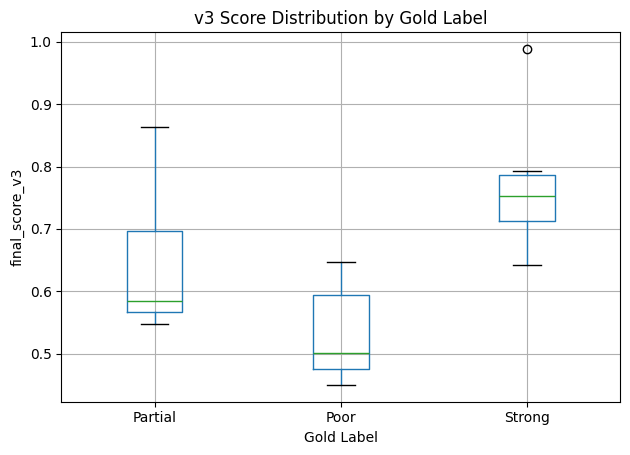

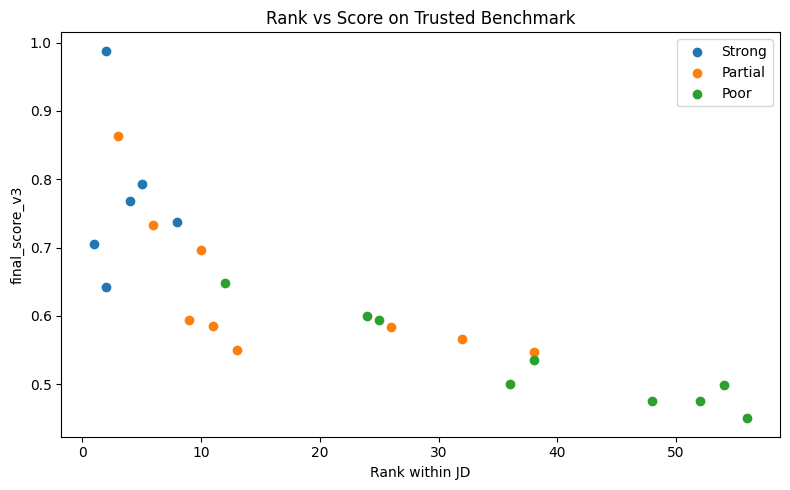

=== Score Separation Table ===


,gold_label,mean,median,min,max
2,2,0.772417,0.75325,0.6427,0.9882
1,1,0.635422,0.58480,0.5469,0.8630
0,0,0.530644,0.50050,0.4499,0.6474


Saved: /content/drive/MyDrive/resume_analyzer/outputs/evaluation/v3_score_separation.csv


In [ ]:
# ============================================================
# CELL E5 — Score separation plots
# Helps check whether strong / partial / poor are clearly separated
# ============================================================

import matplotlib.pyplot as plt

plot_df = bench_eval.copy()
plot_df["gold_text"] = plot_df["gold_label"].map({0: "Poor", 1: "Partial", 2: "Strong"})

# Boxplot
plt.figure(figsize=(8, 5))
plot_df.boxplot(column="final_score_v3", by="gold_text")
plt.title("v3 Score Distribution by Gold Label")
plt.suptitle("")
plt.xlabel("Gold Label")
plt.ylabel("final_score_v3")
plt.tight_layout()
plt.show()

# Rank plot
plt.figure(figsize=(8, 5))
for label_value, label_name in [(2, "Strong"), (1, "Partial"), (0, "Poor")]:
    subset = plot_df[plot_df["gold_label"] == label_value]
    plt.scatter(
        subset["rank_within_jd_v3"],
        subset["final_score_v3"],
        label=label_name
    )

plt.xlabel("Rank within JD")
plt.ylabel("final_score_v3")
plt.title("Rank vs Score on Trusted Benchmark")
plt.legend()
plt.tight_layout()
plt.show()

score_sep = (
    plot_df.groupby("gold_label")["final_score_v3"]
    .agg(["mean", "median", "min", "max"])
    .reset_index()
    .sort_values("gold_label", ascending=False)
)

print("=== Score Separation Table ===")
display(score_sep)

score_sep.to_csv(eval_dir / "v3_score_separation.csv", index=False)
print("Saved:", eval_dir / "v3_score_separation.csv")

In [ ]:
# ============================================================
# CELL E6 — Fit-status diagnostic for the final v3 engine
# IMPORTANT:
# v3 is a fixed hybrid engine, so classical overfit/underfit is not exact.
# This cell gives a benchmark-based diagnostic.
# ============================================================

# pull summary values
avg_rank_strong = float(ranking_summary.loc[ranking_summary["gold_label"] == 2, "avg_rank"].iloc[0])
avg_rank_partial = float(ranking_summary.loc[ranking_summary["gold_label"] == 1, "avg_rank"].iloc[0])
avg_rank_poor = float(ranking_summary.loc[ranking_summary["gold_label"] == 0, "avg_rank"].iloc[0])

avg_score_strong = float(ranking_summary.loc[ranking_summary["gold_label"] == 2, "avg_score"].iloc[0])
avg_score_partial = float(ranking_summary.loc[ranking_summary["gold_label"] == 1, "avg_score"].iloc[0])
avg_score_poor = float(ranking_summary.loc[ranking_summary["gold_label"] == 0, "avg_score"].iloc[0])

score_gap_strong_poor = avg_score_strong - avg_score_poor

# heuristic diagnostic
if (
    avg_rank_strong <= 5 and
    avg_rank_poor >= 20 and
    strong_gt10 == 0 and
    poor_top10 == 0 and
    score_gap_strong_poor >= 0.20
):
    fit_status = "Balanced / well-separated on trusted benchmark"
elif (
    avg_rank_strong > 10 or
    avg_rank_poor < 15 or
    score_gap_strong_poor < 0.10
):
    fit_status = "Underfitted / weak separation on benchmark"
else:
    fit_status = "Partially balanced, but needs more checking"

diagnostic_note = (
    "Classical overfitting is not directly applicable because v3 is not a trainable model. "
    "To test whether v3 is over-tuned to the current benchmark, evaluate it on a NEW manually labeled "
    "holdout set of unseen JDs."
)

fit_df = pd.DataFrame([{
    "avg_rank_strong": avg_rank_strong,
    "avg_rank_partial": avg_rank_partial,
    "avg_rank_poor": avg_rank_poor,
    "avg_score_strong": avg_score_strong,
    "avg_score_partial": avg_score_partial,
    "avg_score_poor": avg_score_poor,
    "score_gap_strong_poor": score_gap_strong_poor,
    "strong_ranked_gt10": strong_gt10,
    "poor_ranked_top10": poor_top10,
    "balanced_accuracy": bal_acc,
    "macro_f1": macro_f1,
    "fit_status": fit_status,
    "note": diagnostic_note
}])

print("=== v3 Fit-Status Diagnostic ===")
display(fit_df)

fit_df.to_csv(eval_dir / "v3_fit_status_diagnostic.csv", index=False)
print("Saved:", eval_dir / "v3_fit_status_diagnostic.csv")

=== v3 Fit-Status Diagnostic ===


,avg_rank_strong,avg_rank_partial,avg_rank_poor,avg_score_strong,avg_score_partial,avg_score_poor,score_gap_strong_poor,strong_ranked_gt10,poor_ranked_top10,balanced_accuracy,macro_f1,fit_status,note
0,3.666667,16.444444,38.333333,0.772417,0.635422,0.530644,0.241772,0,0,0.5,0.495455,Balanced / well-separated on trusted benchmark,Classical overfitting is not directly applicab...


Saved: /content/drive/MyDrive/resume_analyzer/outputs/evaluation/v3_fit_status_diagnostic.csv


Cell A: Accuracy Metric & Pie Distribution

In [ ]:
# ============================================================
# E7 — Overall Classification Metrics
# ============================================================

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_true = bench_eval["gold_label"]
y_pred = bench_eval["pred_label_v3"]

accuracy = accuracy_score(y_true, y_pred)

precision_macro = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

metrics_df = pd.DataFrame({
    "Metric":[
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1-score (Macro)"
    ],
    "Value":[
        accuracy,
        precision_macro,
        recall_macro,
        f1_macro
    ]
})

display(metrics_df)

metrics_df.to_csv(
    eval_dir/"v3_classification_metrics.csv",
    index=False
)

,Metric,Value
0,Accuracy,0.500000
1,Precision (Macro),0.524725
2,Recall (Macro),0.500000
3,F1-score (Macro),0.495455


E8 — Classification Metrics Bar Chart

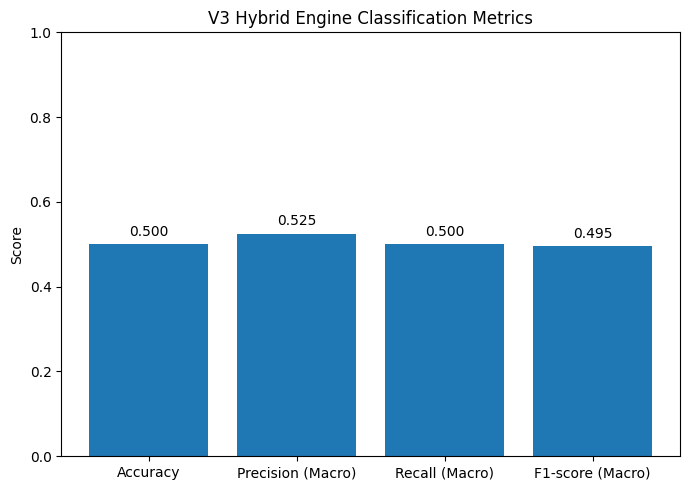

In [ ]:
# ============================================================
# E8 — Accuracy / Precision / Recall / F1 Bar Chart
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.bar(
    metrics_df["Metric"],
    metrics_df["Value"]
)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("V3 Hybrid Engine Classification Metrics")

for i,v in enumerate(metrics_df["Value"]):
    plt.text(i,v+0.02,f"{v:.3f}",ha="center")

plt.tight_layout()

plt.savefig(
    eval_dir/"classification_metrics_bar.png",
    dpi=300
)

plt.show()

E9 — Per-Class Precision / Recall / F1

In [ ]:
# ============================================================
# E9 — Per-Class Metrics
# ============================================================

from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=[
        "Poor",
        "Partial",
        "Strong"
    ],
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report).transpose()

display(report_df)

report_df.to_csv(
    eval_dir/"per_class_metrics.csv"
)

,precision,recall,f1-score,support
Poor,0.538462,0.777778,0.636364,9.0
Partial,0.285714,0.222222,0.250000,9.0
Strong,0.750000,0.500000,0.600000,6.0
accuracy,0.500000,0.500000,0.500000,0.5
macro avg,0.524725,0.500000,0.495455,24.0
weighted avg,0.496566,0.500000,0.482386,24.0


E10 — Per-Class Performance Graph

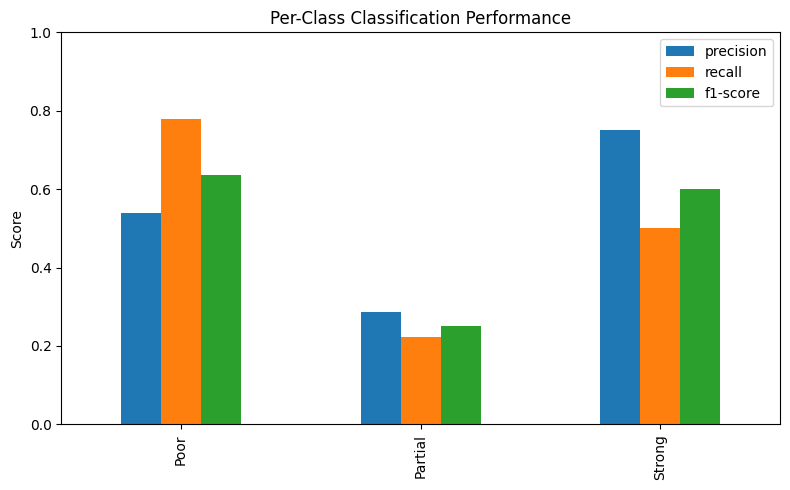

In [ ]:
# ============================================================
# E10 — Precision / Recall / F1 per Class
# ============================================================

plot_df = report_df.loc[
    ["Poor","Partial","Strong"],
    ["precision","recall","f1-score"]
]

plot_df.plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Per-Class Classification Performance")

plt.tight_layout()

plt.savefig(
    eval_dir/"per_class_metrics.png",
    dpi=300
)

plt.show()

=== AVERAGE RANK BY MATCH CATEGORY ===


,Match Category,Average Rank
0,Poor,6.555556
1,Partial,4.333333
2,Strong,1.666667


--------------------------------------------------

=== INFORMATION RETRIEVAL METRICS PER JD ===


,JD ID,Recall@3,Recall@5,MRR
0,J008,1.0,1.0,1.0
1,J009,1.0,1.0,1.0
2,J010,1.0,1.0,1.0



=== OVERALL SYSTEM RANKING PERFORMANCE ===
Average Recall@3: 1.0000
Average Recall@5: 1.0000
Mean Reciprocal Rank (MRR): 1.0000


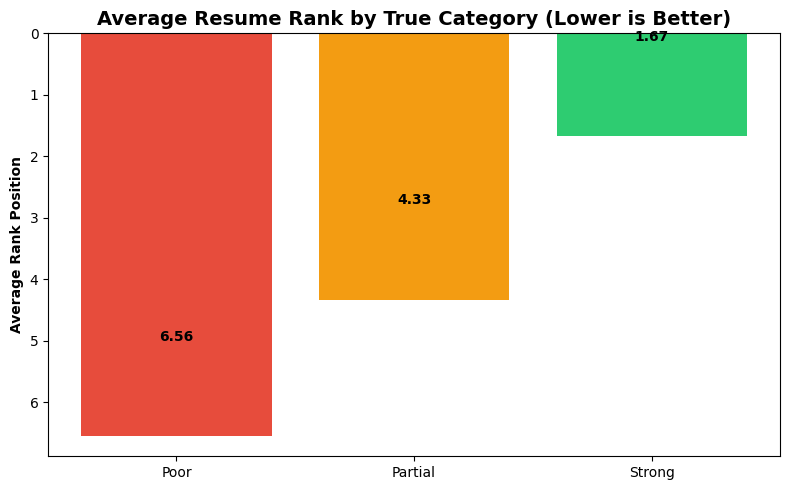

In [ ]:
# ============================================================
# E8 — Information Retrieval (IR) Ranking Metrics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Prepare the Data
# Ensure bench_eval is sorted by JD, then by the V3 Score in descending order
ir_df = bench_eval.copy()
ir_df = ir_df.sort_values(by=["jd_id", "final_score_v3"], ascending=[True, False])

# Create a 'Rank' column within each JD group
ir_df["rank"] = ir_df.groupby("jd_id").cumcount() + 1

# 2. Define the Target (What are we looking for?)
# In recruitment, we only care about finding the "Strong" matches (Gold Label == 2)
target_label = 2

# 3. Calculate Average Rank by Label (Your strongest metric)
avg_rank_by_label = ir_df.groupby("gold_label")["rank"].mean().reset_index()
avg_rank_by_label.columns = ["Match Category", "Average Rank"]
avg_rank_by_label["Match Category"] = avg_rank_by_label["Match Category"].map({0: "Poor", 1: "Partial", 2: "Strong"})

print("=== AVERAGE RANK BY MATCH CATEGORY ===")
display(avg_rank_by_label)
print("-" * 50)

# 4. Calculate Recall@K and MRR per Job Description
k_values = [3, 5]
results = []

for jd in ir_df["jd_id"].unique():
    jd_group = ir_df[ir_df["jd_id"] == jd]

    # Identify the actual "Strong" matches for this JD
    strong_matches = jd_group[jd_group["gold_label"] == target_label]
    num_strong_matches = len(strong_matches)

    if num_strong_matches == 0:
        continue # Skip if there are no strong matches to find

    metrics = {"JD ID": jd}

    # Recall@K
    for k in k_values:
        top_k = jd_group.head(k)
        found_in_top_k = len(top_k[top_k["gold_label"] == target_label])
        recall_at_k = found_in_top_k / num_strong_matches
        metrics[f"Recall@{k}"] = recall_at_k

    # Mean Reciprocal Rank (MRR)
    # Find the rank of the *first* strong match
    if not strong_matches.empty:
        first_strong_rank = strong_matches.iloc[0]["rank"]
        metrics["MRR"] = 1.0 / first_strong_rank
    else:
         metrics["MRR"] = 0.0

    results.append(metrics)

# 5. Summarize System-Wide IR Metrics
ir_metrics_df = pd.DataFrame(results)

print("\n=== INFORMATION RETRIEVAL METRICS PER JD ===")
display(ir_metrics_df)

print("\n=== OVERALL SYSTEM RANKING PERFORMANCE ===")
overall_recall_3 = ir_metrics_df["Recall@3"].mean()
overall_recall_5 = ir_metrics_df["Recall@5"].mean()
overall_mrr = ir_metrics_df["MRR"].mean()

print(f"Average Recall@3: {overall_recall_3:.4f}")
print(f"Average Recall@5: {overall_recall_5:.4f}")
print(f"Mean Reciprocal Rank (MRR): {overall_mrr:.4f}")

# 6. Visualization: Average Rank Comparison
plt.figure(figsize=(8, 5))
bars = plt.bar(avg_rank_by_label["Match Category"], avg_rank_by_label["Average Rank"], color=['#e74c3c', '#f39c12', '#2ecc71'])
plt.title("Average Resume Rank by True Category (Lower is Better)", fontsize=14, weight='bold')
plt.ylabel("Average Rank Position", weight='bold')
plt.gca().invert_yaxis() # Invert Y axis because a lower rank (1) is better than a high rank (40)

# Add value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval - 1.5, f"{yval:.2f}", ha='center', va='bottom', weight='bold', color='black')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2747/3683814537.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


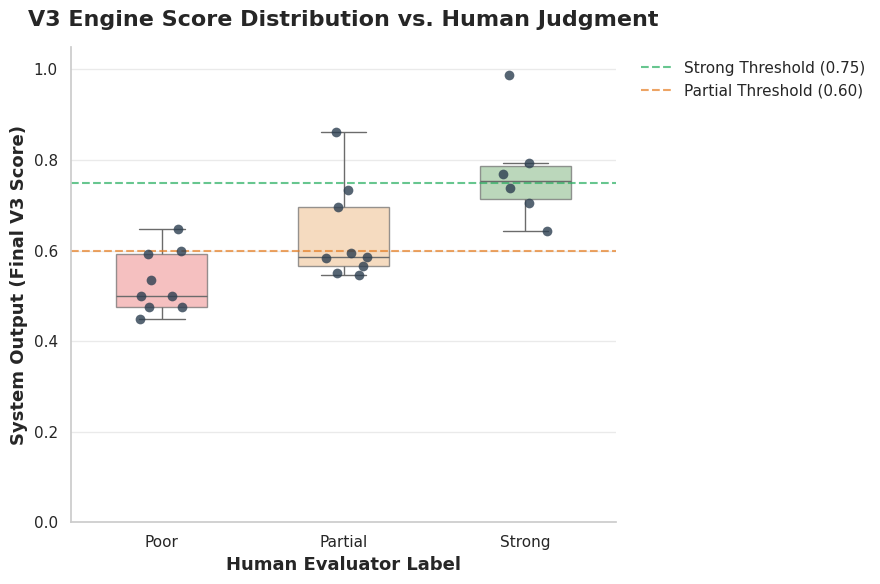

In [ ]:
# ============================================================
# CELL E2 — Score Distribution by Target Class (Polished)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))
# Clean theme with no top/right borders
sns.set_theme(style="whitegrid", rc={"axes.spines.right": False, "axes.spines.top": False, "grid.alpha": 0.4})

ax = sns.boxplot(
    data=bench_eval, x="gold_text", y="final_score_v3",
    order=["Poor", "Partial", "Strong"],
    palette=["#ff9999", "#ffcc99", "#99cc99"],
    showfliers=False, width=0.5, boxprops=dict(alpha=0.7)
)

sns.stripplot(
    data=bench_eval, x="gold_text", y="final_score_v3",
    order=["Poor", "Partial", "Strong"],
    color="#2c3e50", alpha=0.8, jitter=0.15, size=7
)

plt.title("V3 Engine Score Distribution vs. Human Judgment", fontsize=16, weight='bold', pad=15)
plt.xlabel("Human Evaluator Label", fontsize=13, weight='bold')
plt.ylabel("System Output (Final V3 Score)", fontsize=13, weight='bold')
plt.ylim(0, 1.05)

plt.axhline(y=0.75, color='#27ae60', linestyle='--', alpha=0.7, label="Strong Threshold (0.75)")
plt.axhline(y=0.60, color='#e67e22', linestyle='--', alpha=0.7, label="Partial Threshold (0.60)")

# Move legend outside the plot
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig(eval_dir / "v3_score_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_2747/3165673583.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.swarmplot(


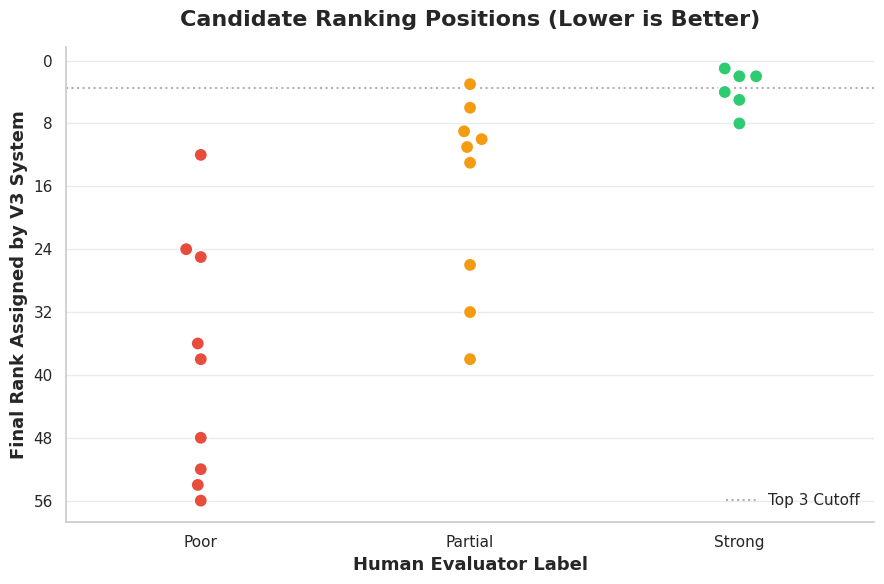

In [ ]:
# ============================================================
# CELL E3 — Final Ranking Positions (Polished)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plt.figure(figsize=(9, 6))
sns.set_theme(style="whitegrid", rc={"axes.spines.right": False, "axes.spines.top": False, "grid.alpha": 0.4})

ax = sns.swarmplot(
    data=bench_eval, x="gold_text", y="rank_within_jd_v3",
    order=["Poor", "Partial", "Strong"],
    palette=["#e74c3c", "#f39c12", "#2ecc71"],
    size=10, edgecolor="white", linewidth=1.5
)

plt.title("Candidate Ranking Positions (Lower is Better)", fontsize=16, weight='bold', pad=15)
plt.xlabel("Human Evaluator Label", fontsize=13, weight='bold')
plt.ylabel("Final Rank Assigned by V3 System", fontsize=13, weight='bold')

# Invert Y-axis and force integers
plt.gca().invert_yaxis()
plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

# Add a subtle line to show the "Top 3" cutoff
plt.axhline(y=3.5, color='gray', linestyle=':', alpha=0.6, label="Top 3 Cutoff")
plt.legend(loc="lower right", frameon=False)

plt.tight_layout()
plt.savefig(eval_dir / "v3_rank_positions.png", dpi=300, bbox_inches='tight')
plt.show()

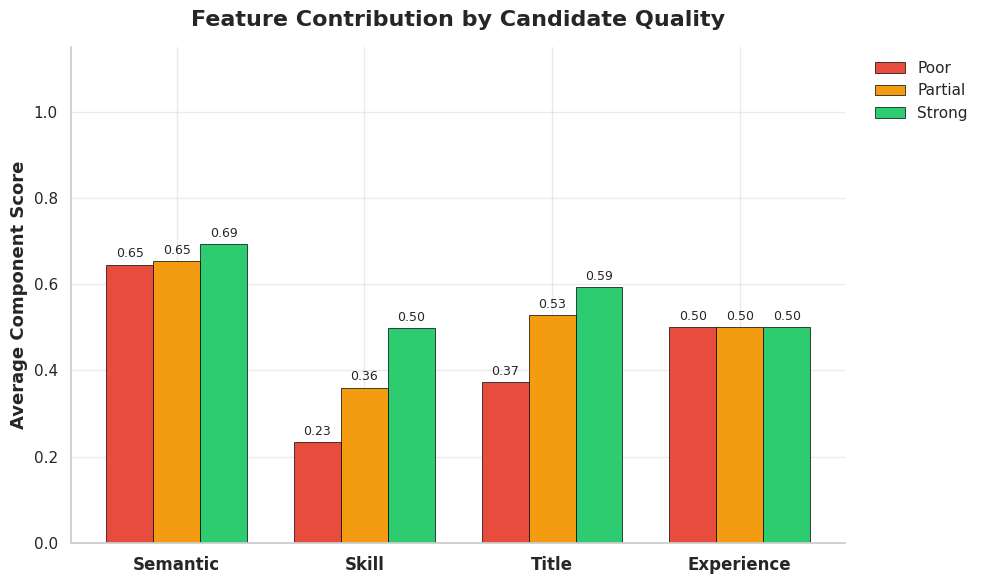

In [ ]:
# ============================================================
# CELL E4 — Sub-Score Breakdown (Polished)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", rc={"axes.spines.right": False, "axes.spines.top": False, "grid.alpha": 0.4})

sub_scores = bench_eval.groupby("gold_text")[["semantic_score", "skill_score", "title_score", "experience_score"]].mean().reset_index()
sub_scores["gold_text"] = pd.Categorical(sub_scores["gold_text"], categories=["Poor", "Partial", "Strong"], ordered=True)
sub_scores = sub_scores.sort_values("gold_text")

labels = ["Semantic", "Skill", "Title", "Experience"]
poor_means = sub_scores[sub_scores["gold_text"] == "Poor"][["semantic_score", "skill_score", "title_score", "experience_score"]].values[0]
partial_means = sub_scores[sub_scores["gold_text"] == "Partial"][["semantic_score", "skill_score", "title_score", "experience_score"]].values[0]
strong_means = sub_scores[sub_scores["gold_text"] == "Strong"][["semantic_score", "skill_score", "title_score", "experience_score"]].values[0]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, poor_means, width, label='Poor', color='#e74c3c', edgecolor="black", linewidth=0.5)
rects2 = ax.bar(x, partial_means, width, label='Partial', color='#f39c12', edgecolor="black", linewidth=0.5)
rects3 = ax.bar(x + width, strong_means, width, label='Strong', color='#2ecc71', edgecolor="black", linewidth=0.5)

ax.set_ylabel('Average Component Score', fontsize=13, weight='bold')
ax.set_title('Feature Contribution by Candidate Quality', fontsize=16, weight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12, weight='bold')
ax.set_ylim(0, 1.15)

# Function to add values on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, rotation=0)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Move legend outside
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig(eval_dir / "v3_hybrid_breakdown.png", dpi=300, bbox_inches='tight')
plt.show()